## Bivariate and Multivariate Analysis

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pingouin as pg
import itertools
import patsy
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
import os
import matplotlib.dates as mdates
from scipy import stats
import scikit_posthocs as sp
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_coint_rank
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.feature_selection import RFE

pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", 1000) 
pd.set_option('display.float_format', '{:.3f}'.format)

## Preparation for Analysis

In [24]:
os.chdir('/Users/joudisinjab/Documents/GitHub/capstone_project')

LFS = pd.read_csv("Data/LFS/LFS_Cleaned.csv", parse_dates=["REF_DATE"])
overall_indicators = pd.read_csv('Monthly Labour Market Rates.csv', parse_dates=["REF_DATE"])
industry_trends = pd.read_csv('Monthly Industry Labour Market Rates.csv', parse_dates=["REF_DATE"])

In [25]:
LFS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5507987 entries, 0 to 5507986
Data columns (total 41 columns):
 #   Column             Dtype         
---  ------             -----         
 0   REC_NUM            int64         
 1   lf_status          int64         
 2   province           int64         
 3   age_5y_group       int64         
 4   gender             int64         
 5   marital_stat       int64         
 6   education          int64         
 7   multiple_jobh      float64       
 8   work_lasty         float64       
 9   ft_pt_last         float64       
 10  main_class_worker  float64       
 11  immigration_stat   int64         
 12  NAICS_21           float64       
 13  NOC_10             float64       
 14  NOC_43             float64       
 15  weeks_absent       float64       
 16  paid_for_absence   float64       
 17  usualhrs_main      float64       
 18  actualhrs_main     float64       
 19  ft_pt_main         float64       
 20  usualhrs_all       float

In [26]:
overall_indicators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   REF_DATE                            48 non-null     datetime64[ns]
 1   Employment_Rate(%)                  48 non-null     float64       
 2   Unemployment_Rate(%)                48 non-null     float64       
 3   Labour_Force_Participation_Rate(%)  48 non-null     float64       
 4   Average_Hourly_Wage                 48 non-null     float64       
 5   Duration_Jobless(Months)            48 non-null     float64       
 6   Job Vacancies (#)                   48 non-null     float64       
 7   Payroll Employees (#)               48 non-null     float64       
 8   Job Vacancy Rate (%)                48 non-null     float64       
 9   Month                               48 non-null     object        
 10  Year                        

In [27]:
# Convert 'Month' column to datetime
LFS['Month'] = pd.to_datetime(LFS['Month'], errors='coerce')
overall_indicators['Month'] = pd.to_datetime(overall_indicators['Month'], errors='coerce')
industry_trends['Month'] = pd.to_datetime(industry_trends['Month'], errors='coerce')

# Sort the data by Month so it's in chronological order
LFS.sort_values(by='Month', inplace=True)
overall_indicators.sort_values(by='Month', inplace=True)
industry_trends.sort_values(by='Month', inplace=True)

# Convert NAICS_21 to a categorical type
industry_trends['NAICS_21'] = pd.Categorical(industry_trends['NAICS_21'])

# Converting LFS variable to categorical type
ordinal_vars = [
    'lf_status', 'age_5y_group', 'education', 'marital_stat', 'work_lasty',
    'job_permenancy', 'estab_size', 'firm_size', 'student_status', 
]

nominal_vars = [
    'province', 'gender', 'multiple_jobh', 'ft_pt_last', 'main_class_worker', 'immigration_stat', 
    'NAICS_21', 'NOC_10', 'NOC_43', 'ft_pt_main', 'union_stat', 'flow_to_unemp' , 'econ_fam_type', 'paid_for_absence'
]
# Convert ordinal variables
for var in ordinal_vars:
    LFS[var] = LFS[var].astype(pd.Int64Dtype())  # Nullable integer type
    LFS[var] = pd.Categorical(LFS[var], ordered=True)

# Convert nominal variables
for var in nominal_vars:
    LFS[var] = LFS[var].astype(pd.Int64Dtype())  # Nullable integer type
    LFS[var] = LFS[var].astype('category')

/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/1733096786.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  LFS['Month'] = pd.to_datetime(LFS['Month'], errors='coerce')
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/1733096786.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  overall_indicators['Month'] = pd.to_datetime(overall_indicators['Month'], errors='coerce')
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/1733096786.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  industry_trends['Month'] = pd.to_datetime(in

In [28]:
LFS.duplicated().sum()

0

In [29]:
# Employed and At Work View
LFS_atwork = LFS.loc[LFS['lf_status'] == 1]

# Employed but Absent View
LFS_absent = LFS.loc[LFS['lf_status'] == 2]

# All Employed
LFS_employed = LFS.loc[(LFS['lf_status'] == 1) | (LFS['lf_status'] == 2)]

# Unemployed View
LFS_unemployed = LFS.loc[LFS['lf_status'] == 3]

# Not in Force View 
LFS_notinforce = LFS.loc[LFS['lf_status'] == 4]

#### Descriptive stats

In [30]:
descriptive_stats = LFS.describe().T[['mean', 'std', 'min', '50%', 'max']]

# descriptive_stats.to_csv('LFS_Numerical_Stats.csv', index=True)

In [31]:
categorical_cols = LFS.select_dtypes(include=['category', 'object']).columns

summary = []

for col in categorical_cols:
    freq_counts = LFS[col].value_counts()  # Frequency counts
    percentages = (freq_counts / LFS[col].count() * 100).round(2)  # Percentage calculation

    for category, count in freq_counts.items():
        summary.append({
            'Variable': col,
            'Category': category,
            'Frequency (Count)': count,
            'Percentage (%)': percentages[category]
        })

# Convert to DataFrame
categorical_summary = pd.DataFrame(summary)

# Display summary
print(categorical_summary)

# Save to CSV
# categorical_summary.to_csv("LFS_Categorical_Descriptive_Stats.csv", index=True)


          Variable  Category  Frequency (Count)  Percentage (%)
0        lf_status         1            2919551          53.010
1        lf_status         4            2081526          37.790
2        lf_status         2             298279           5.420
3        lf_status         3             208631           3.790
4         province        35            1717719          31.190
..             ...       ...                ...             ...
175  econ_fam_type        16              45748           0.830
176  econ_fam_type        10              37497           0.680
177  econ_fam_type        12              35902           0.650
178  econ_fam_type        17              19439           0.350
179  econ_fam_type        13              19181           0.350

[180 rows x 4 columns]


## What are the overall trends in Canada’s labour market key indicators in 2024? What is the labour force participation rate and unemployment rate from in 2024? Are there notable trends, and is there a relationship between labour force participation rate, unemployment, and inflation? Does inflation impact market tightness across different industries?

### Monthly Trends in Key Labour Market Indicators (2021–2024)

To understand the overall dynamics in Canada's labour market, we begin by plotting the monthly trends for key indicators such as employment rate, participation rate, unemployment rate, job vacancy rate, market tightness, inflation rates, and average hourly wage. This allows to visualize any seasonal patterns, sharp changes, or underlying trends over time.

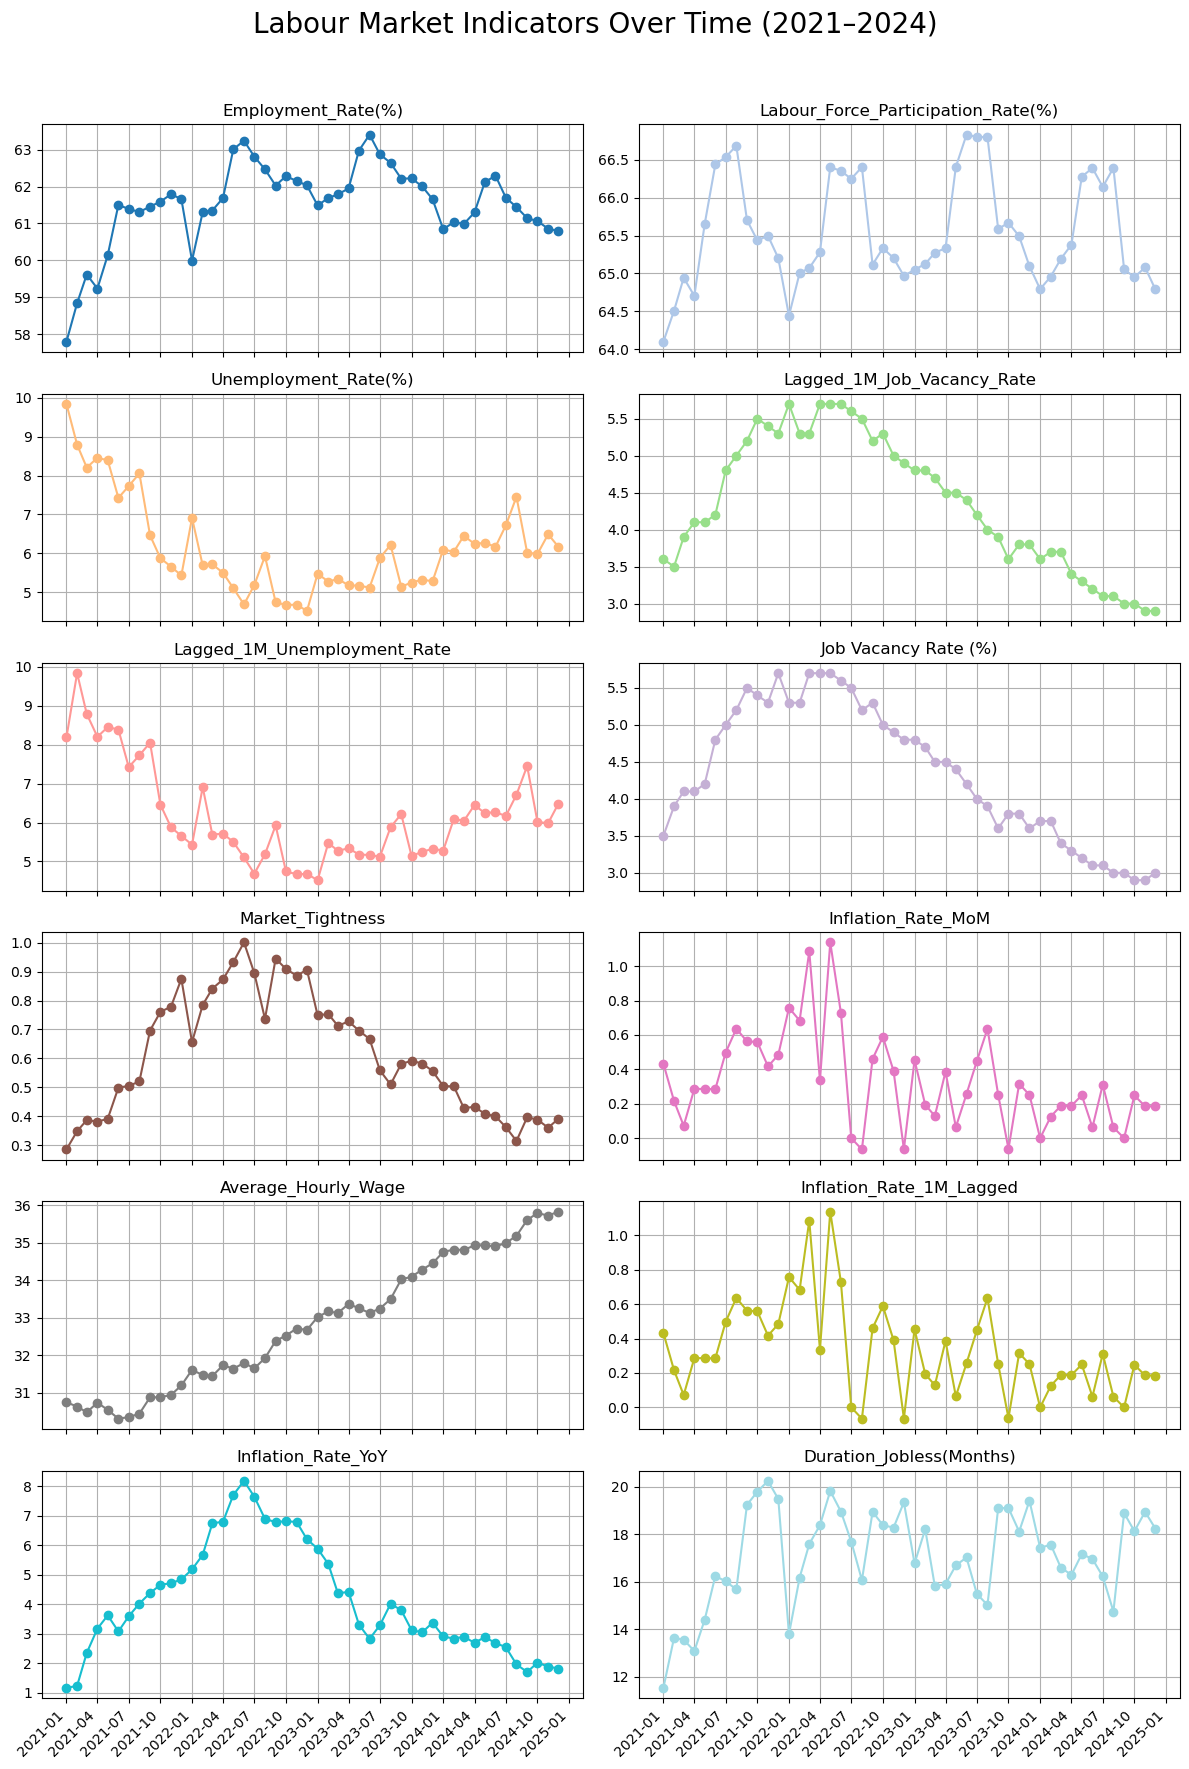

In [32]:
# List of indicators to plot
indicators = ["Employment_Rate(%)", "Labour_Force_Participation_Rate(%)", "Unemployment_Rate(%)", "Lagged_1M_Job_Vacancy_Rate", "Lagged_1M_Unemployment_Rate",  
              "Job Vacancy Rate (%)", "Market_Tightness", "Inflation_Rate_MoM", "Average_Hourly_Wage", 'Inflation_Rate_1M_Lagged', "Inflation_Rate_YoY", "Duration_Jobless(Months)"]
num_plots = len(indicators)

ncols = 2
nrows = int(np.ceil(len(indicators) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows), sharex=True)
axes = axes.flatten()

# Colour cycle — one distinct colour per plot
colors = plt.cm.tab20(np.linspace(0, 1, len(indicators)))

# Quarterly ticks
locator = mdates.MonthLocator(interval=3)
formatter = mdates.DateFormatter("%Y-%m")

for ax, col, color in zip(axes, indicators, colors):
    ax.plot(overall_indicators["REF_DATE"], overall_indicators[col], marker="o", linestyle="-", color=color)
    ax.set_title(col)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.grid(True)

# Hide x‑labels on all but bottom row
for ax in axes[:-ncols]:
    ax.tick_params(labelbottom=False)

# Rotate bottom-row tick labels only
for ax in axes[-ncols:]:
    plt.setp(ax.xaxis.get_ticklabels(), rotation=45, ha="right")

fig.suptitle("Labour Market Indicators Over Time (2021–2024)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Key Trends in Canada's Labour Market Indicators (2021–2024)

This panel of time series plots shows the monthly progression of key labour market indicators in Canada. Here are the most notable insights:

##### Employment & Participation
- **Employment Rate (%)** increased steadily into mid-2023, peaking near 63.5%, then declined slightly into 2024.
- **Labour Force Participation Rate (%)** remained relatively stable but showed seasonal fluctuations, typically peaking in spring-summer.

##### Unemployment Trends
- **Unemployment Rate (%)** dropped sharply from 2021 to early 2023, reaching ~5%, but began rising again in 2024—mirrored in the lagged version.
  
##### Job Vacancy & Market Tightness
- **Job Vacancy Rate (%)** and **Market Tightness** peaked in 2022 and steadily declined into 2024, indicating easing labour demand and fewer hiring challenges.
- The lagged job vacancy rate closely tracks the actual rate, showing a delayed but consistent decline.

##### Wages
- **Average Hourly Wage** steadily increased from ~$31 to over $35/hour, likely due to past tight labour markets and inflationary pressures.

##### Inflation
- **MoM Inflation Rate** was volatile, peaking above 1% in 2022 but stabilizing below 0.4% in 2024.
- **YoY Inflation** surged to ~8% in 2022 but declined steadily to ~2% by 2024.
- The lagged inflation rate shows a similar trend, emphasizing short-term inflation impacts.

##### Joblessness Duration
- **Average Duration of Joblessness** remained high (~16–20 months), despite lower unemployment rates in earlier years—suggesting persistent long-term unemployment.

---

#### Combined Insights
- Labour demand (vacancies, tightness) is cooling, but wage growth continues—potentially due to inertia in labour costs.
- Rising unemployment alongside declining vacancies in 2024 may signal a labour market shift or economic slowdown.
- Inflation appears to lag behind changes in tightness and unemployment, highlighting potential causality explored further through lag analysis.
- Persistent joblessness duration points to structural challenges in re-integrating unemployed workers into the labour market.


### Correlation Matrix of Labour Market Indicators

The heatmap below displays Pearson correlation coefficients between labour market indicators. This helps reveal linear relationships—such as whether rising inflation correlates with lower unemployment or higher job vacancy rates.

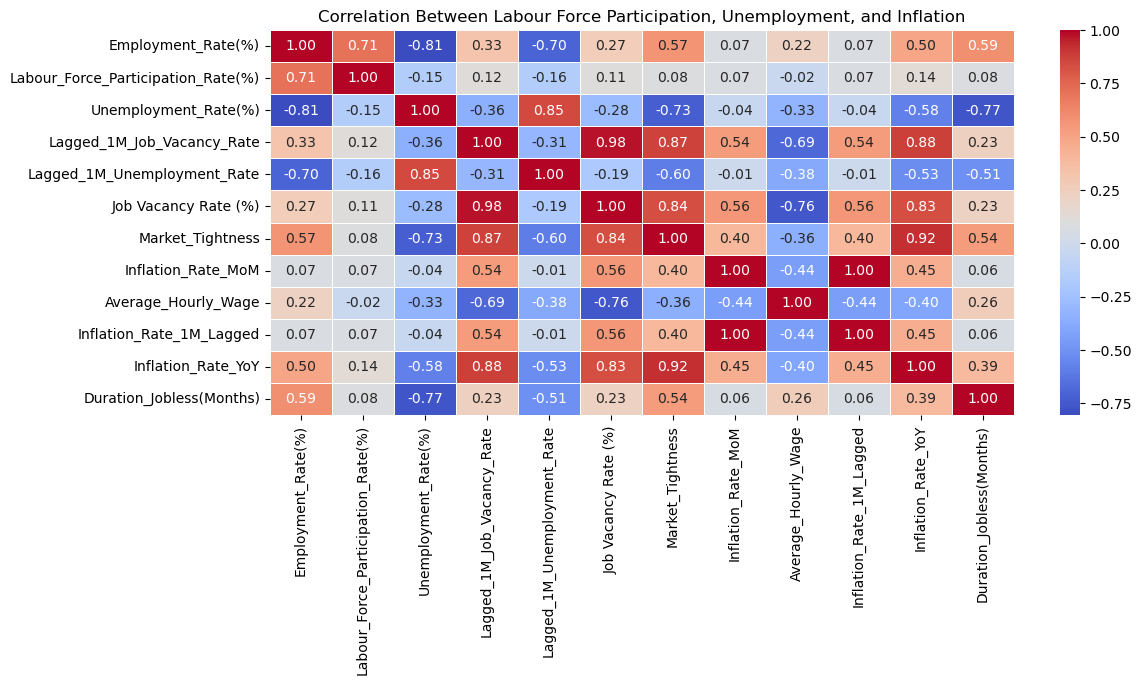

In [33]:
# Compute correlation
plt.figure(figsize=(12, 5))
sns.heatmap(overall_indicators[indicators].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Labour Force Participation, Unemployment, and Inflation")
plt.show()



### Correlation Between Labour Market Indicators

The heatmap below visualizes Pearson correlation coefficients between key labour market indicators, including employment, unemployment, job vacancy, inflation, wages, and joblessness duration.

#### Key Positive Correlations
- **Job Vacancy Rate** and **Market Tightness**: **r = 0.84**  
  Indicates a strong relationship between how many jobs are available and how tight the market is (fewer job seekers per opening).
  
- **Inflation Rate (YoY)** and:
  - **Lagged Job Vacancy Rate**: **r = 0.88**
  - **Market Tightness**: **r = 0.92**  
  Suggests inflation tends to rise during tighter labour market conditions.

- **Employment Rate** and:
  - **Labour Force Participation**: **r = 0.71**
  - **Market Tightness**: **r = 0.57**

#### Key Negative Correlations
- **Unemployment Rate** and:
  - **Employment Rate**: **r = -0.81**
  - **Market Tightness**: **r = -0.73**
  - **Duration of Joblessness**: **r = -0.77**
  
- **Lagged Unemployment Rate** and:
  - **Average Hourly Wage**: **r = -0.38**
  - **Market Tightness**: **r = -0.60**

- **Job Vacancy Rate** and:
  - **Lagged Unemployment Rate**: **r = -0.31**
  - **Duration of Joblessness**: **r = -0.76**

#### Interpretation
- Tight labour markets (high job vacancy & market tightness) are associated with **higher inflation** and **lower unemployment**.
- **Lagged variables show meaningful correlations**, suggesting a delayed impact of market conditions on wages and inflation.
- **Duration of joblessness** is strongly associated with higher unemployment and lower employment—highlighting persistent structural unemployment challenges.


### Partial Correlation Analysis of Labour Market Indicators

To better understand the direct relationships between labour market indicators—while accounting for the influence of other variables—we calculated partial correlations between all pairs of indicators.

Unlike simple correlation, partial correlation controls for all other variables in the dataset, isolating the unique association between each pair. This method helps uncover relationships that may otherwise be masked by confounding factors.

Below are the statistically significant results (p < 0.05):


In [34]:
# Dataframe with these indicators
df = overall_indicators[indicators]

# Initialize an empty list to store the results
results = []

# Get all combinations of indicator pairs
combinations = list(itertools.combinations(indicators, 2))

# Loop through each combination
for var1, var2 in combinations:
    # Control for all other variables except var1 and var2
    controls = [var for var in indicators if var != var1 and var != var2]
    
    # Calculate partial correlation
    result = pg.partial_corr(data=df, x=var1, y=var2, covar=controls)
    
    # Store the results
    results.append({
        'Var1': var1,
        'Var2': var2,
        'Partial Correlation': result.iloc[0]['r'],  # Use iloc to access by position
        'p-val': result.iloc[0]['p-val'],  # Use iloc to access by position
        'CI95%': result.iloc[0]['CI95%']  # Use iloc to access by position
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Filter the DataFrame to only include rows with p-value < 0.05
significant_results = results_df[results_df['p-val'] < 0.05]

# Print the filtered results
print(significant_results)


                                  Var1                                Var2  Partial Correlation  p-val           CI95%
0                   Employment_Rate(%)  Labour_Force_Participation_Rate(%)                1.000  0.000      [1.0, 1.0]
1                   Employment_Rate(%)                Unemployment_Rate(%)               -0.999  0.000    [-1.0, -1.0]
4                   Employment_Rate(%)                Job Vacancy Rate (%)               -0.535  0.001  [-0.73, -0.26]
5                   Employment_Rate(%)                    Market_Tightness                0.467  0.003    [0.17, 0.68]
11  Labour_Force_Participation_Rate(%)                Unemployment_Rate(%)                0.998  0.000      [1.0, 1.0]
14  Labour_Force_Participation_Rate(%)                Job Vacancy Rate (%)                0.537  0.001    [0.26, 0.73]
15  Labour_Force_Participation_Rate(%)                    Market_Tightness               -0.473  0.003  [-0.69, -0.18]
23                Unemployment_Rate(%)          

/opt/anaconda3/lib/python3.12/site-packages/pingouin/correlation.py:59: RuntimeWarning: invalid value encountered in sqrt
  tval = r * np.sqrt(dof / (1 - r**2))
/opt/anaconda3/lib/python3.12/site-packages/pingouin/effsize.py:152: RuntimeWarning: invalid value encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform


### Key Insights from Significant Partial Correlations

- **Labour Force Participation, Employment, and Unemployment**  
  Strong, expected relationships exist:
  - Employment rate is **strongly positively** correlated with participation rate (r = 1.00)  
  - Employment rate is **strongly negatively** correlated with unemployment rate (r = -0.999)  
  - Participation rate is **positively** correlated with unemployment (r = 0.998), which may seem counterintuitive but reflects that more people entering the labour force can increase unemployment in the short term.

- **Market Tightness & Job Vacancies**  
  - Market tightness is **positively associated** with job vacancy rate (r = 0.55)  
  - Market tightness is **positively correlated** with unemployment rate (r = 0.43), possibly reflecting sectoral mismatches or hiring difficulties even with available labour.

- **Inflation Relationships**  
  - **Lagged inflation (YoY)** has a moderate **positive correlation** with market tightness (r = 0.60)  
  - **Lagged inflation** also shows some positive association with lagged job vacancy rate (r = 0.32)  
  - This may suggest that inflationary pressures impact market demand before affecting actual wage or employment levels.

- **Wages**  
  - Lagged unemployment is **negatively correlated** with average hourly wage (r = -0.44), indicating that lower unemployment (a tighter market) can be associated with wage growth.

- **Redundancy Checks**  
  - Inflation_MoM and its lagged version are perfectly (negatively) correlated (r = -1.00), which might be due to how they were calculated or overlap in values.


### Exploring Relationships Between Inflation and Labour Market Indicators

We now explore how monthly inflation aligns with unemployment, market tightness, and wages. Dual-axis plots help visualize co-movement or divergence over time.

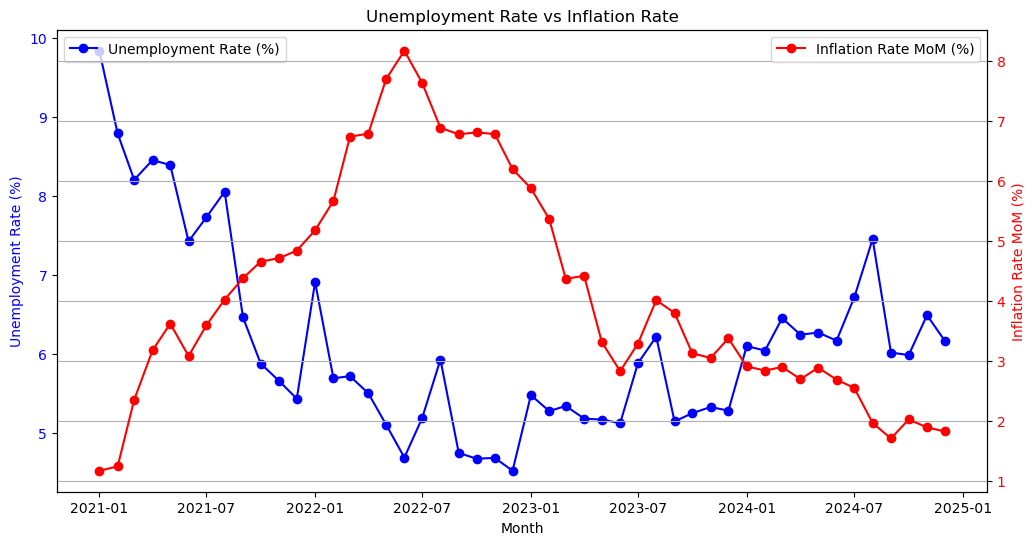

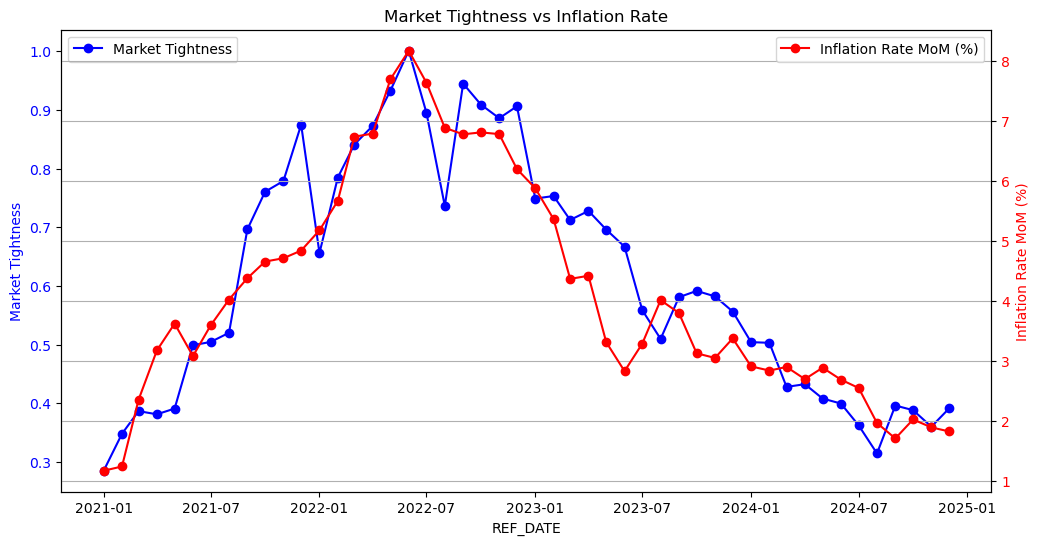

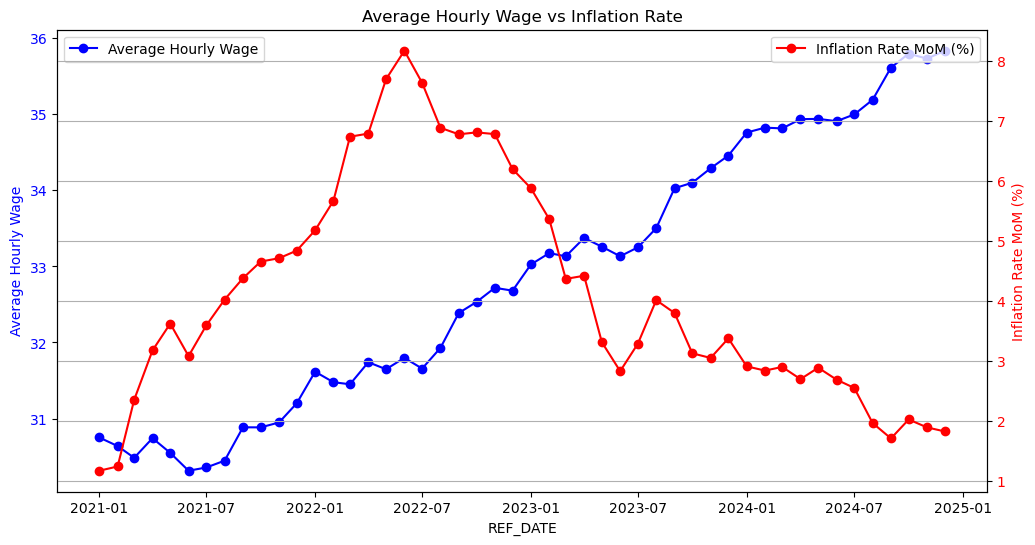

In [35]:
# Plot 1: Unemployment Rate vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Unemployment Rate
ax1.set_xlabel('Month')
ax1.set_ylabel('Unemployment Rate (%)', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Unemployment_Rate(%)'], label='Unemployment Rate (%)', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate MoM (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_YoY'], label="Inflation Rate MoM (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Unemployment Rate vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 2: Market Tightness vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Market Tightness
ax1.set_xlabel('REF_DATE')
ax1.set_ylabel('Market Tightness', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Market_Tightness'], label='Market Tightness', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate MoM (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_YoY'], label="Inflation Rate MoM (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Market Tightness vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 3: Average Hourly Wage vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Average Hourly Wage
ax1.set_xlabel('REF_DATE')
ax1.set_ylabel('Average Hourly Wage', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Average_Hourly_Wage'], label='Average Hourly Wage', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate MoM (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_YoY'], label="Inflation Rate MoM (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Average Hourly Wage vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()


### Inflation and Labour Market Indicators: Trend Comparisons

To explore the interaction between inflation and labour market conditions, we compare **MoM inflation rates** with:

1. **Unemployment Rate**
2. **Market Tightness**
3. **Average Hourly Wage**

#### 1. Unemployment Rate vs Inflation
- **Inverse relationship** visible from 2021 to mid-2022: as inflation rose, unemployment fell.
- After inflation peaked (mid-2022), **both unemployment and inflation decreased**, showing less of a direct correlation in recent years.
- This pattern partially aligns with the **Phillips Curve**, but the relationship weakens post-2022, suggesting additional factors at play.

#### 2. Market Tightness vs Inflation
- Both indicators **increase sharply from 2021 through 2022**, peaking around mid-2022.
- From 2023 onwards, both **decline together**, indicating a strong positive co-movement.
- Suggests that **tight labour markets may have contributed to inflation**, and easing tightness helped cool it.

#### 3. Average Hourly Wage vs Inflation
- Inflation spikes ahead of wage growth, with **wages responding more gradually** over time.
- Even as inflation drops after 2022, **wages continue rising**, reflecting **wage stickiness** or employers adjusting compensation based on past inflation.
- Highlights a possible **lagged effect** of inflation on wages.

---

### Combined Insights
- Inflation appears closely tied to **labour demand conditions** (tightness, vacancies), especially through 2022.
- The lag between inflation peaks and wage increases suggests **inflation may drive wage adjustments**, but wages stay elevated even after inflation cools.
- Unemployment shows a **weakening inverse relationship** with inflation in recent periods, underscoring the complexity of post-COVID labour dynamics.


### Examining Lagged Inflation Effects (One-Month Lag)

Since economic effects often appear with a delay, we also examine whether inflation in the previous month impacts unemployment, wages, or market tightness. These lagged plots may highlight delayed reactions in the labour market.

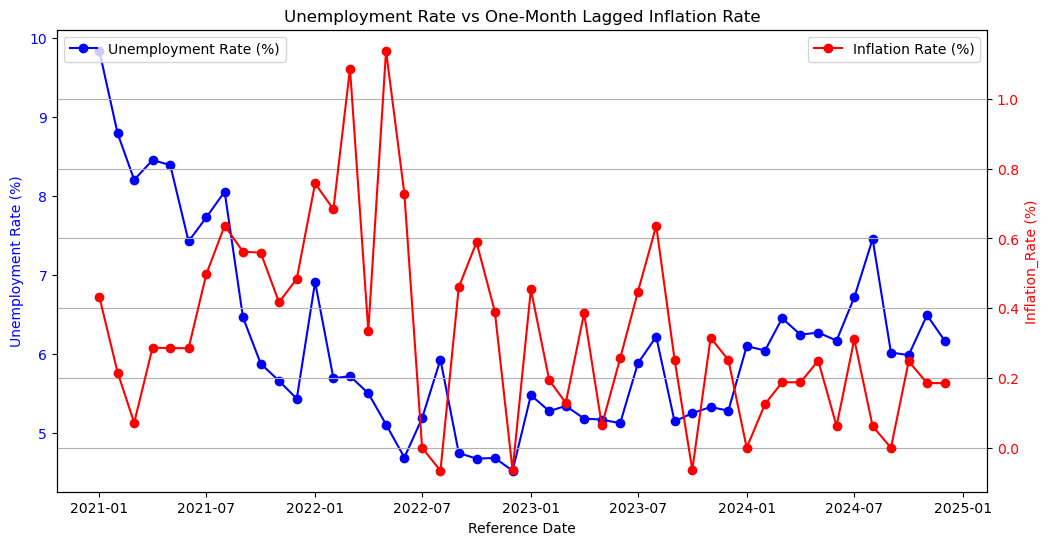

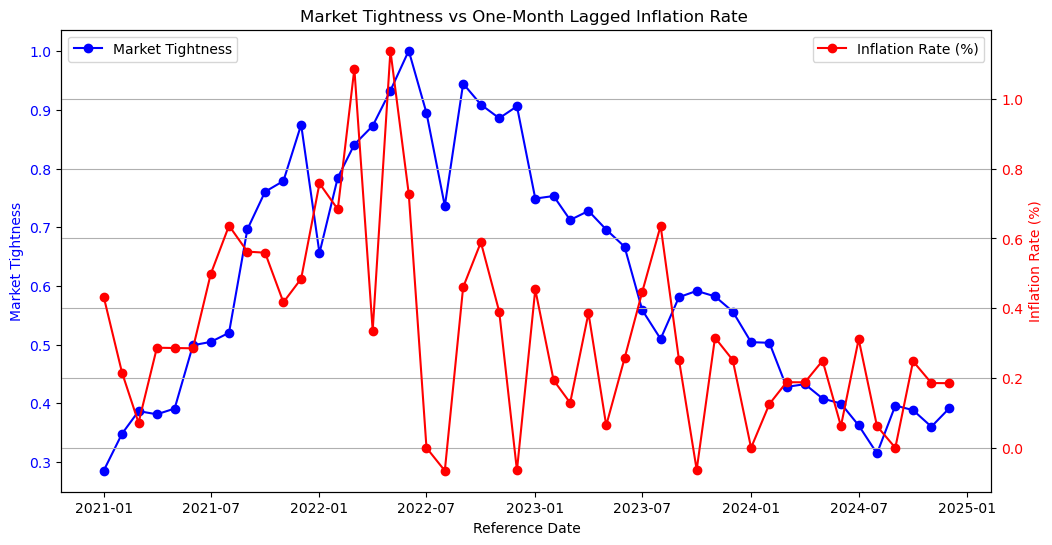

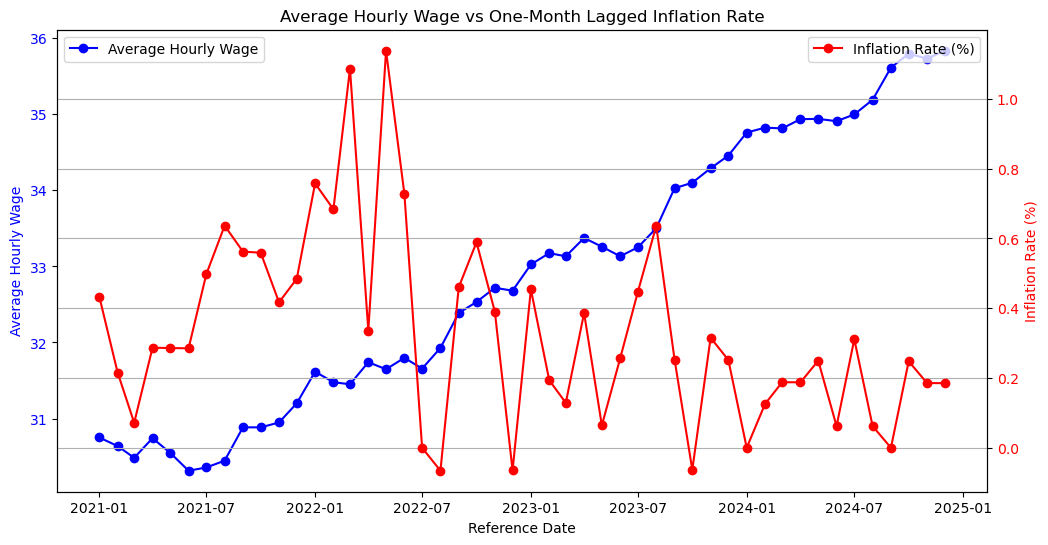

In [36]:
# Drop rows where 'Inflation_Rate_Lag1' is NaN

# Plot 1: Unemployment Rate vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Unemployment Rate
ax1.set_xlabel('Reference Date')
ax1.set_ylabel('Unemployment Rate (%)', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Unemployment_Rate(%)'], label='Unemployment Rate (%)', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation_Rate (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_1M_Lagged'], label="Inflation Rate (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Unemployment Rate vs One-Month Lagged Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 2: Market Tightness vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Market Tightness
ax1.set_xlabel('Reference Date')
ax1.set_ylabel('Market Tightness', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Market_Tightness'], label='Market Tightness', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_1M_Lagged'], label="Inflation Rate (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Market Tightness vs One-Month Lagged Inflation Rate ")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 3: Average Hourly Wage vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Average Hourly Wage
ax1.set_xlabel('Reference Date')
ax1.set_ylabel('Average Hourly Wage', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Average_Hourly_Wage'], label='Average Hourly Wage', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_1M_Lagged'], label="Inflation Rate (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Average Hourly Wage vs One-Month Lagged Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()


### Lagged Inflation and Labour Market Indicators

To explore delayed economic effects, we examine how **one-month lagged inflation** relates to:

1. **Unemployment Rate**
2. **Market Tightness**
3. **Average Hourly Wage**

#### 1. Unemployment Rate vs Lagged Inflation
- Inflation spikes in early 2022, **preceding continued unemployment decline**, suggesting inflation may temporarily coincide with lower unemployment.
- However, **volatility increases** post-2022, and no consistent relationship is visible through 2024.
- Suggests that the **impact of inflation on unemployment may not be immediate**, or is mediated by other factors.

#### 2. Market Tightness vs Lagged Inflation
- Both metrics **rise together until mid-2022**, after which inflation drops sharply while tightness declines more gradually.
- Indicates a strong **positive lagged relationship early on**, but decoupling occurs later—perhaps as inflation is brought under control, but labour demand remains high for longer.

#### 3. Average Hourly Wage vs Lagged Inflation
- Wages continue to rise **after inflation peaks**, supporting the idea of **lagged wage response**.
- Suggests employers may adjust pay based on prior inflation conditions or labour supply constraints that persist even as inflation declines.

---

### Key Takeaways
- **Lagged inflation appears more aligned with wage growth and market tightness** than unemployment.
- The **delayed wage reaction** could contribute to persistent inflationary pressure even after CPI cools.
- These relationships underscore the importance of considering time lags in economic modeling and policy evaluation.

## What are the overall trends between industries: unemployment, labour market tightness, avg duration unemployed, avg duration jobless, average hourly wage? is market tightness correlated with higher wages in certain industries?

In [37]:
industry_trends.head()


,REF_DATE,NAICS_21,JV_industry,JV_Industry_Label,Job Vacancies (#),Payroll Employees (#),Job Vacancy Rate (%),Employment_Rate(%),Unemployment_Rate(%),Labour_Force_Participation_Rate(%),Duration_Jobless(Months),Average_Hourly_Wage,Market_Tightness,NAICS_21_Label,Lagged_Job_Vacancy_Rate,Lagged_Unemployment_Rate,Lagged_Market_Tightness,Month,Year,All-items,Inflation_Rate_MoM,CPI_Lagged_1M,Inflation_Rate_1M_Lagged,CPI_Lagged_12M,Inflation_Rate_YoY
0,2021-01-01,1,3.000,"Agriculture, forestry, fishing and hunting [11]",9397.000,181317.000,4.927,80.425,7.597,87.037,4.416,20.836,0.458,Agriculture,4.767,5.353,0.593,NaT,2021,139.100,0.433,138.500,0.433,137.500,1.164
1,2021-01-01,2,3.000,"Agriculture, forestry, fishing and hunting [11]",1801.000,34757.000,4.926,71.810,20.046,89.814,5.081,31.685,0.174,Forestry and logging and support activities fo...,4.767,11.216,0.283,NaT,2021,139.100,0.433,138.500,0.433,137.500,1.164
2,2021-01-01,3,3.000,"Agriculture, forestry, fishing and hunting [11]",926.000,17876.000,4.925,59.908,18.262,73.292,5.080,29.152,0.190,"Fishing, hunting and trapping",4.769,24.656,0.129,NaT,2021,139.100,0.433,138.500,0.433,137.500,1.164
3,2021-01-01,4,10.000,"Mining, quarrying, and oil and gas extraction ...",5485.000,184555.000,2.900,88.558,7.723,95.970,5.478,46.649,0.260,"Mining, quarrying, and oil and gas extraction",2.200,8.579,0.186,NaT,2021,139.100,0.433,138.500,0.433,137.500,1.164
4,2021-01-01,5,17.000,Utilities [22],1500.000,122775.000,1.200,93.794,1.845,95.557,2.880,46.301,0.594,Utilities,1.100,2.899,0.342,NaT,2021,139.100,0.433,138.500,0.433,137.500,1.164


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/4018942453.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)


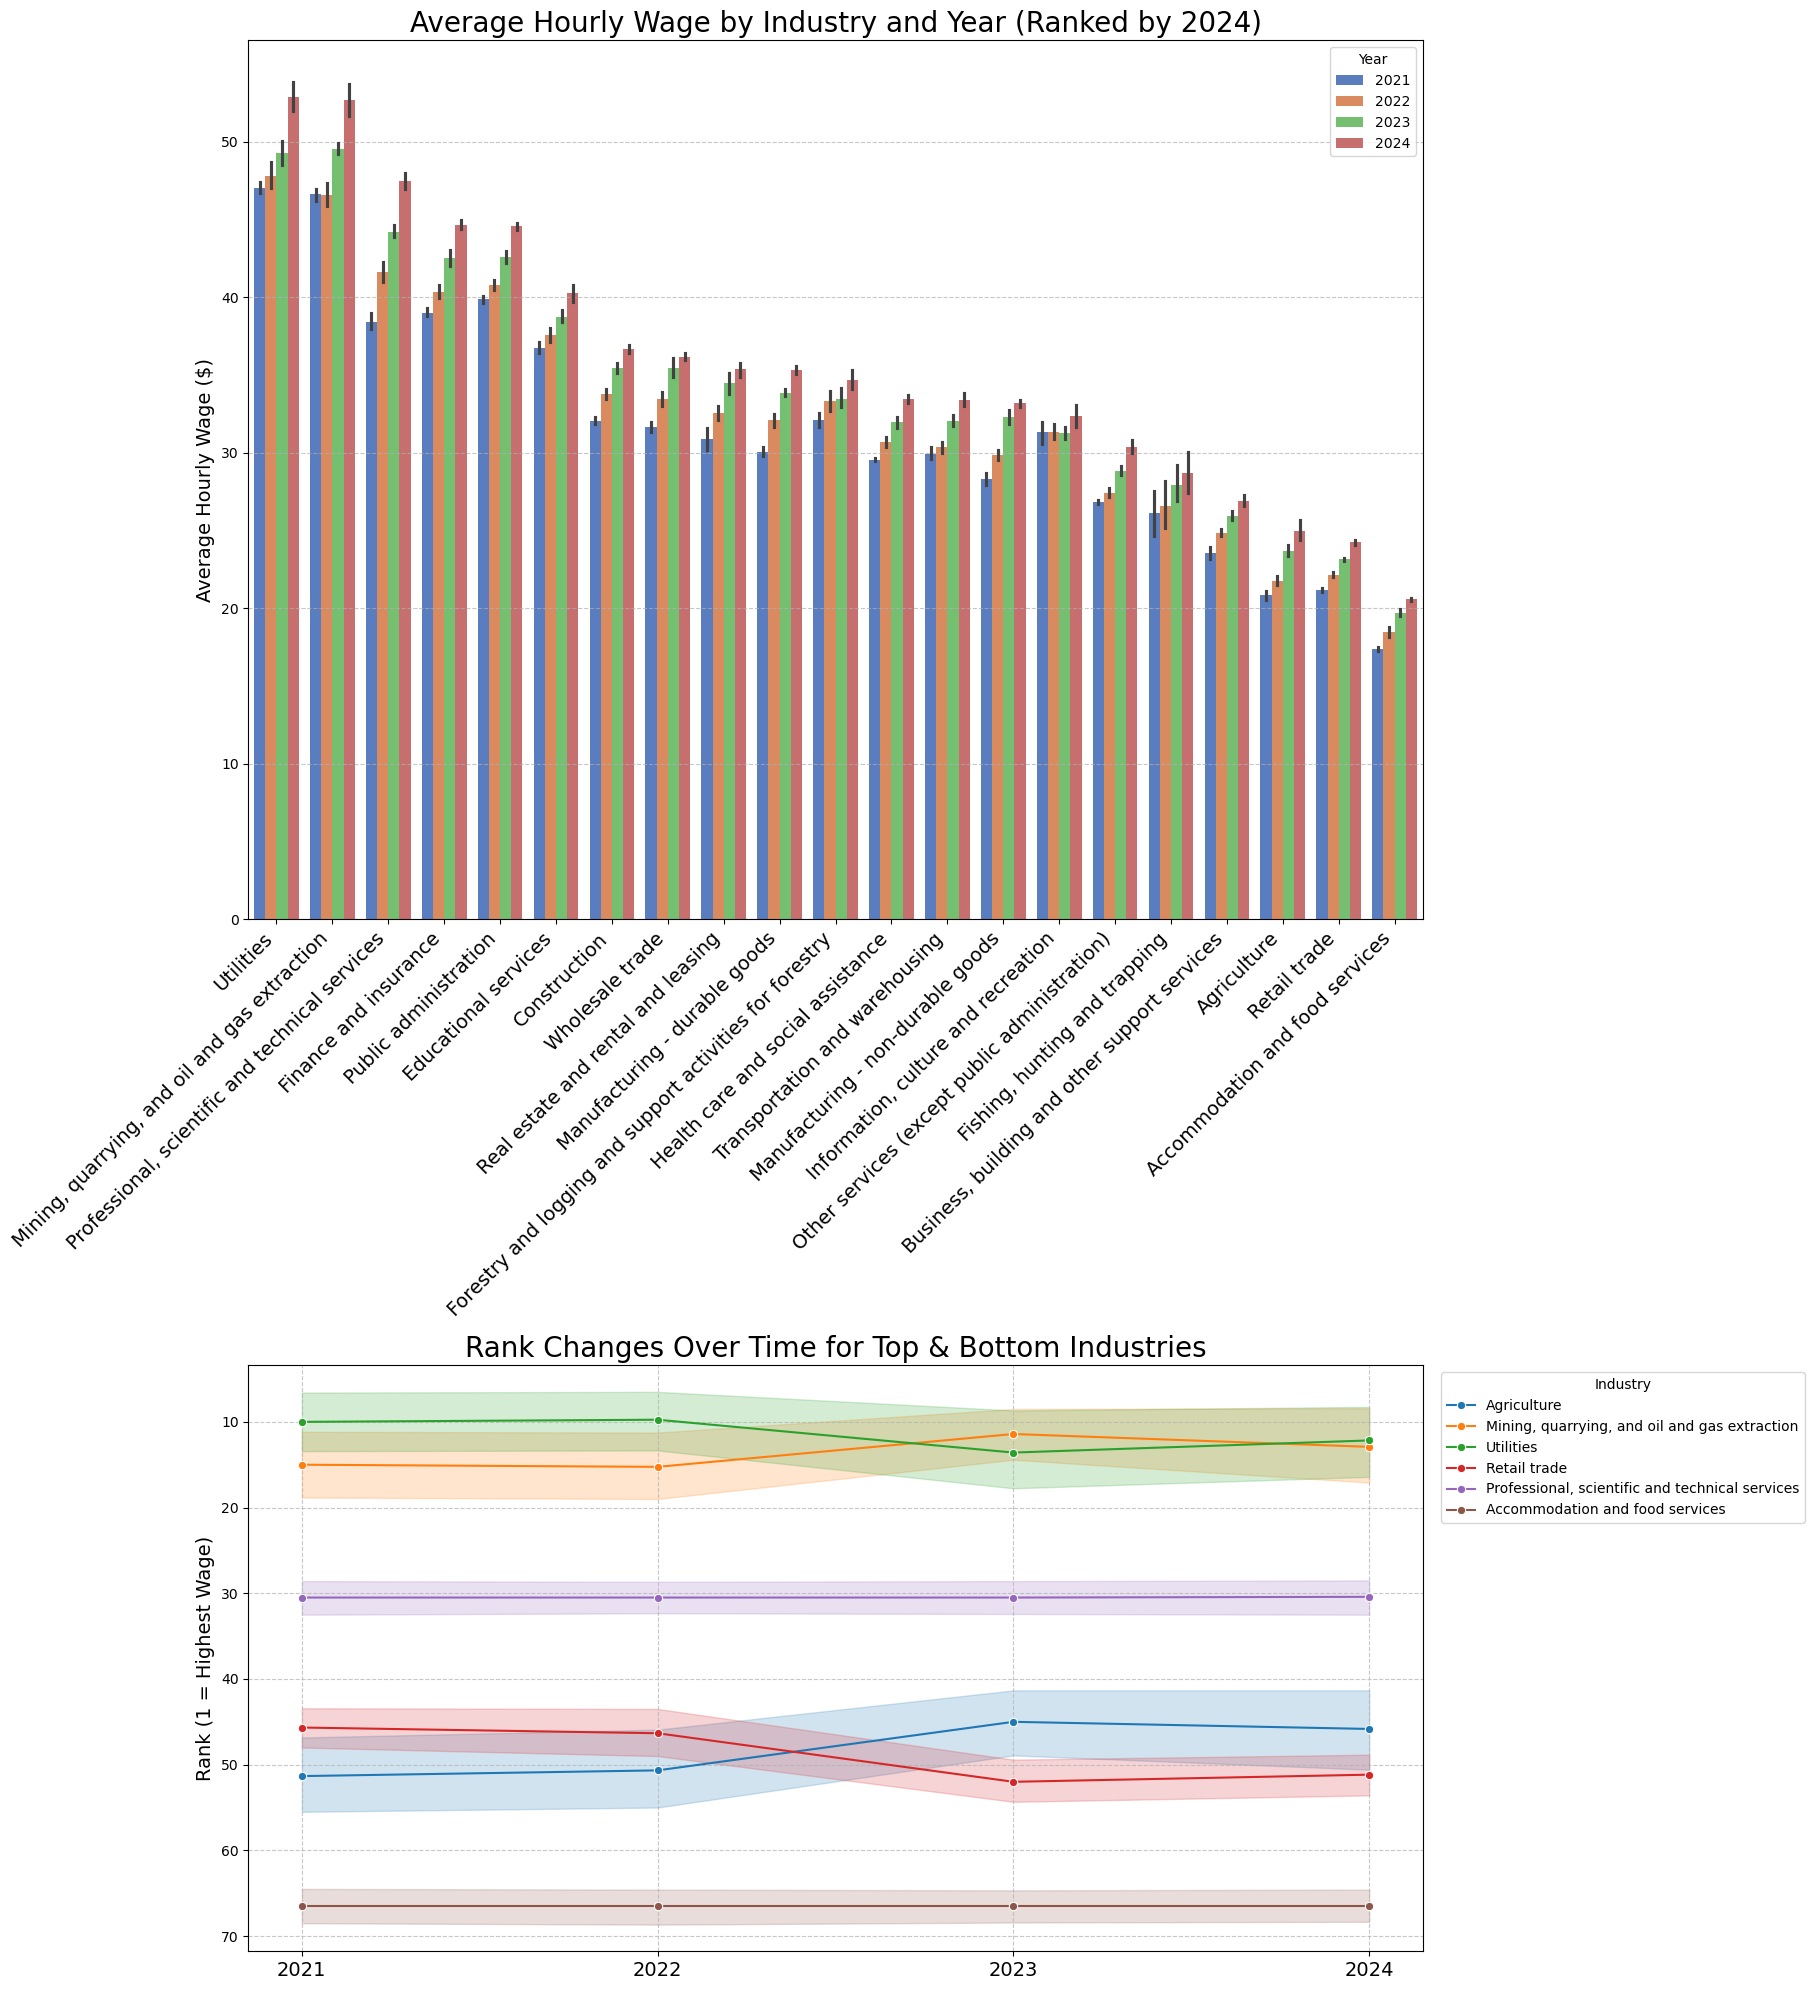

In [38]:
## Filter for 2024 and sort industries by Average Hourly Wage
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False, observed=False)["Average_Hourly_Wage"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Average_Hourly_Wage", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()


## Prepare data for the bump chart (focus on top and bottom industries based on 2024 ranking)
top_n = 3
bottom_n = 3

# Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

# Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

# For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Average_Hourly_Wage"].rank(ascending=False)


## Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

## Subplot 1: Grouped Bar Chart for Average Hourly Wage by Industry and Year
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Average_Hourly_Wage",
    hue="Year",
    order=ordered_industries, 
    palette="muted",
    ax=ax1
)
ax1.set_title("Average Hourly Wage by Industry and Year (Ranked by 2024)", fontsize=20)
ax1.set_xlabel("")
ax1.set_ylabel("Average Hourly Wage ($)", fontsize=14)
ax1.tick_params(axis="x", labelsize=12, labelrotation=45, right=True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

## Subplot 2: Bump Chart for Rank Changes Over Time for Top & Bottom Industries
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="tab10",
    ax=ax2
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=20)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Wage)", fontsize=14)
ax2.invert_yaxis()
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.tick_params(axis="x", labelsize=14)
ax2.grid(True, linestyle="--", alpha=0.7)

## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')

## Adjust layout and show the plot
plt.subplots_adjust(right=1) 
plt.tight_layout()
plt.show()


## Interpretation: Average Hourly Wage Trends by Industry (2021–2024)

### Grouped Bar Chart (Top Plot)

This plot ranks industries based on their 2024 average hourly wage and compares wage levels from 2021 to 2024.

**Key Observations:**
- The top-paying industries in 2024 include:
  - Utilities
  - Mining, quarrying, and oil & gas extraction
  - Professional, scientific, and technical services
- These industries maintained consistently high wages throughout the period.
- Other upper-tier industries include public administration, finance and insurance, and construction.
- The lowest-paying industries are:
  - Accommodation and food services
  - Retail trade
  - Agriculture
- These sectors show minimal wage growth and remain at the bottom of the wage distribution.

### Bump Chart (Bottom Plot)

This chart shows how the top 3 and bottom 3 industries (based on 2024 wages) changed rank between 2021 and 2024.

**Key Observations:**
- Top industries remained stable in their high-wage ranks with minimal change.
- Low-wage industries also retained their positions near the bottom, indicating persistent wage stratification.
- No significant upward or downward movement occurred among the selected industries.

### Summary

- High- and low-wage industries maintained their relative rankings over time.
- Wage gaps between industries remained consistent, with little convergence.
- The results suggest structural differences in compensation across sectors, with limited mobility in industry wage rankings.


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/1792155319.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/1792155319.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


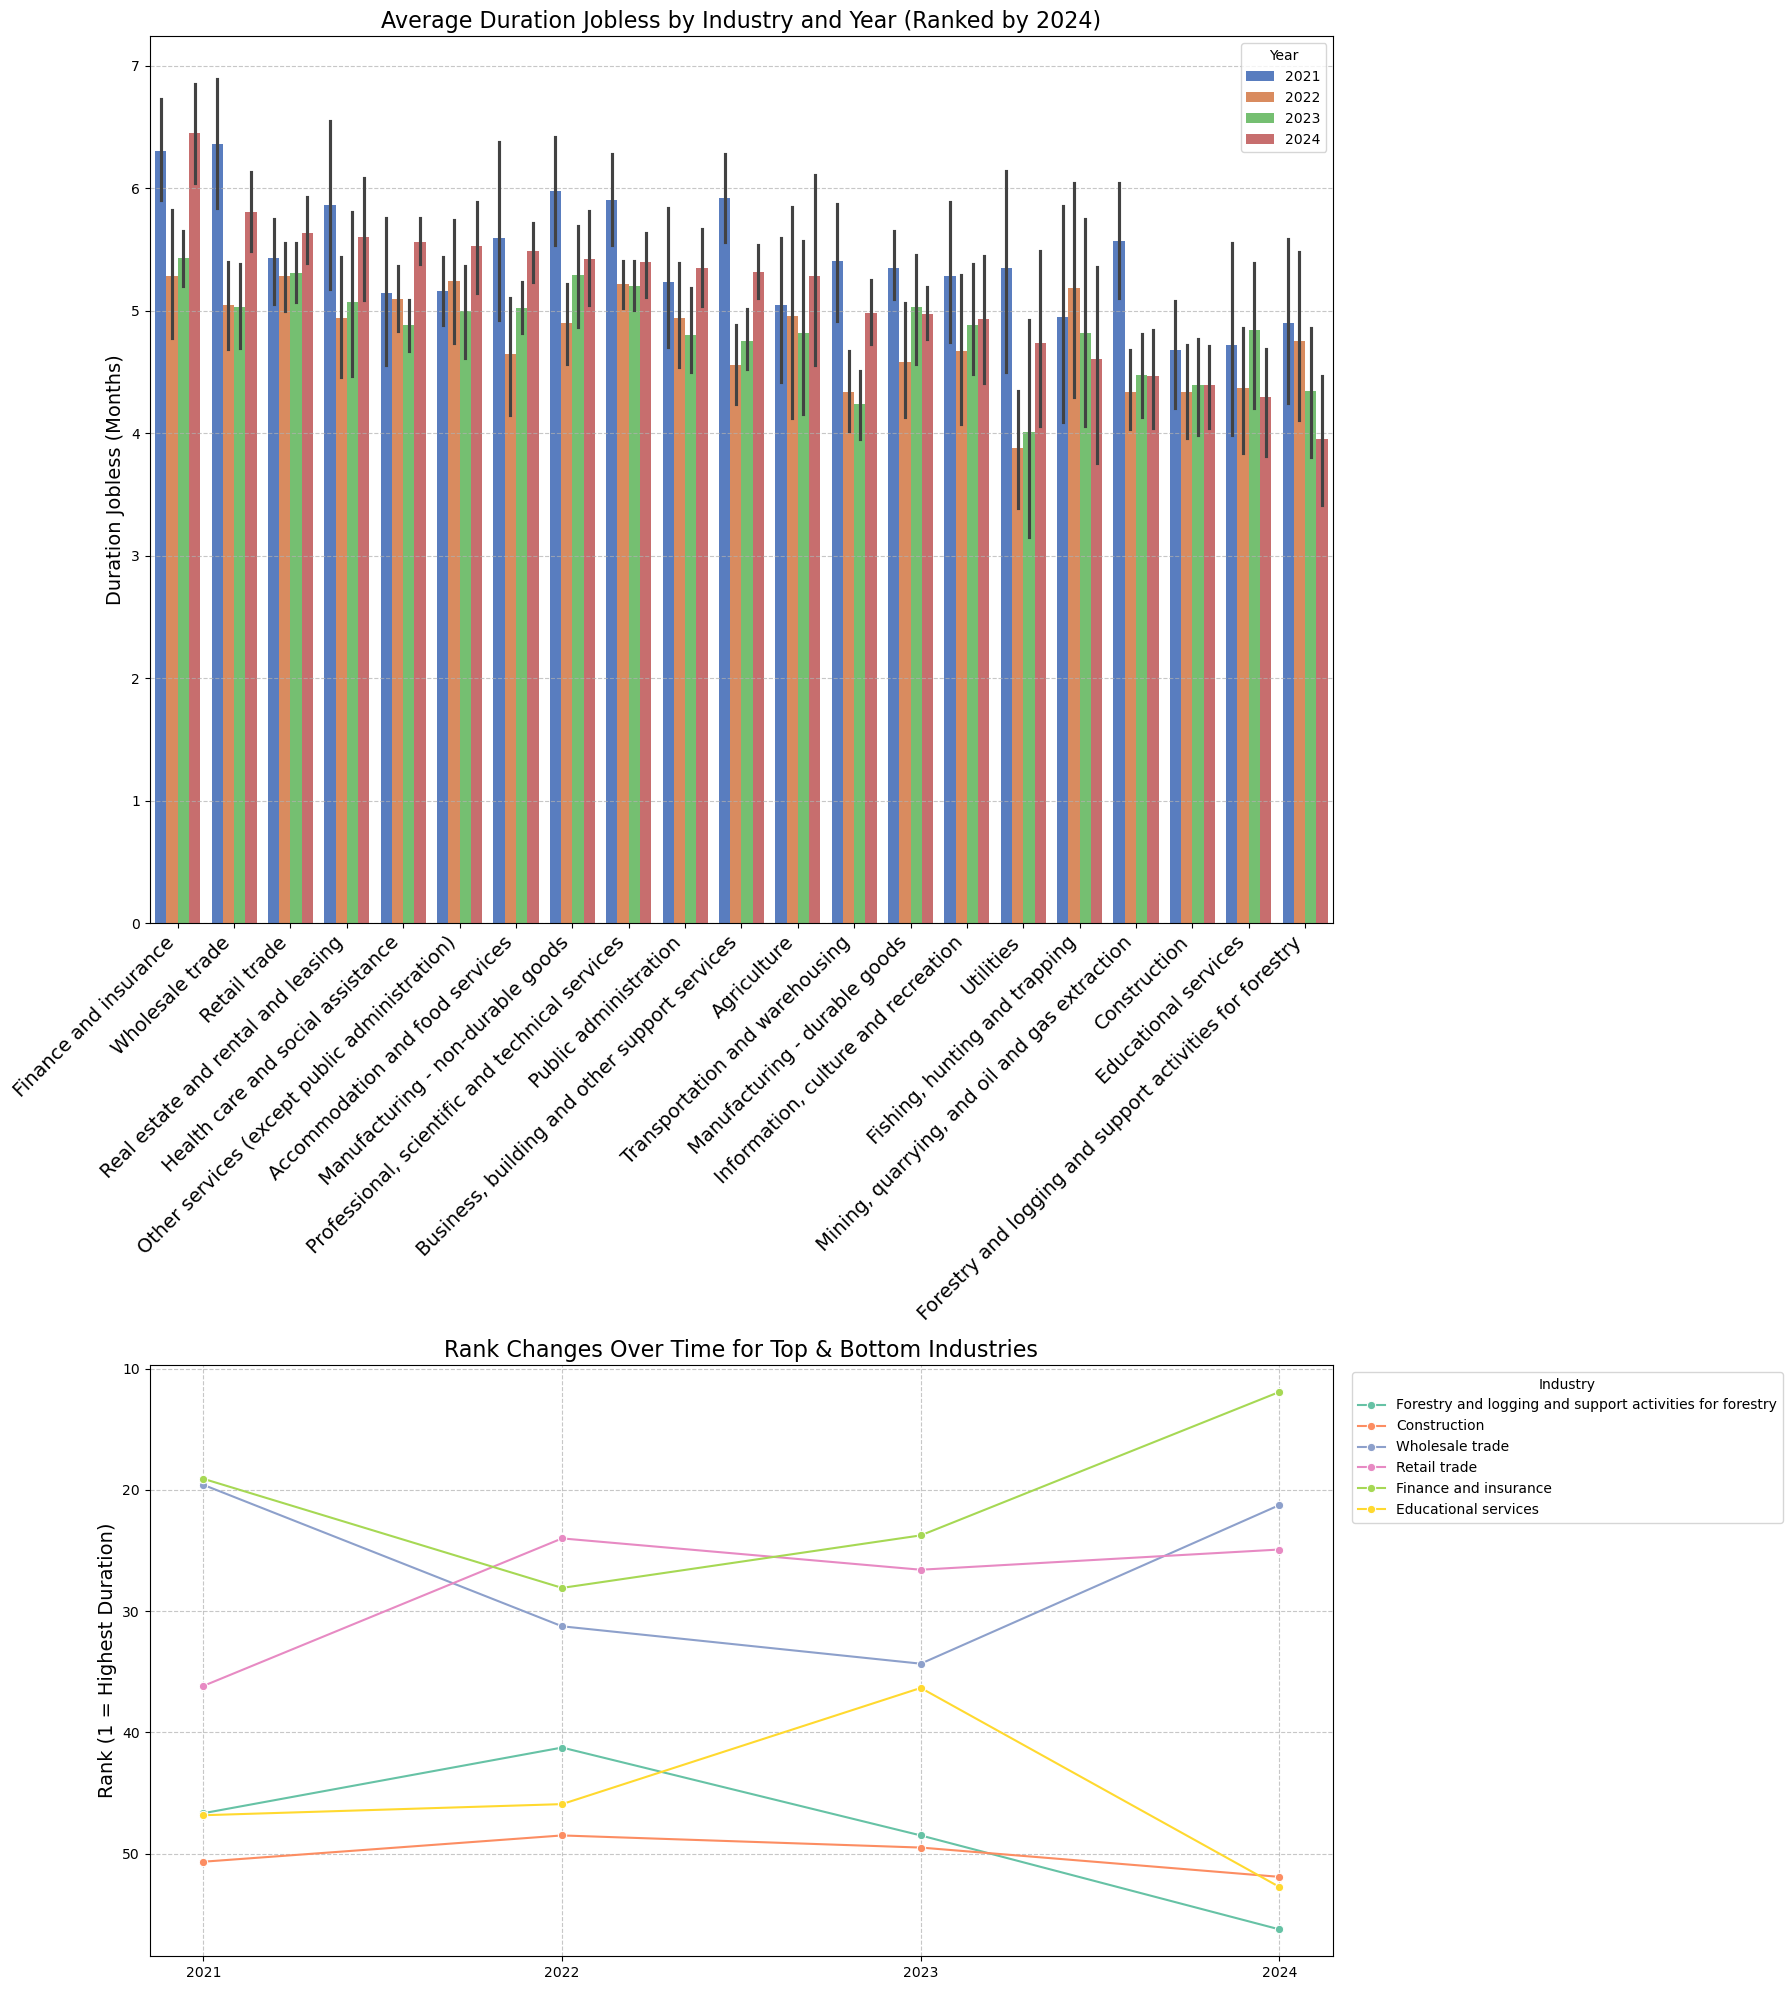

In [39]:
## Filter for 2024 and sort industries by Duration_Jobless
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False)["Duration_Jobless(Months)"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Duration_Jobless(Months)", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()

## Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

## Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

## For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Duration_Jobless(Months)"].rank(ascending=False)


## Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

## Subplot 1: Grouped Bar Chart for Duration Jobless by Industry and Year
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Duration_Jobless(Months)",
    hue="Year",
    order=ordered_industries,
    estimator=np.mean,
    palette="muted",
    ax=ax1
)
ax1.set_title("Average Duration Jobless by Industry and Year (Ranked by 2024)", fontsize=16)
ax1.set_xlabel("")
ax1.set_ylabel("Duration Jobless (Months)", fontsize=14)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)


## Subplot 2: Bump Chart for Rank Changes Over Time for Top & Bottom Industries
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="Set2",
    ax=ax2, 
    ci=None
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=16)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Duration)", fontsize=14)
ax2.invert_yaxis()  
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.grid(True, linestyle="--", alpha=0.7)



## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


## Interpretation: Average Duration Jobless by Industry (2021–2024)

### Grouped Bar Chart (Top Plot)

This chart displays the average number of months individuals remain jobless in each industry, ranked by 2024 values.

**Key Observations:**
- Industries with the longest joblessness durations in 2024 include:
  - Finance and insurance
  - Wholesale trade
  - Retail trade
- Shortest durations were observed in:
  - Forestry and logging
  - Educational services
  - Construction
- Most industries exhibit consistent trends across years with some minor fluctuations.

### Bump Chart (Bottom Plot)

Tracks rank changes from 2021 to 2024 for the top and bottom 3 industries in 2024.

**Key Observations:**
- Forestry and logging consistently ranks as the industry with the shortest average joblessness duration.
- Finance and insurance shows a notable decline in rank, indicating growing difficulty in reemployment.
- Retail and wholesale trade remain among the worst-performing industries throughout.

### Summary

Industries differ in how quickly workers are reabsorbed into the labor market. Sectors like construction and forestry show strong reemployment trends, while finance and retail face persistent delays in filling jobs or re-engaging displaced workers.


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/2245804283.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize =14)
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/2245804283.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


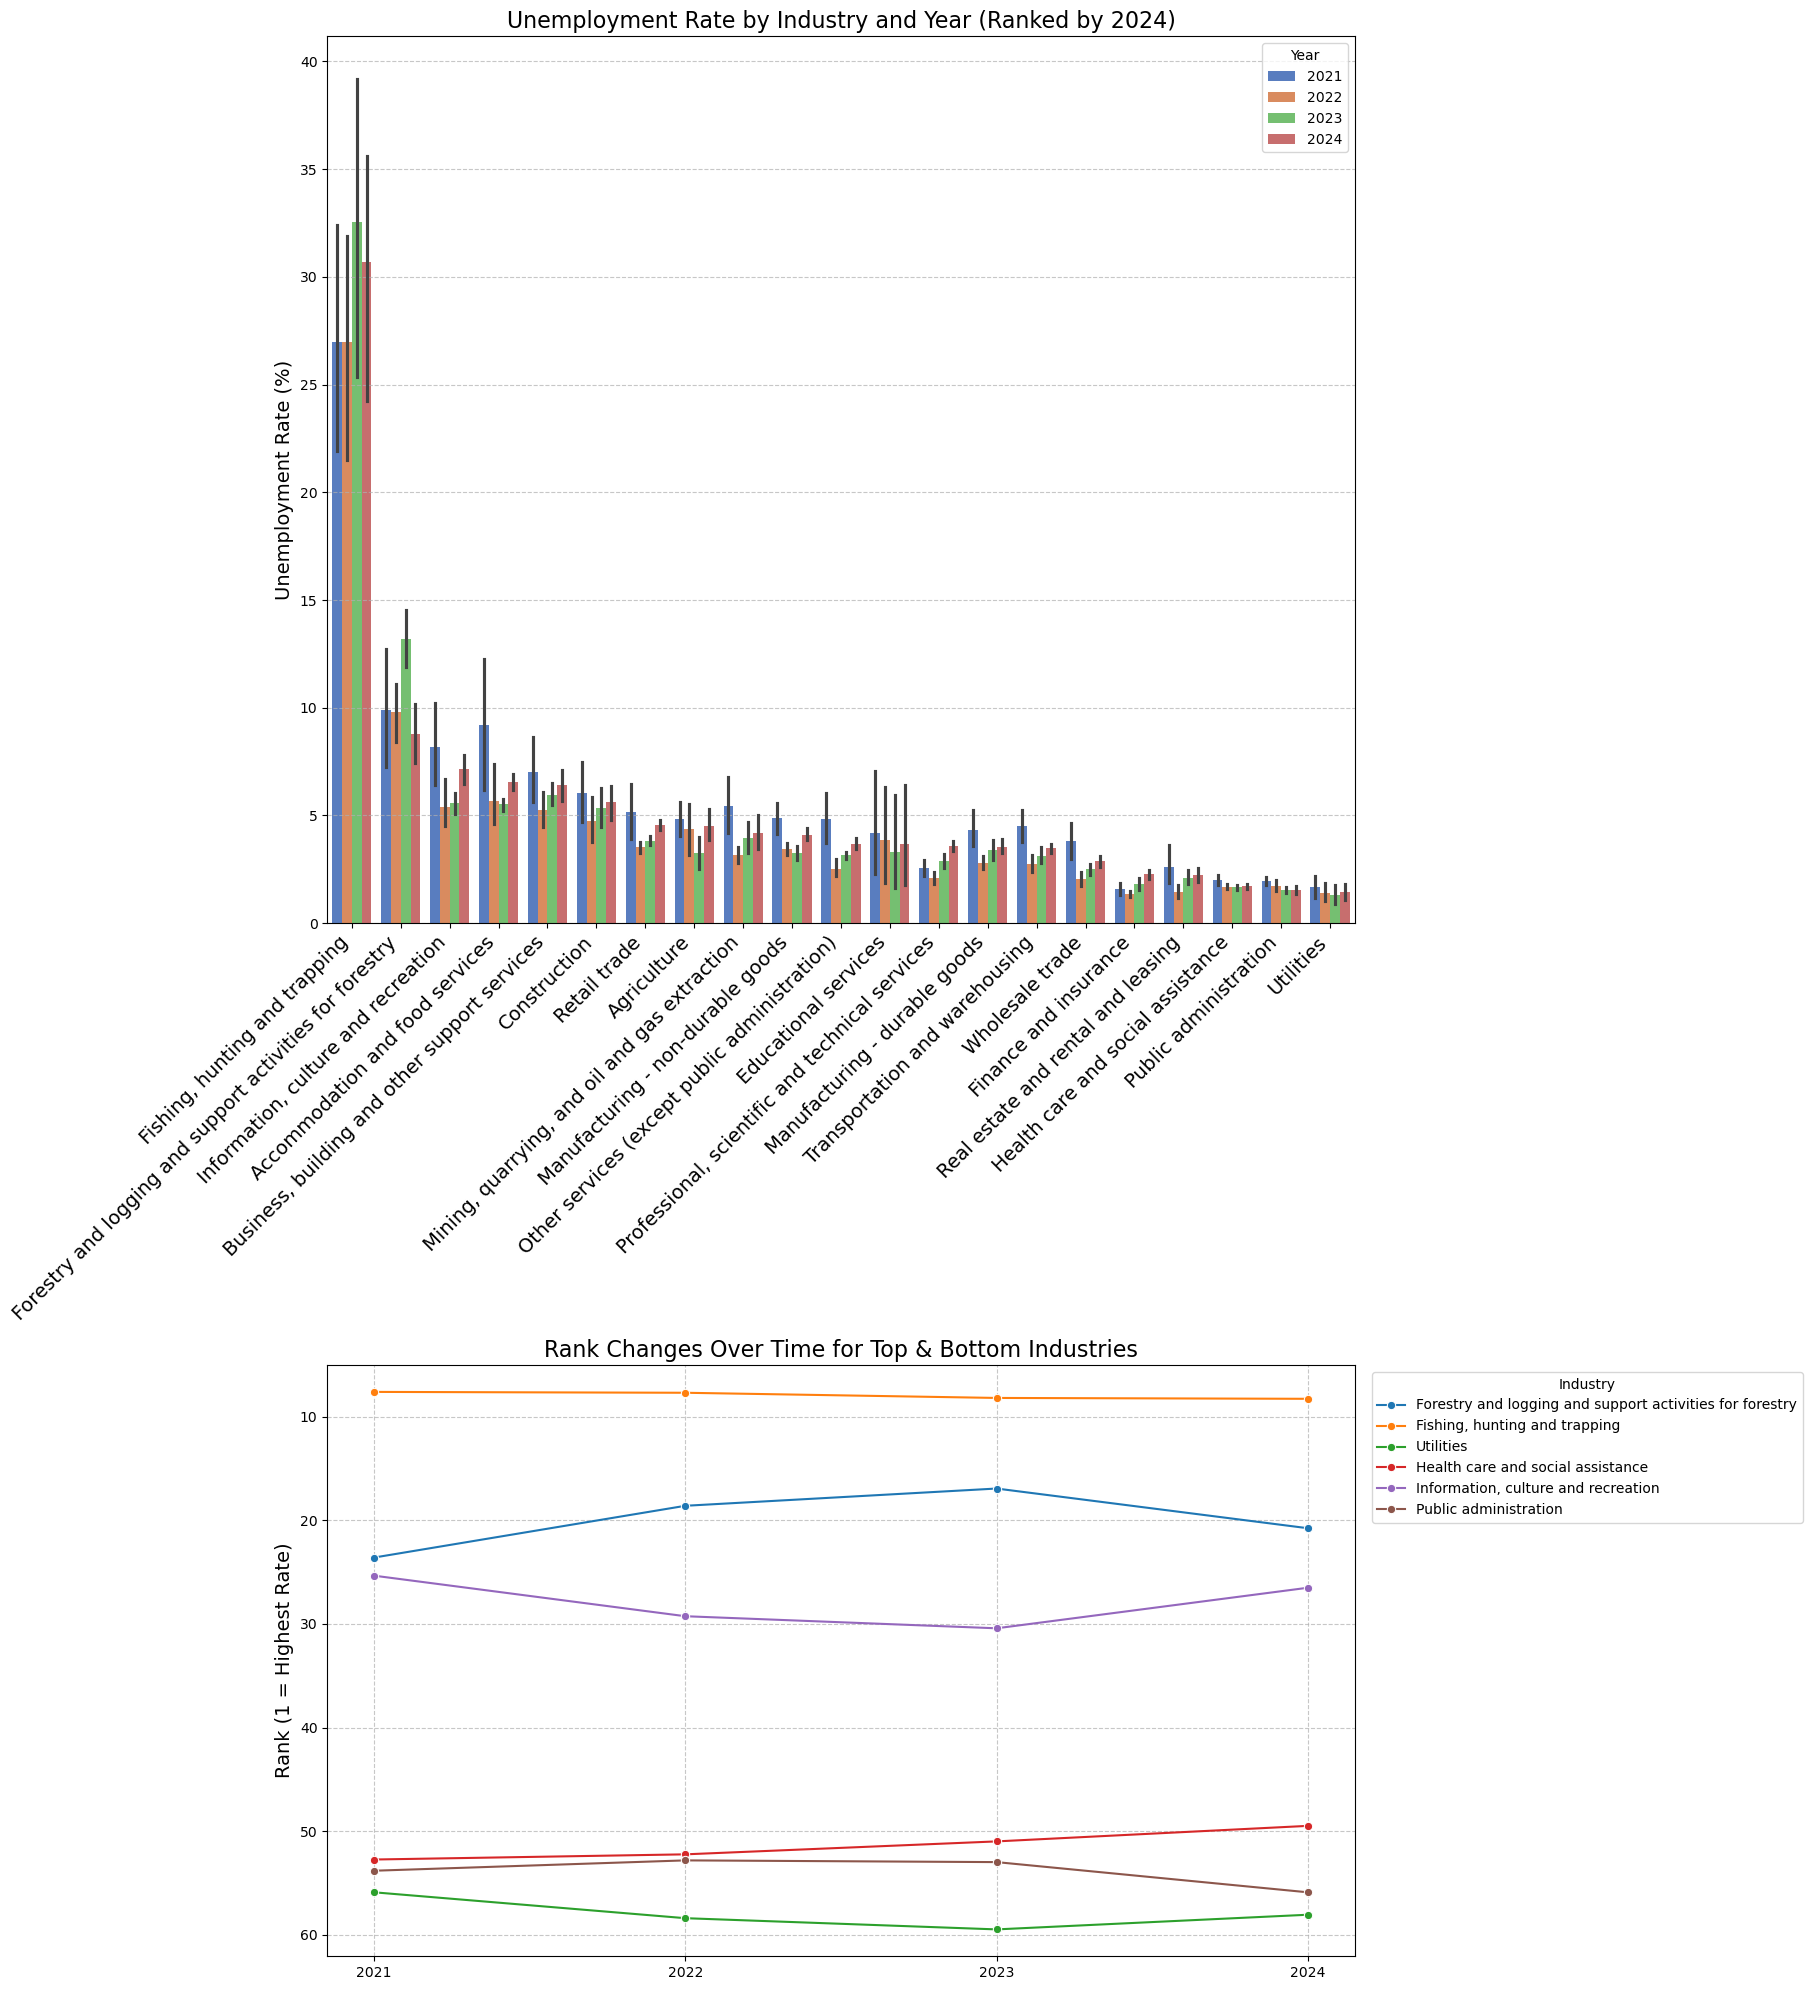

In [40]:
## Filter for 2024 and sort industries by Duration_Jobless
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False, observed=False)["Unemployment_Rate(%)"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Unemployment_Rate(%)", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()

## Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

## Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

## For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Unemployment_Rate(%)"].rank(ascending=False)


## Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

# -- Subplot 1: Grouped Bar Chart --
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Unemployment_Rate(%)",
    hue="Year",
    order=ordered_industries,
    estimator=np.mean,
    palette="muted",
    ax=ax1
)
ax1.set_title("Unemployment Rate by Industry and Year (Ranked by 2024)", fontsize=16)
ax1.set_xlabel("")
ax1.set_ylabel("Unemployment Rate (%)", fontsize=14)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize =14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# -- Subplot 2: Bump Chart for Rank Changes --
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="tab10",
    ax=ax2, 
    ci=None
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=16)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Rate)", fontsize=14)
ax2.invert_yaxis()  # Invert so that rank 1 is at the top
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Interpretation: Unemployment Rate by Industry (2021–2024)

### Grouped Bar Chart (Top Plot)

This chart compares unemployment rates by industry from 2021 to 2024, ranked by 2024 levels.

**Key Observations:**
- Industries with the highest unemployment rates in 2024:
  - Fishing, hunting and trapping
  - Forestry and logging
  - Information, culture, and recreation
- These sectors show persistently high unemployment, suggesting instability or seasonality in hiring.
- The lowest unemployment rates are found in:
  - Utilities
  - Public administration
  - Finance and insurance
- Most low-unemployment industries show year-over-year consistency, with relatively small variation.

### Bump Chart (Bottom Plot)

Displays the rank shifts over time for the 3 highest and 3 lowest unemployment industries in 2024.

**Key Observations:**
- Utilities and public administration consistently rank at the bottom (i.e., lowest unemployment), reflecting strong labor stability.
- Fishing and forestry remain at the top of the chart across the years, signaling entrenched unemployment challenges.
- Health care and social assistance hovers around mid-to-high unemployment ranks, despite its essential service status.

### Summary

Unemployment varies sharply across sectors. Some industries face persistent labor surplus and volatility (e.g., fishing, forestry), while others (e.g., utilities, public sector) maintain tight and stable employment conditions.


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_26905/777914554.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)


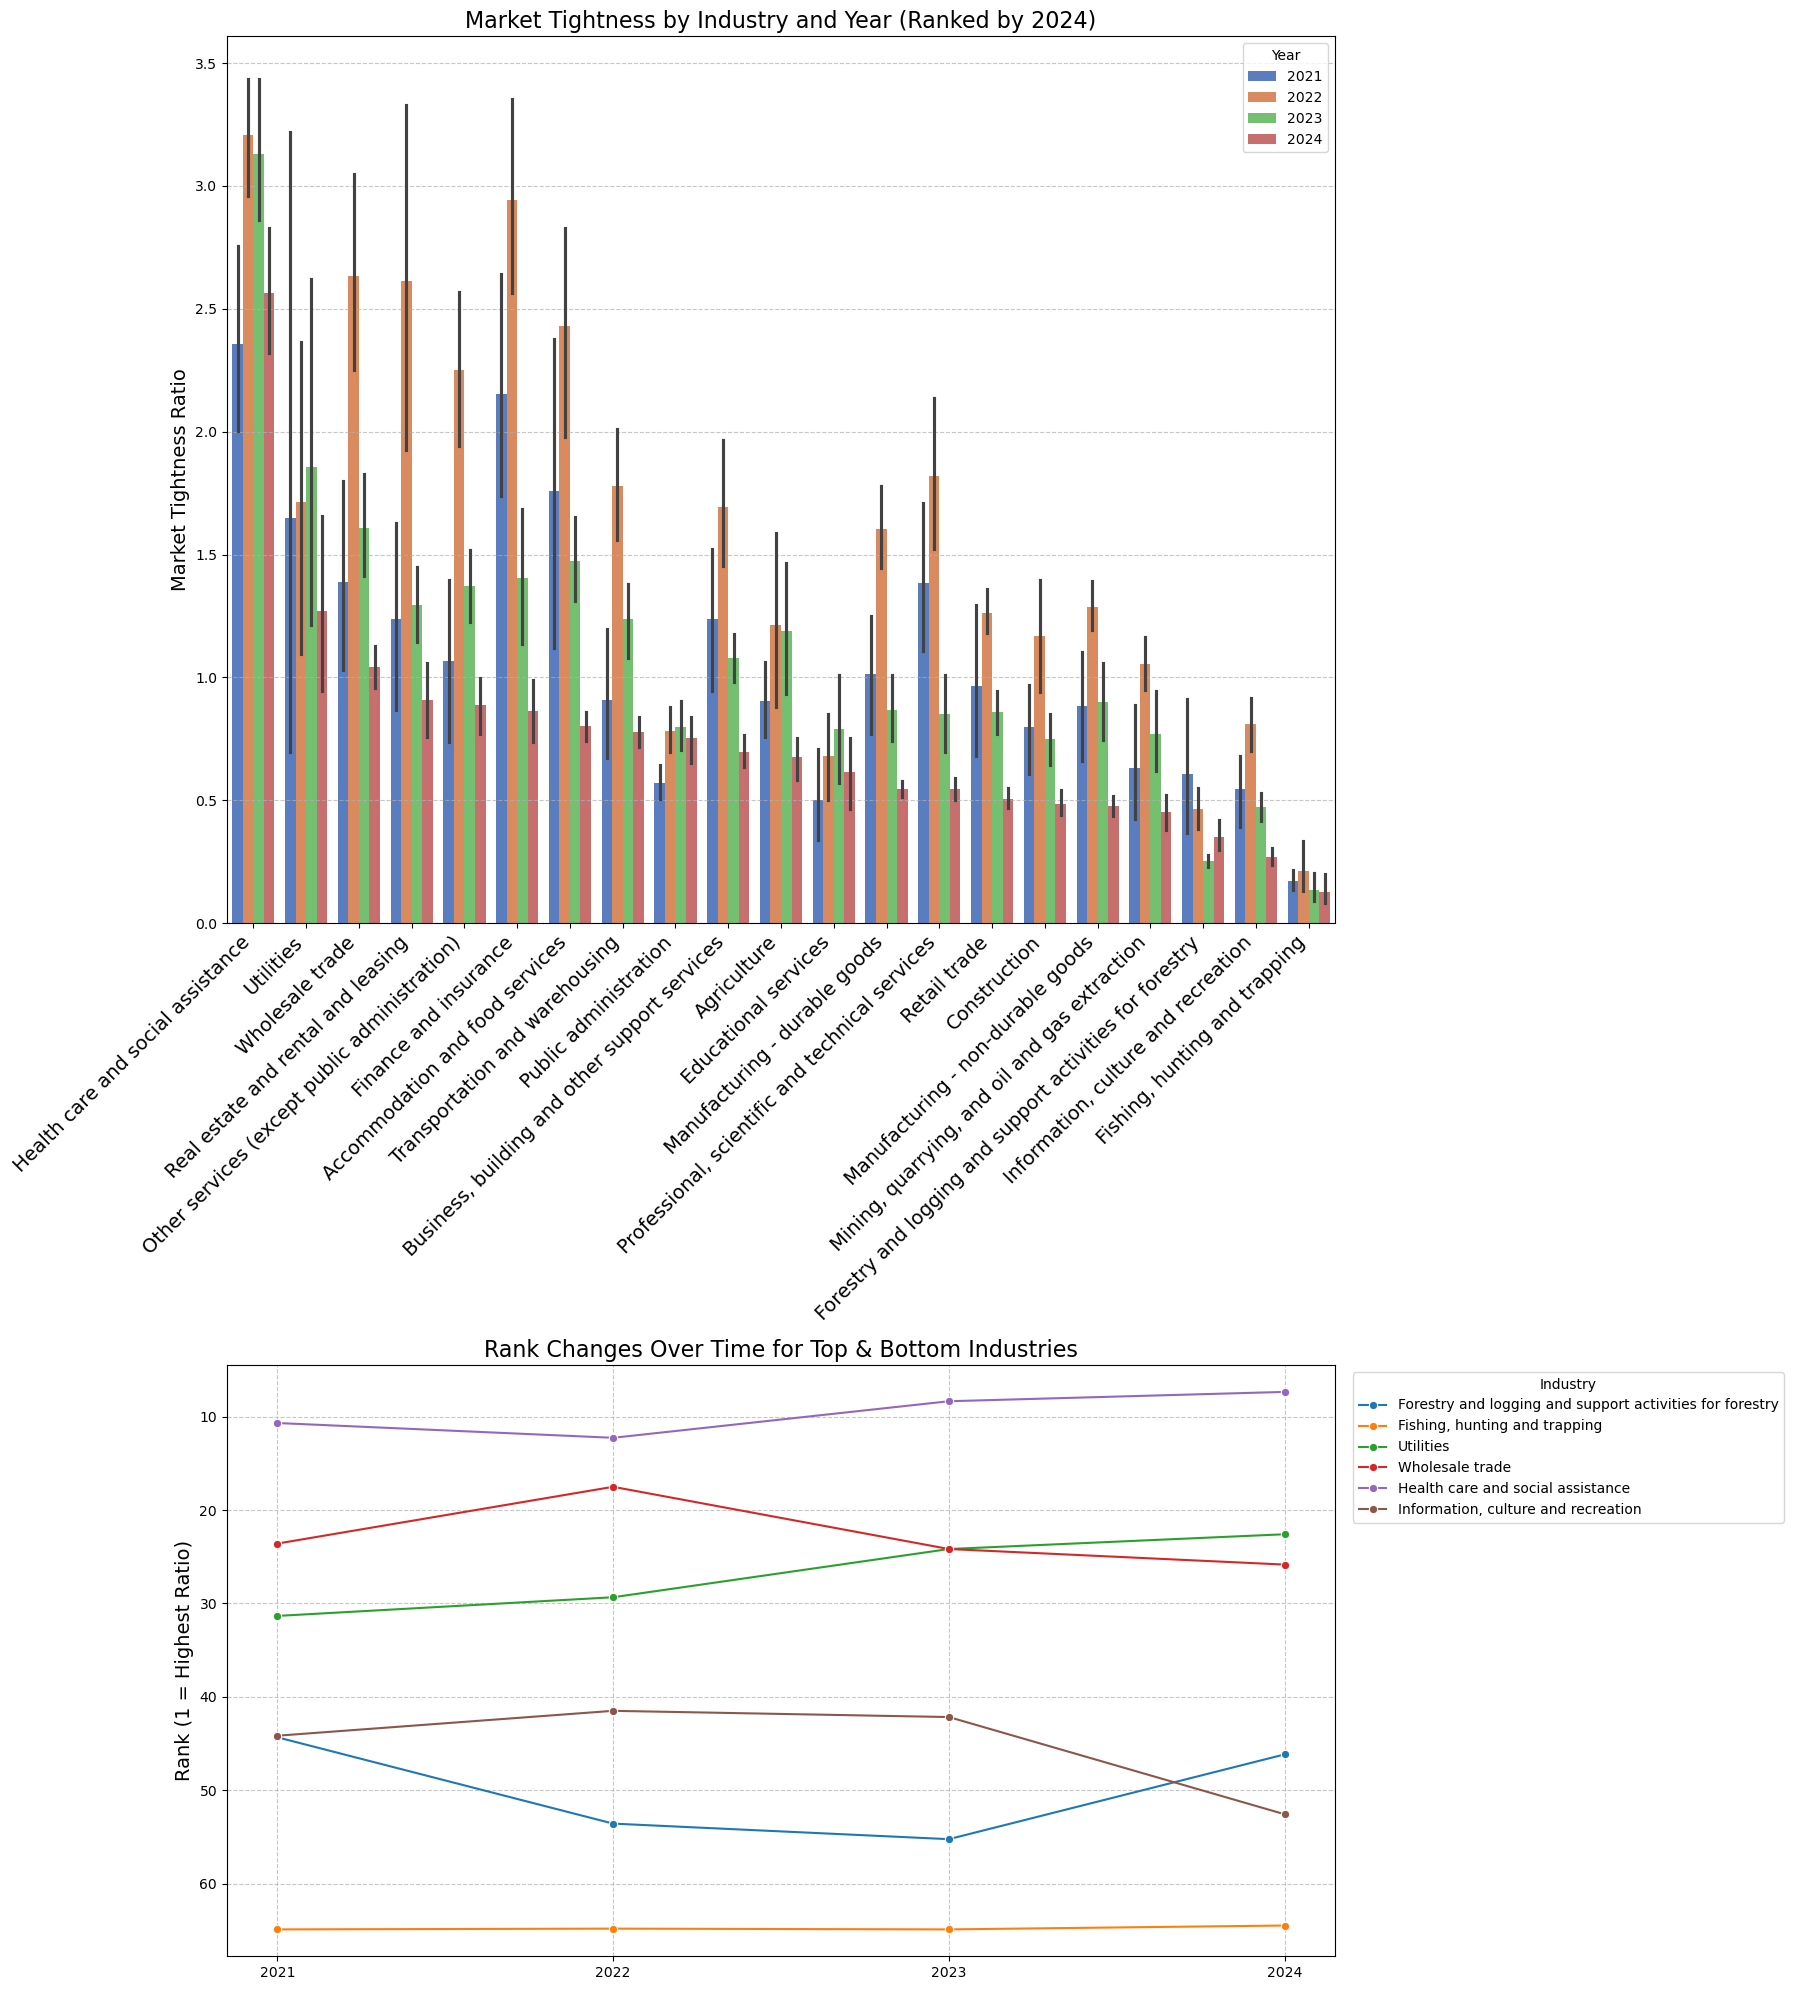

In [41]:
# Filter for 2024 and sort industries by Duration_Jobless
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False, observed=False)["Market_Tightness"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Market_Tightness", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()

# Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

# Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

# For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Market_Tightness"].rank(ascending=False)

# Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

# Subplot 1: Grouped Bar Chart for Market Tightness by Industry and Year
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Market_Tightness",
    hue="Year",
    order=ordered_industries,
    estimator=np.mean, 
    palette="muted",
    ax=ax1
)
ax1.set_title("Market Tightness by Industry and Year (Ranked by 2024)", fontsize=16)
ax1.set_xlabel("")
ax1.set_ylabel("Market Tightness Ratio", fontsize=14)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# -- Subplot 2: Bump Chart for Rank Changes --
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="tab10",
    ax=ax2, 
    errorbar=None
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=16)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Ratio)", fontsize=14)
ax2.invert_yaxis()  # Invert so that rank 1 is at the top
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


## Interpretation: Market Tightness by Industry (2021–2024)

### Grouped Bar Chart (Top Plot)

Displays the market tightness ratio across industries from 2021 to 2024, ranked by 2024 values.

**Highest market tightness in 2024:**
- Health care and social assistance  
- Utilities  
- Wholesale trade  

**Lowest market tightness:**
- Fishing, hunting and trapping  
- Information, culture and recreation  
- Forestry and logging  

Most industries show a decline in market tightness from 2021 to 2024.

### Bump Chart (Bottom Plot)

Tracks rank changes for the top 3 and bottom 3 industries based on 2024 market tightness.

- Health care and wholesale trade consistently rank high.
- Fishing and information services remain at the bottom.
- Utilities drop in rank but stay within the top group.

### Summary

Sectors like health care and wholesale trade maintain high tightness, indicating persistent labor shortages. In contrast, industries like fishing and recreation continue to exhibit weak labor demand relative to supply.

In [42]:
def plot_dual_axis(data, left_var, right_var, left_label, right_label, left_color='tab:blue', right_color='tab:red'):

    """This function creates a dual-axis time series plot for a given industry,
plotting one variable on the left y-axis and another on the right y-axis.
It is designed to be used inside a seaborn FacetGrid (one subplot per industry)."""

    ax = plt.gca()
    
    # Plot primary (left y-axis) variable
    ax.plot(data['REF_DATE'], data[left_var], color=left_color)
    ax.set_ylabel(left_label, color=left_color, fontsize=10)
    ax.tick_params(axis='y', labelcolor=left_color, labelsize=9)
    ax.tick_params(axis='x', labelsize=8)

    # Plot secondary (right y-axis) variable
    ax2 = ax.twinx()
    ax2.plot(data['REF_DATE'], data[right_var], color=right_color)
    ax2.set_ylabel(right_label, color=right_color, fontsize=10)
    ax2.tick_params(axis='y', labelcolor=right_color, labelsize=9)

    # Title each facet with industry name
    if 'NAICS_21_Label' in data.columns:
        ax.set_title(data['NAICS_21_Label'].iloc[0], fontsize=11)

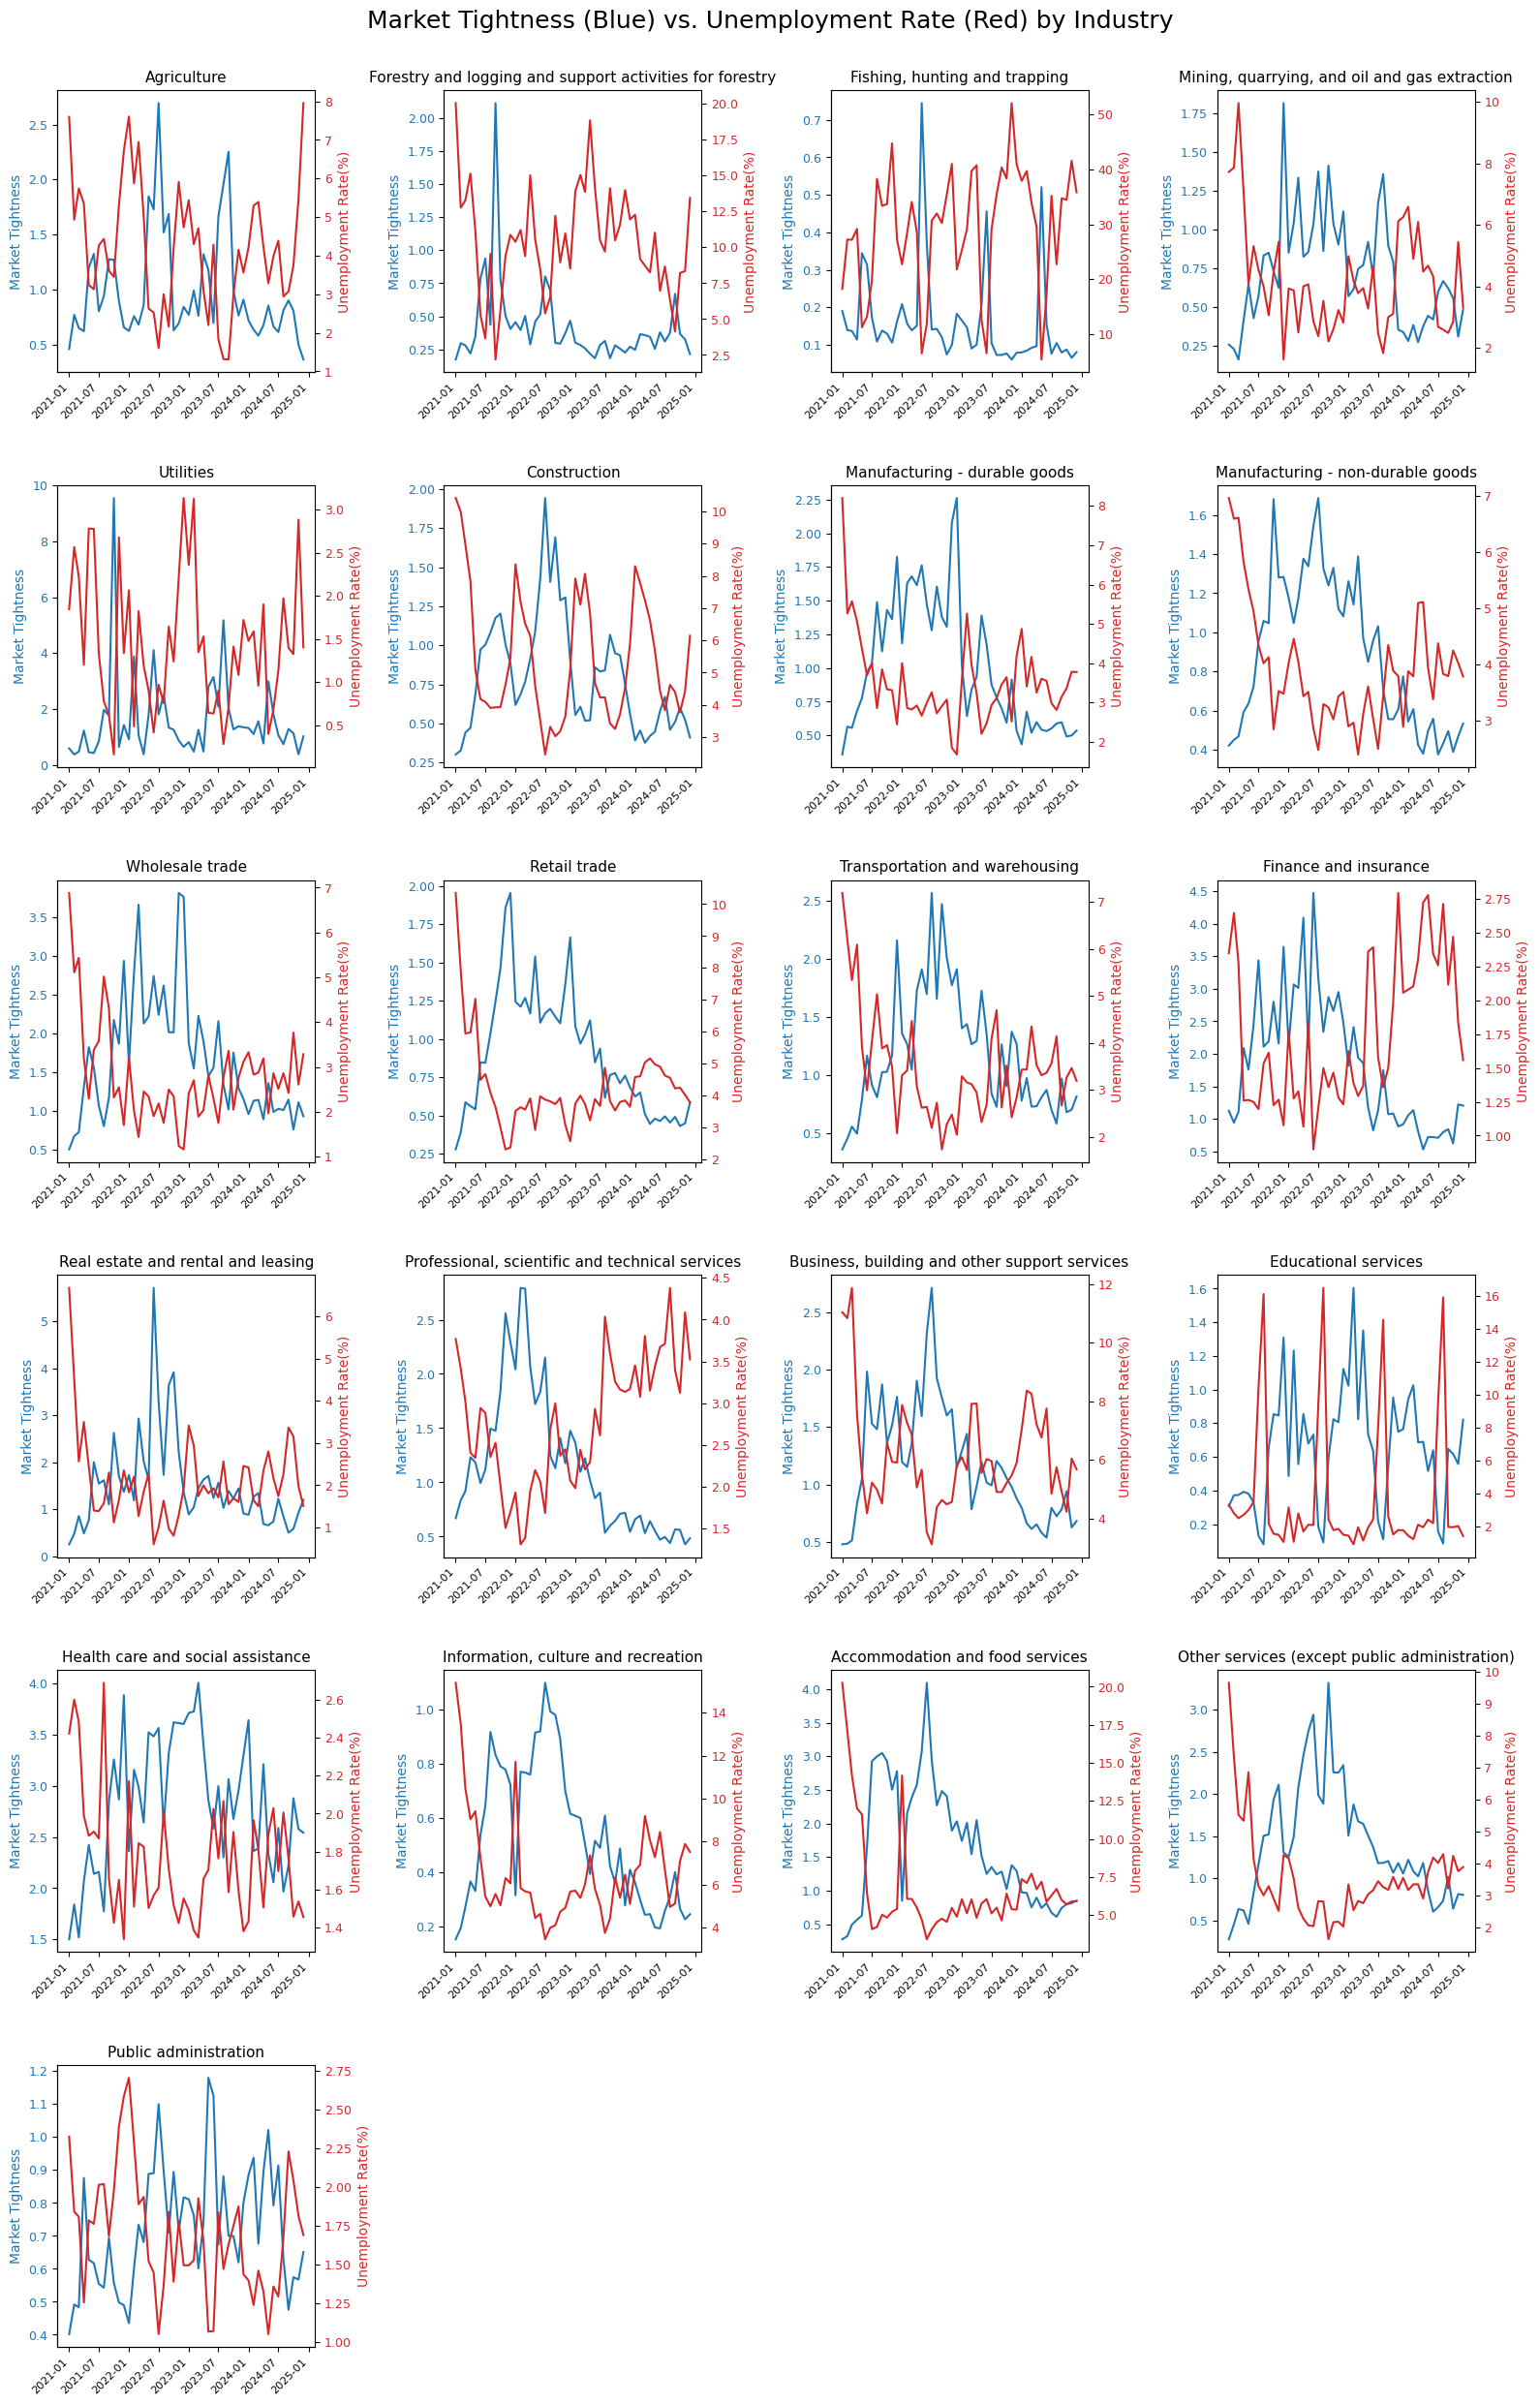

In [43]:
# Create a FacetGrid for all industries
g = sns.FacetGrid(
    industry_trends, 
    col="NAICS_21_Label", 
    col_wrap=4, 
    height=4,        
    sharex=False, 
    sharey=False
)

# Map function onto the FacetGrid
g.map_dataframe(lambda data, **kwargs: plot_dual_axis(
    data,
    left_var='Market_Tightness',
    right_var='Unemployment_Rate(%)',
    left_label='Market Tightness',
    right_label='Unemployment Rate(%)'
))

# Rotate x-axis labels in each facet
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.5)
plt.suptitle("Market Tightness (Blue) vs. Unemployment Rate (Red) by Industry", fontsize=18, y=1.02)
plt.show()


#### **Market Tightness vs. Unemployment Rate (by Industry)**
- **General Pattern:** Most industries show an inverse relationship—higher **market tightness** tends to correspond with lower **unemployment rates**.
- **Clear Examples:** 
  - Industries like **Accommodation and Food Services** and **Retail Trade** display a strong mirrored relationship between tightness and unemployment.
- **Weaker Relationships:** In sectors like **Public Administration**, this pattern is less apparent, suggesting other influencing factors.

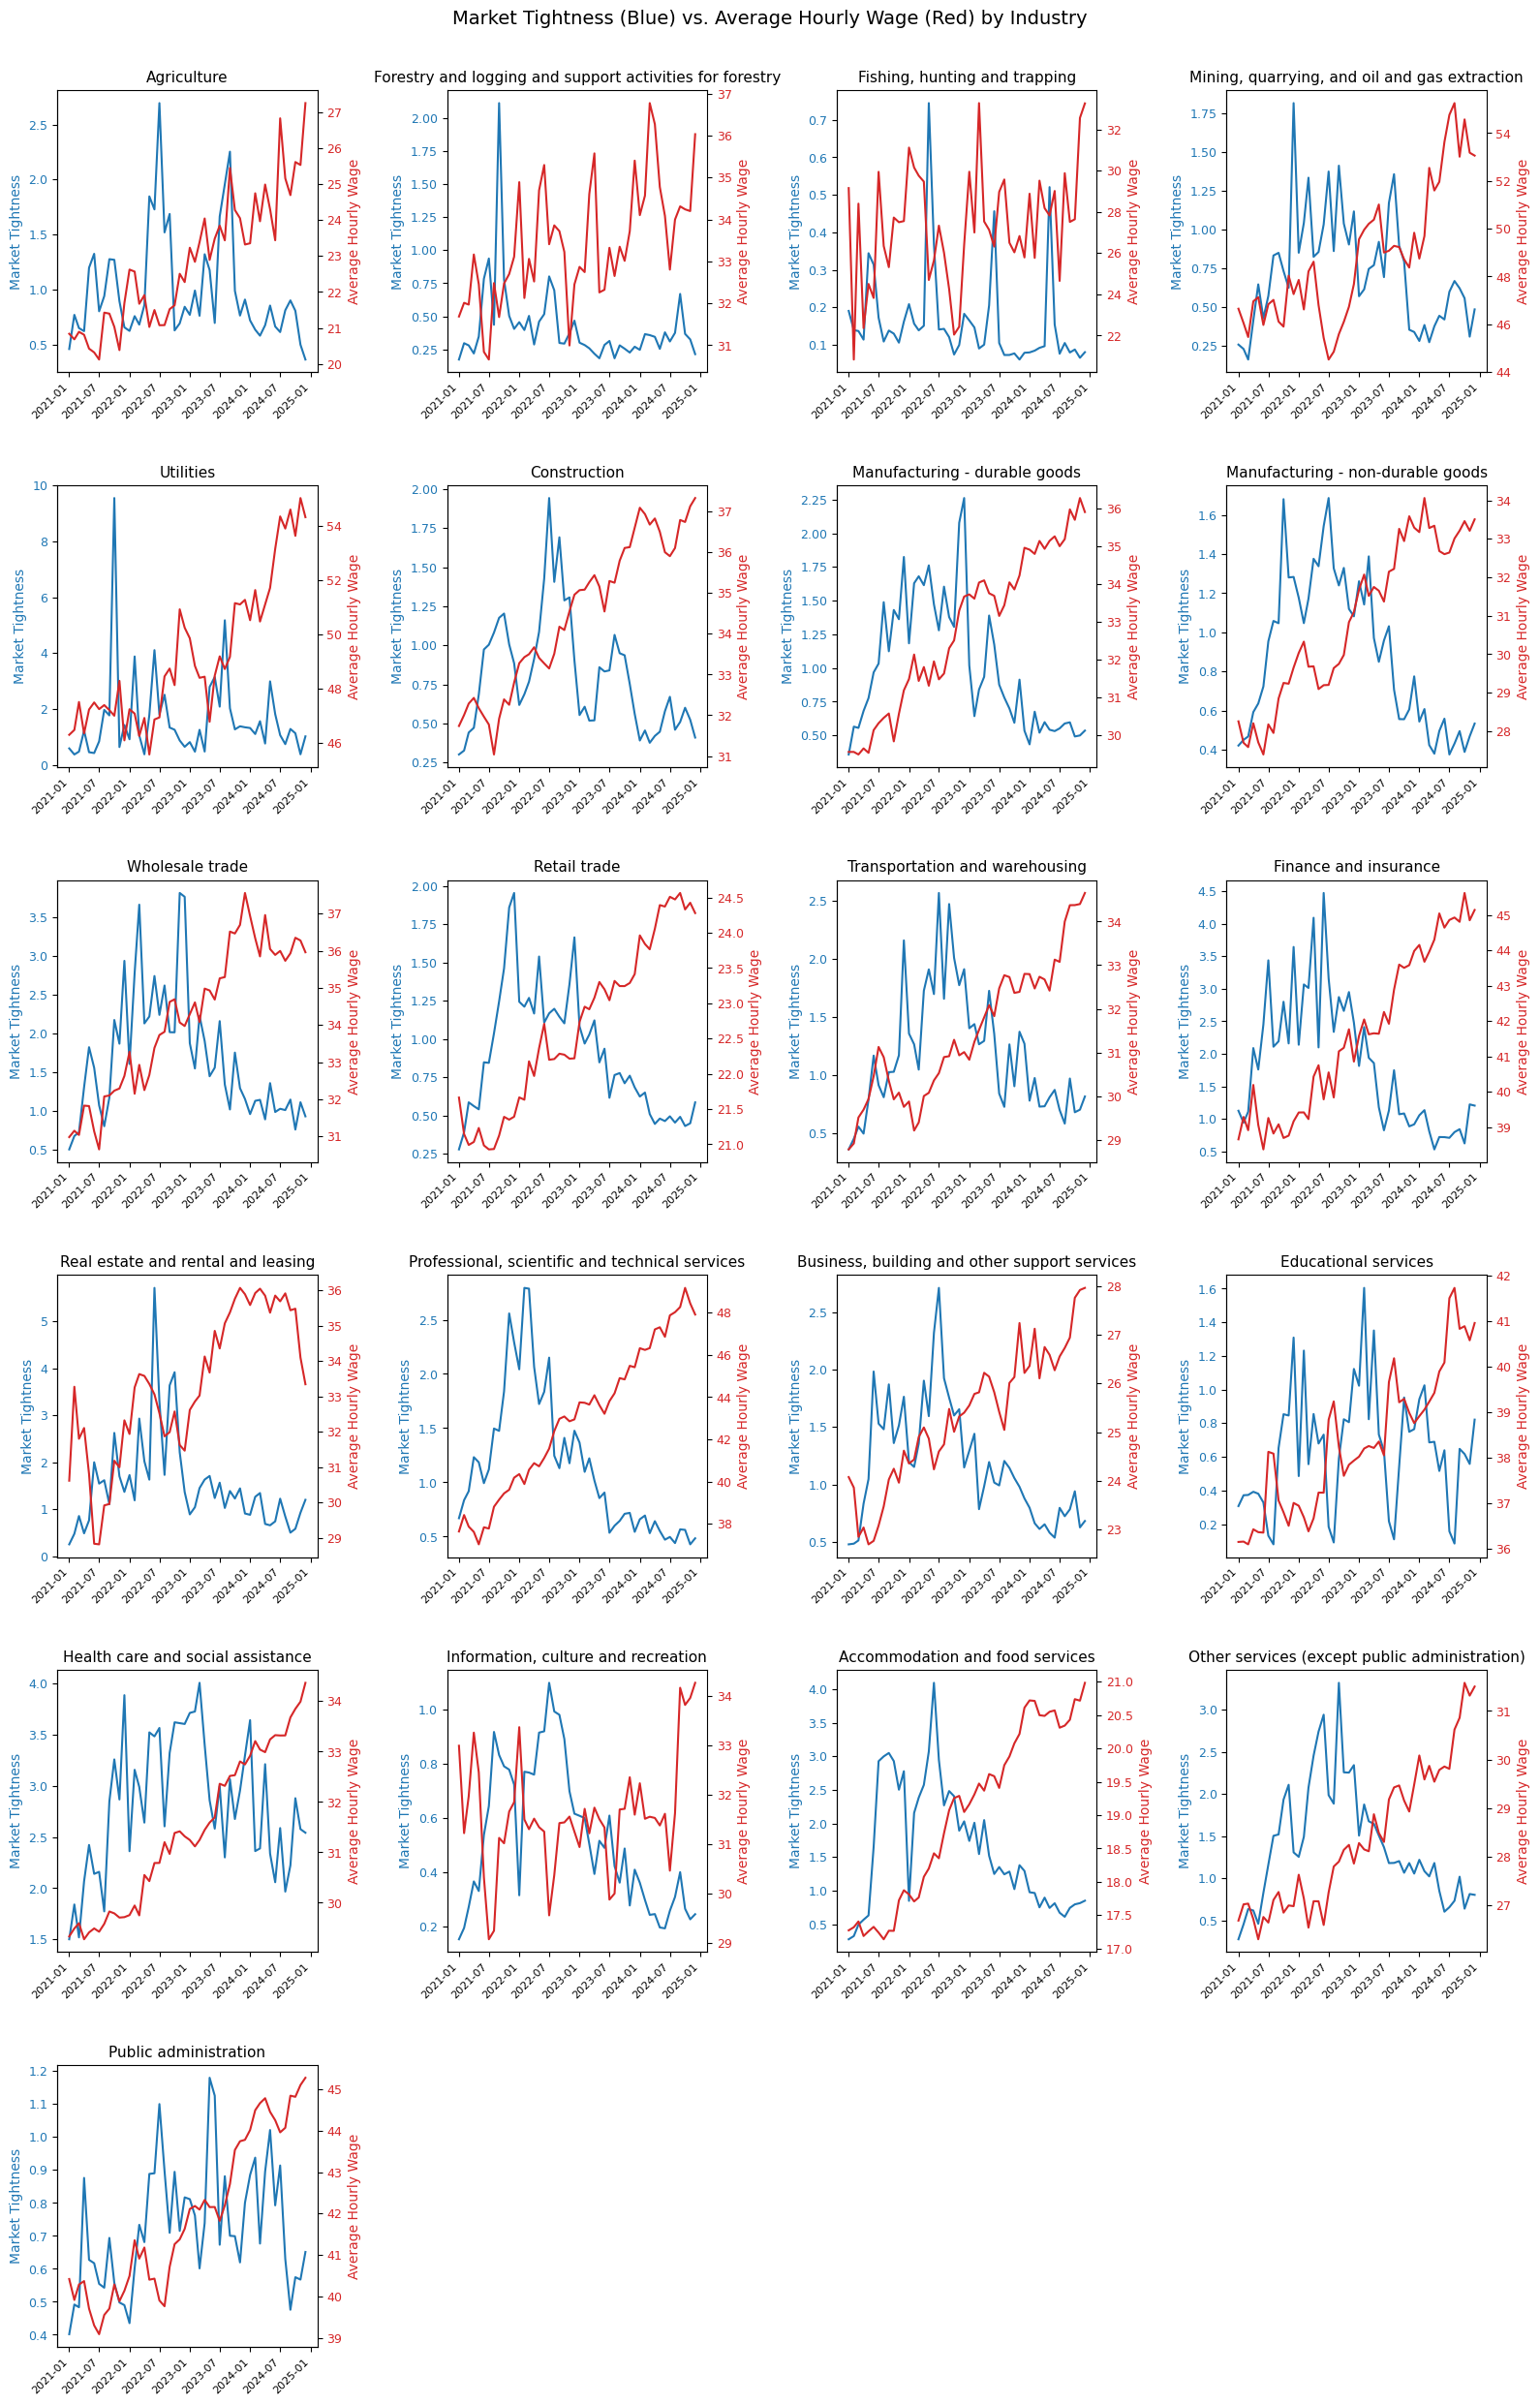

In [44]:
# Create the FacetGrid for all industries
g = sns.FacetGrid(
    industry_trends, 
    col="NAICS_21_Label", 
    col_wrap=4, 
    height=4, 
    sharex=False, 
    sharey=False
)

# Apply the reusable function using lambda to pass parameters
g.map_dataframe(lambda data, **kwargs: plot_dual_axis(
    data,
    left_var='Market_Tightness',
    right_var='Average_Hourly_Wage',
    left_label='Market Tightness',
    right_label='Average Hourly Wage'
))

# Rotate x-axis labels
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Adjust layout and title
plt.subplots_adjust(hspace=0.4, wspace=0.5)
plt.suptitle("Market Tightness (Blue) vs. Average Hourly Wage (Red) by Industry", fontsize=14, y=1.02)
plt.show()


#### **Market Tightness vs. Average Hourly Wage (by Industry)**
- **Positive Trends in Some Sectors:** Many industries (e.g., **Construction**, **Finance**, **Utilities**) show rising wages alongside increased market tightness.
- **Delayed Wage Adjustments:** In certain cases, wage growth appears to lag behind changes in tightness, pointing to potential wage rigidity.
- **Weaker Signals:** Sectors like **Retail** and **Accommodation** show minimal wage responsiveness despite tight labor conditions.

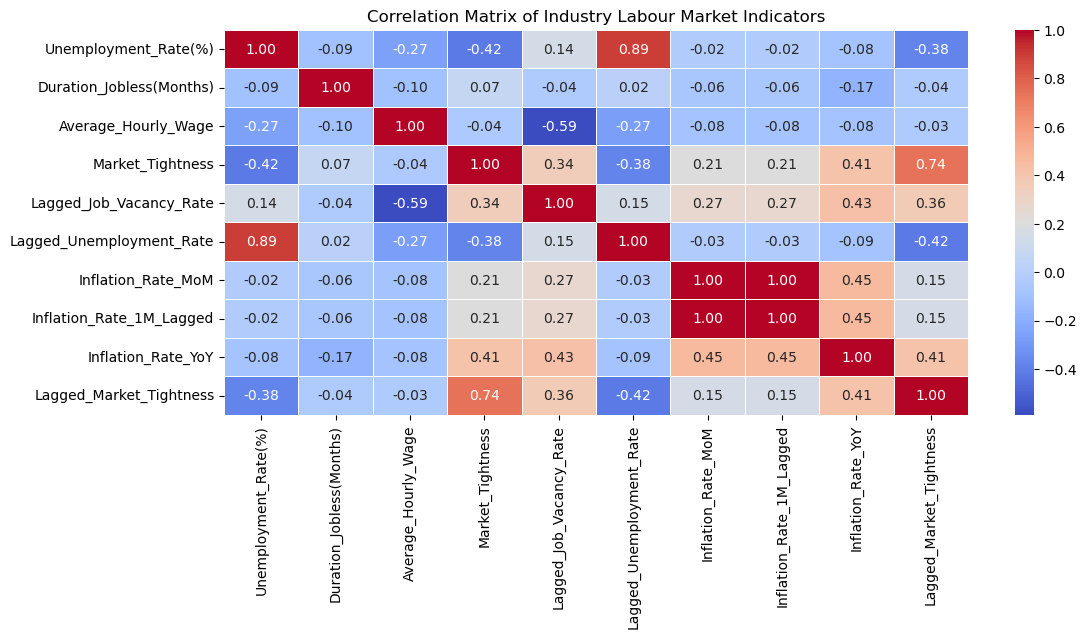

In [45]:
# Listing variables of interest
var_of_interest = (['Unemployment_Rate(%)', 'Duration_Jobless(Months)', 'Average_Hourly_Wage', 'Market_Tightness', 
                    'Lagged_Job_Vacancy_Rate', 'Lagged_Unemployment_Rate', 'Inflation_Rate_MoM', 'Inflation_Rate_1M_Lagged', 
                    'Inflation_Rate_YoY', 'Lagged_Market_Tightness'])

# Compute correlation matrix
industry_trends_corr = industry_trends[var_of_interest].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 5))
sns.heatmap(industry_trends[var_of_interest].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Industry Labour Market Indicators")
plt.show()

#### **Correlation Matrix (All Industries Combined)**
- **Unemployment vs. Tightness:** Moderate **negative correlation** (-0.42), aligning with theory.
- **Lagged Indicators:**
  - **Unemployment Rate** is highly correlated with its lagged value (0.89), indicating persistence.
  - **Market Tightness** is strongly correlated with its lag (0.74) and with **Lagged Job Vacancy Rate** (0.34).
- **Wage-Tightness Relationship:** Weak correlation (-0.04), reinforcing that wage responsiveness may be **industry-specific** rather than generalizable.

Inflation_Rate_1M_Lagged & Lagged_Unemploymend_Rate(%) show perfect or near-perfect correlation with Inflation_Rate_MoM and Unemployment_Rate(%) and will be not be used for modeling to avoid overfitting and instability. 

## How do demographic factors (age, gender, education, etc.) influence unenemployment?

#### Creating functions to calculate labour market indicators

In [46]:
def calculate_labour_market_indicators(LFS, category):
    """
    Calculate the weighted Labour Force Participation Rate (LFPR), Unemployment Rate, and Average Hourly Wage by a given category.

    Parameters:
    LFS (pd.DataFrame): The DataFrame containing the labour force survey data.
    category (str): The column name for which the indicators should be calculated.

    Returns:
    Tuple[pd.DataFrame, pd.DataFrame]: 
        - Monthly DataFrame with LFPR, Unemployment Rate, and Average Hourly Wage.
        - Overall DataFrame with average LFPR, Unemployment Rate, and Hourly Wage.
    """

    # Calculate total weighted labour force per category and month
    labour_force = (
        LFS[LFS['lf_status'].isin([1, 2, 3])]
        .groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_labour_force'})
    )

    # Calculate total weighted working-age population per category and month
    working_age_pop = (
        LFS.groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_working_age_pop'})
    )

    # Calculate total weighted unemployed per category and month
    unemployed_df = LFS[LFS["lf_status"] == 3]
    unemployed_per_month = (
        unemployed_df.groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_unemployed'})
    )

    # Calculate weighted average hourly wage per month and category
    employed = LFS[LFS['lf_status'].isin([1, 2])]
    employed_df = employed[
        (employed['hourly_wage'] > 0) &  # ignore zero wages
        (~employed['hourly_wage'].isna())
    ].copy()  

    wage_per_month = (
        employed_df.groupby(['REF_DATE', category], as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)  # Fix index issue
    )

    jobless_df = LFS[(LFS['lf_status'] == 3) & (LFS['duration_jobless'] > 0)].copy()

    duration_per_month = (
        jobless_df.groupby(['REF_DATE', category], as_index=False, observed=False)[['duration_jobless', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_duration_jobless": (x['duration_jobless'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    # Merge all DataFrames
    indicators_df = labour_force.merge(working_age_pop, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(unemployed_per_month, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(wage_per_month, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(duration_per_month, on=['REF_DATE', category], how='left')

    # Compute LFPR and Unemployment Rate for monthly data
    indicators_df['LFPR_rate'] = (
        (indicators_df['weighted_labour_force'] / indicators_df['weighted_working_age_pop']) * 100
    ).round(2)

    indicators_df['unemployment_rate'] = (
        (indicators_df['weighted_unemployed'] / indicators_df['weighted_labour_force']) * 100
    ).round(2)

    # Calculate overall averages across all months
    total_labour_force = labour_force.groupby(category, as_index=False, observed=False)['weighted_labour_force'].sum()
    total_working_pop = working_age_pop.groupby(category, as_index=False, observed=False)['weighted_working_age_pop'].sum()
    total_unemployed = unemployed_per_month.groupby(category, as_index=False, observed=False)['weighted_unemployed'].sum()

    # Overall weighted average hourly wage
    overall_wage = (
        employed_df.groupby(category, as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    # Overall jobless duration
    overall_duration = (
        jobless_df.groupby(category, as_index=False, observed=False)[['duration_jobless', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_duration_jobless": (x['duration_jobless'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    overall_df = total_labour_force.copy()
    overall_df.rename(columns={'weighted_labour_force': 'sum_weighted_labour_force'}, inplace=True)

    # Merge totals: Note that total_working_pop has the column "weighted_working_age_pop"
    overall_df = overall_df.merge(total_working_pop, on=category, how='left')
    overall_df = overall_df.merge(total_unemployed, on=category, how='left')
    # Rename the merged columns appropriately
    overall_df.rename(columns={
        'weighted_working_age_pop': 'sum_weighted_working_pop',
        'weighted_unemployed': 'sum_weighted_unemployed'
    }, inplace=True)

    # Compute overall rates
    overall_df["overall_LFPR_rate"] = (
        overall_df["sum_weighted_labour_force"] / overall_df["sum_weighted_working_pop"] * 100
    ).round(2)

    overall_df["overall_unemployment_rate"] = (
        overall_df["sum_weighted_unemployed"] / overall_df["sum_weighted_labour_force"] * 100
    ).round(2)

    # Merge with wage & duration data
    overall_df = overall_df.merge(overall_wage, on=category, how="left")
    overall_df = overall_df.merge(overall_duration, on=category, how="left")

    return indicators_df, overall_df

In [47]:
def calculate_labour_market_indicators_two_categories(LFS, category1, category2):
    """
    Calculate the weighted Labour Force Participation Rate (LFPR), Unemployment Rate, 
    and Average Hourly Wage by two given categories.

    Parameters:
    LFS (pd.DataFrame): The DataFrame containing the labour force survey data.
    category1 (str): The first category column name.
    category2 (str): The second category column name.

    Returns:
    Tuple[pd.DataFrame, pd.DataFrame]: 
        - Monthly DataFrame with LFPR, Unemployment Rate, and Average Hourly Wage.
        - Overall DataFrame with average LFPR, Unemployment Rate, and Hourly Wage.
    """
    group_cols = ['REF_DATE', category1, category2]

    # Calculate total weighted labour force per category combination and month
    labour_force = (
        LFS[LFS['lf_status'].isin([1, 2, 3])]
        .groupby(group_cols, as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_labour_force'})
    )

    # Calculate total weighted working-age population per category combination and month
    working_age_pop = (
        LFS.groupby(group_cols, as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_working_age_pop'})
    )

    # Calculate total weighted unemployed per category combination and month
    unemployed_df = LFS[LFS["lf_status"] == 3]
    unemployed_per_month = (
        unemployed_df.groupby(group_cols, as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_unemployed'})
    )

    # Calculate weighted average hourly wage per month and category combination
    employed = LFS[LFS['lf_status'].isin([1, 2])]
    # Fix: call .copy() with parentheses
    employed_df = employed[(employed['hourly_wage'] > 0)].copy()

    wage_per_month = (
        employed_df.groupby(group_cols, as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)  # Fix index issue
    )

    # Weighted average jobless duration => ignoring zero durations
    jobless_df = LFS[(LFS['lf_status'] == 3) & (LFS['duration_jobless'] > 0)].copy()

    duration_per_month = (
        jobless_df.groupby(group_cols, as_index=False, observed=False)[['duration_jobless', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_duration_jobless": (x['duration_jobless'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    # Merge all DataFrames
    indicators_df = labour_force.merge(working_age_pop, on=group_cols, how='left')
    indicators_df = indicators_df.merge(unemployed_per_month, on=group_cols, how='left')
    indicators_df = indicators_df.merge(wage_per_month, on=group_cols, how='left')
    indicators_df = indicators_df.merge(duration_per_month, on=group_cols, how='left')

    # Compute LFPR and Unemployment Rate (monthly)
    indicators_df['LFPR_rate'] = (
        (indicators_df['weighted_labour_force'] / indicators_df['weighted_working_age_pop']) * 100
    ).round(2)

    indicators_df['unemployment_rate'] = (
        (indicators_df['weighted_unemployed'] / indicators_df['weighted_labour_force']) * 100
    ).round(2)

    # Calculate overall averages across all months
    total_labour_force = labour_force.groupby([category1, category2], as_index=False, observed=False)['weighted_labour_force'].sum()
    total_working_pop = working_age_pop.groupby([category1, category2], as_index=False, observed=False)['weighted_working_age_pop'].sum()
    total_unemployed = unemployed_per_month.groupby([category1, category2], as_index=False, observed=False)['weighted_unemployed'].sum()

    # Overall weighted average hourly wage
    overall_wage = (
        employed_df.groupby([category1, category2], as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    overall_duration = (
        jobless_df.groupby([category1, category2], as_index=False, observed=False)[['duration_jobless', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_duration_jobless": (x['duration_jobless'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    overall_df = total_labour_force.copy()
    overall_df.rename(columns={'weighted_labour_force': 'sum_weighted_labour_force'}, inplace=True)

    # Merge totals
    overall_df = overall_df.merge(total_working_pop, on=[category1, category2], how='left')
    overall_df = overall_df.merge(total_unemployed, on=[category1, category2], how='left')
    overall_df.rename(columns={
        'weighted_working_age_pop': 'sum_weighted_working_pop',
        'weighted_unemployed': 'sum_weighted_unemployed'
    }, inplace=True)

    overall_df["overall_LFPR_rate"] = (
        overall_df["sum_weighted_labour_force"] / overall_df["sum_weighted_working_pop"] * 100
    ).round(2)

    overall_df["overall_unemployment_rate"] = (
        overall_df["sum_weighted_unemployed"] / overall_df["sum_weighted_labour_force"] * 100
    ).round(2)

    # Merge with wage & duration data
    overall_df = overall_df.merge(overall_wage, on=[category1, category2], how="left")
    overall_df = overall_df.merge(overall_duration, on=[category1, category2], how="left")

    return indicators_df, overall_df



Calculating Labour Force Participation Rate and Unemployment Rate by demographic groups & Visualizing Bivariate and Multivariate relationships

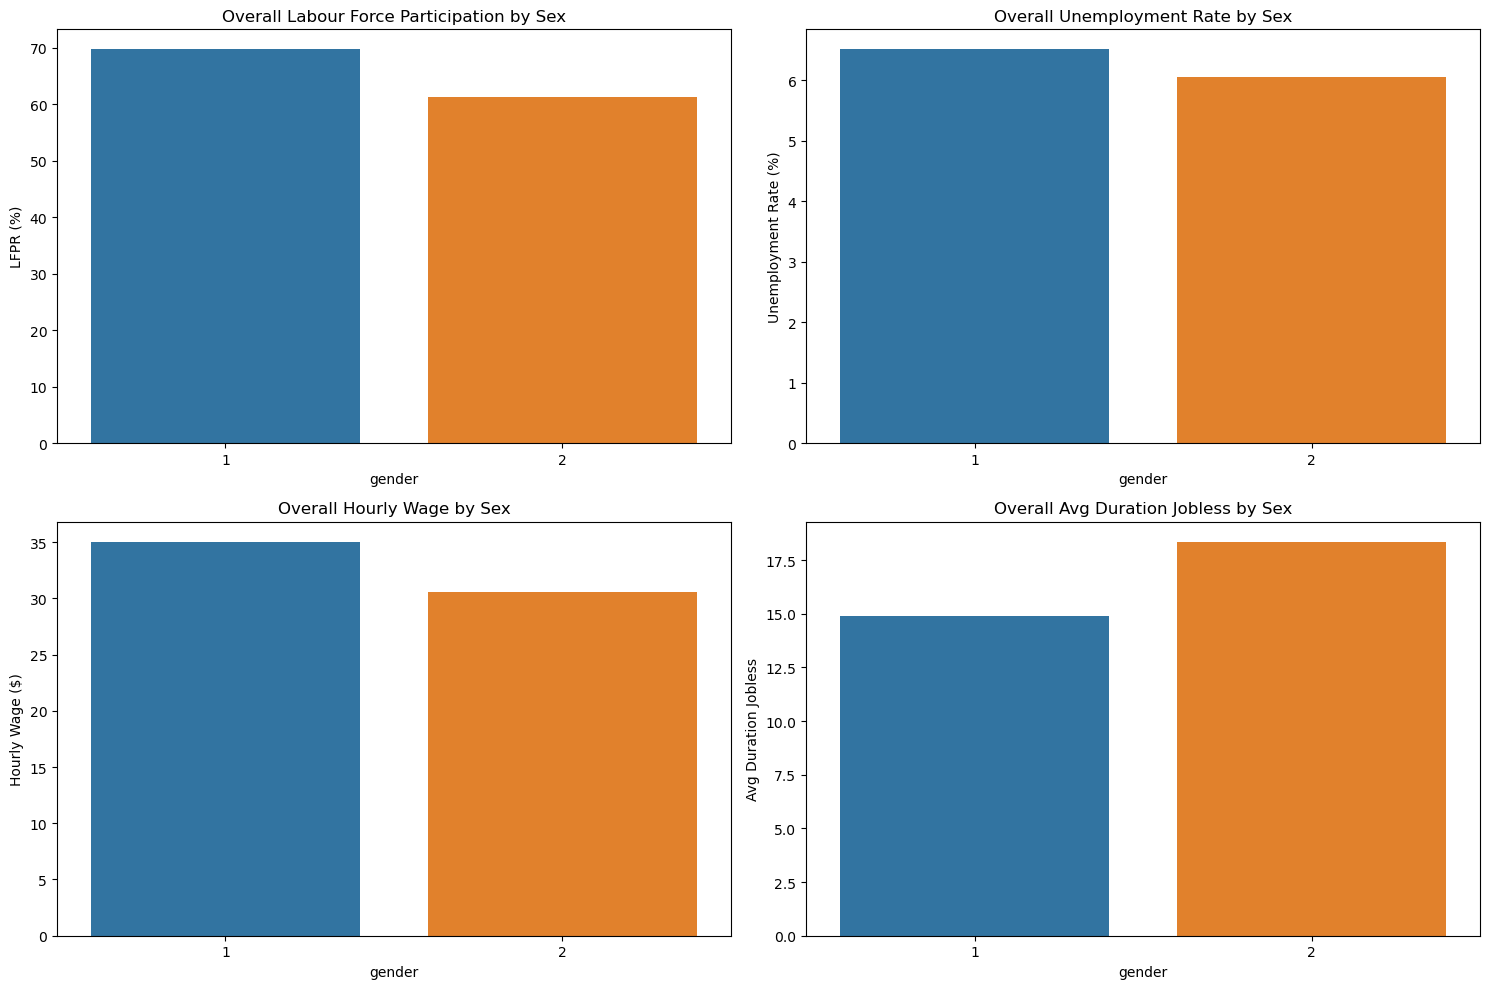

In [48]:
monthly_rates_by_gender, overall_rates_by_gender = calculate_labour_market_indicators(LFS, 'gender')

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Overall Labour Force Participation Rate by Sex
sns.barplot(data=overall_rates_by_gender, x='gender', y='overall_LFPR_rate', hue='gender', ax=axes[0,0], dodge=False)
axes[0,0].set_title('Overall Labour Force Participation by Sex')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].legend_.remove()

# Plot 2: Overall Unemployment Rate by Sex
sns.barplot(data=overall_rates_by_gender, x='gender', y='overall_unemployment_rate', hue='gender', ax=axes[0,1], dodge=False)
axes[0,1].set_title('Overall Unemployment Rate by Sex')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].legend_.remove()

# Plot 3: Overall Hourly Wage by Sex
sns.barplot(data=overall_rates_by_gender, x='gender', y='overall_avg_hourly_wage', hue='gender', ax=axes[1,0], dodge=False)
axes[1,0].set_title('Overall Hourly Wage by Sex')
axes[1,0].set_ylabel('Hourly Wage ($)')
axes[1,0].legend_.remove()

# Plot 4: Overall Average Duration Jobless by Sex
sns.barplot(data=overall_rates_by_gender, x='gender', y='overall_avg_duration_jobless', hue='gender', ax=axes[1,1], dodge=False)
axes[1,1].set_title('Overall Avg Duration Jobless by Sex')
axes[1,1].set_ylabel('Avg Duration Jobless')
axes[1,1].legend_.remove()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

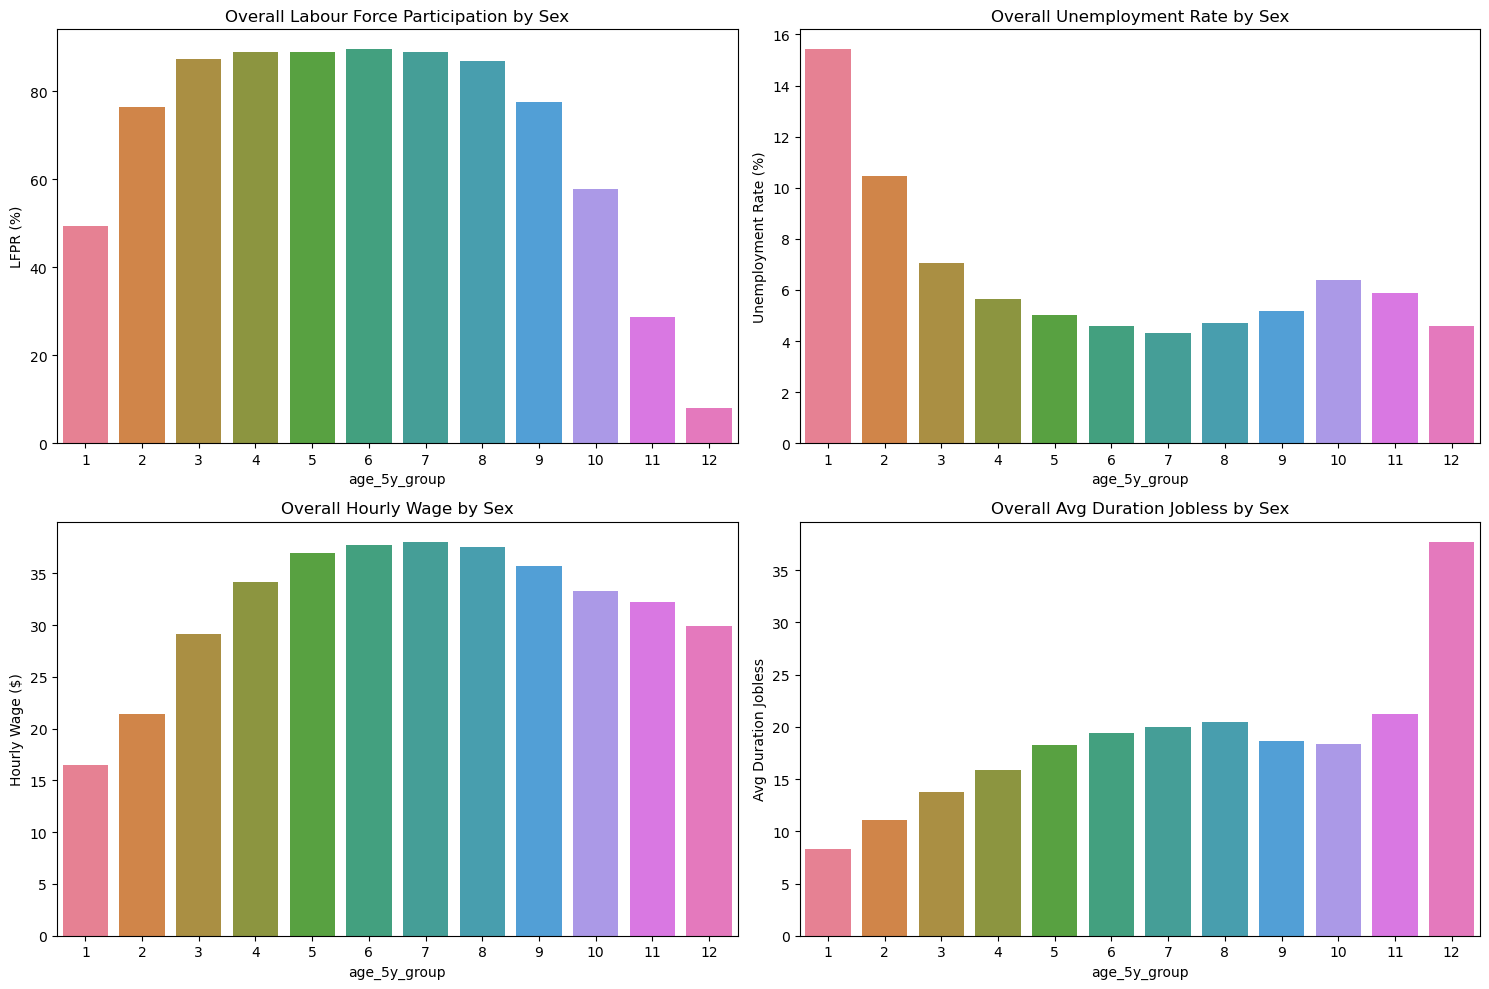

In [49]:
monthly_rates_by_age, overall_rates_by_age = calculate_labour_market_indicators(LFS, 'age_5y_group')
# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Overall Labour Force Participation Rate by Sex
sns.barplot(data=overall_rates_by_age, x='age_5y_group', y='overall_LFPR_rate', hue='age_5y_group', ax=axes[0,0], dodge=False)
axes[0,0].set_title('Overall Labour Force Participation by Sex')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].legend_.remove()

# Plot 2: Overall Unemployment Rate by Sex
sns.barplot(data=overall_rates_by_age, x='age_5y_group', y='overall_unemployment_rate', hue='age_5y_group', ax=axes[0,1], dodge=False)
axes[0,1].set_title('Overall Unemployment Rate by Sex')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].legend_.remove()

# Plot 3: Overall Hourly Wage by Sex
sns.barplot(data=overall_rates_by_age, x='age_5y_group', y='overall_avg_hourly_wage', hue='age_5y_group', ax=axes[1,0], dodge=False)
axes[1,0].set_title('Overall Hourly Wage by Sex')
axes[1,0].set_ylabel('Hourly Wage ($)')
axes[1,0].legend_.remove()

# Plot 4: Overall Average Duration Jobless by Sex
sns.barplot(data=overall_rates_by_age, x='age_5y_group', y='overall_avg_duration_jobless', hue='age_5y_group', ax=axes[1,1], dodge=False)
axes[1,1].set_title('Overall Avg Duration Jobless by Sex')
axes[1,1].set_ylabel('Avg Duration Jobless')
axes[1,1].legend_.remove()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

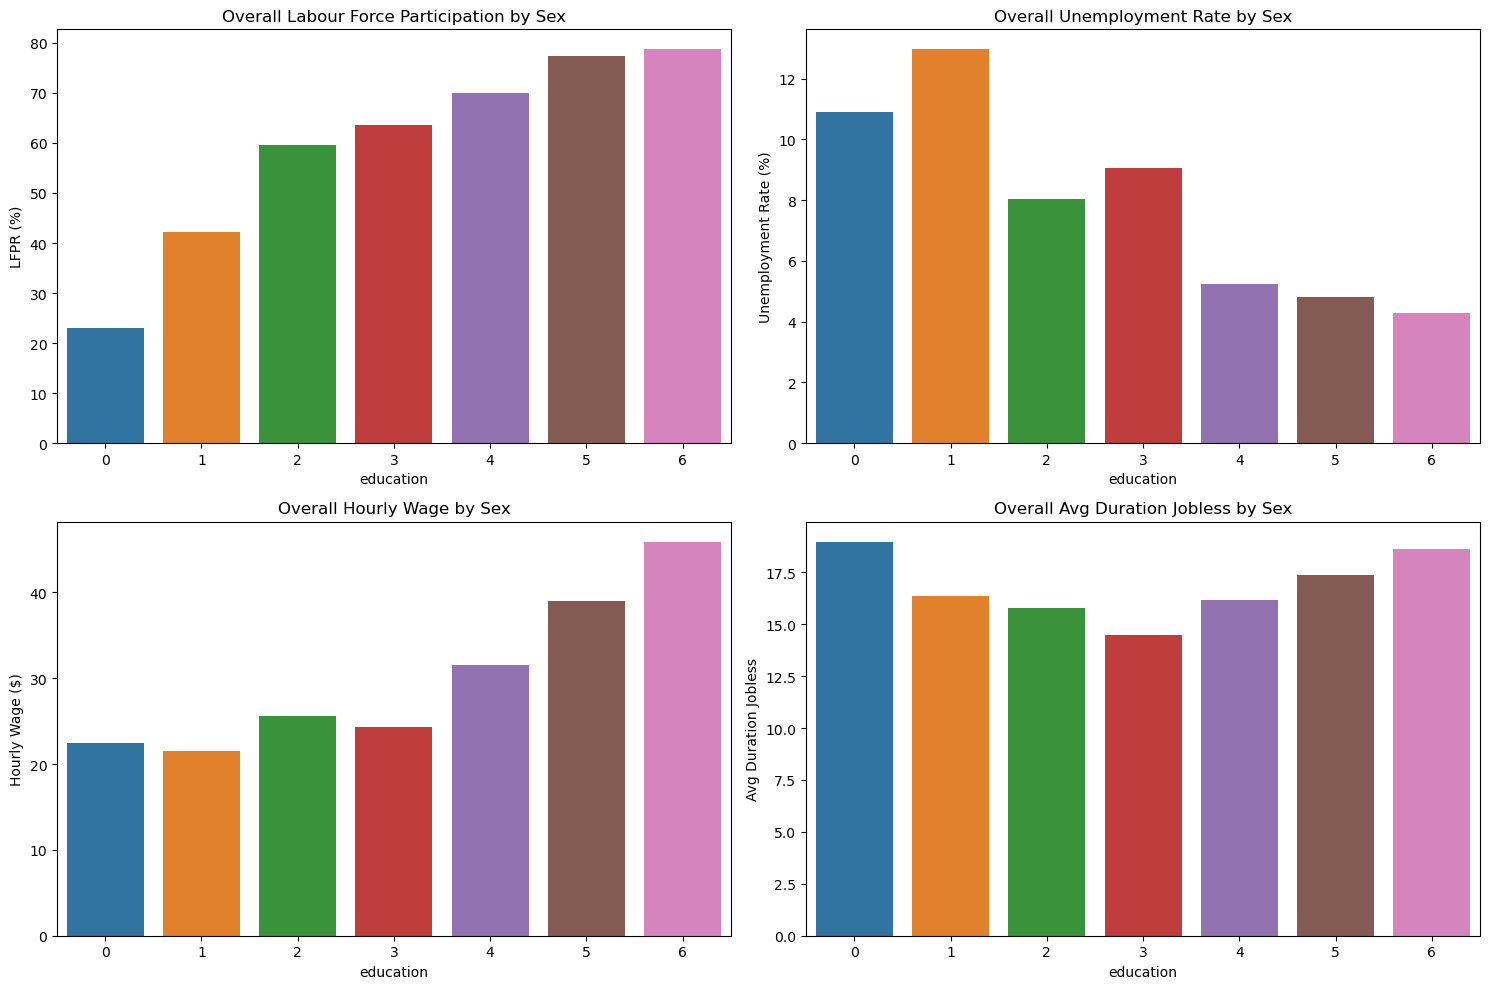

In [50]:
monthly_rates_by_education, overall_rates_by_education = calculate_labour_market_indicators(LFS, 'education')
# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Overall Labour Force Participation Rate by Sex
sns.barplot(data=overall_rates_by_education, x='education', y='overall_LFPR_rate', hue='education', ax=axes[0,0], dodge=False)
axes[0,0].set_title('Overall Labour Force Participation by Sex')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].legend_.remove()

# Plot 2: Overall Unemployment Rate by Sex
sns.barplot(data=overall_rates_by_education, x='education', y='overall_unemployment_rate', hue='education', ax=axes[0,1], dodge=False)
axes[0,1].set_title('Overall Unemployment Rate by Sex')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].legend_.remove()

# Plot 3: Overall Hourly Wage by Sex
sns.barplot(data=overall_rates_by_education, x='education', y='overall_avg_hourly_wage', hue='education', ax=axes[1,0], dodge=False)
axes[1,0].set_title('Overall Hourly Wage by Sex')
axes[1,0].set_ylabel('Hourly Wage ($)')
axes[1,0].legend_.remove()

# Plot 4: Overall Average Duration Jobless by Sex
sns.barplot(data=overall_rates_by_education, x='education', y='overall_avg_duration_jobless', hue='education', ax=axes[1,1], dodge=False)
axes[1,1].set_title('Overall Avg Duration Jobless by Sex')
axes[1,1].set_ylabel('Avg Duration Jobless')
axes[1,1].legend_.remove()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

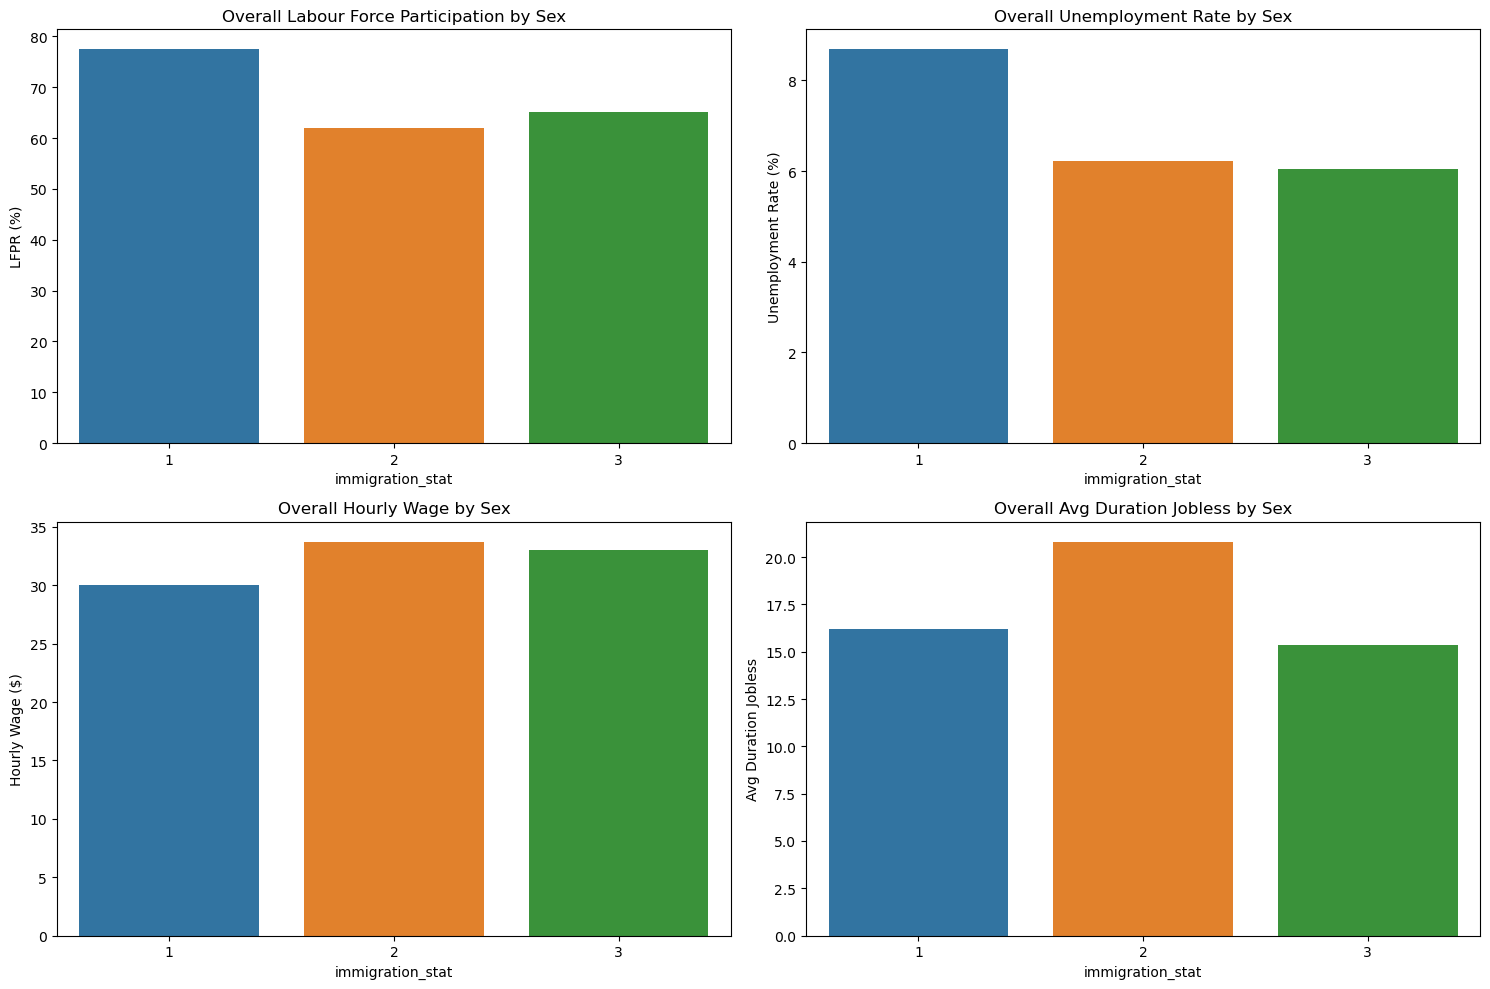

In [51]:
monthly_rates_by_immigration, overall_rates_by_immigration = calculate_labour_market_indicators(LFS, 'immigration_stat')
# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Overall Labour Force Participation Rate by Sex
sns.barplot(data=overall_rates_by_immigration, x='immigration_stat', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0,0], dodge=False)
axes[0,0].set_title('Overall Labour Force Participation by Sex')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].legend_.remove()

# Plot 2: Overall Unemployment Rate by Sex
sns.barplot(data=overall_rates_by_immigration, x='immigration_stat', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[0,1], dodge=False)
axes[0,1].set_title('Overall Unemployment Rate by Sex')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].legend_.remove()

# Plot 3: Overall Hourly Wage by Sex
sns.barplot(data=overall_rates_by_immigration, x='immigration_stat', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[1,0], dodge=False)
axes[1,0].set_title('Overall Hourly Wage by Sex')
axes[1,0].set_ylabel('Hourly Wage ($)')
axes[1,0].legend_.remove()

# Plot 4: Overall Average Duration Jobless by Sex
sns.barplot(data=overall_rates_by_immigration, x='immigration_stat', y='overall_avg_duration_jobless', hue='immigration_stat', ax=axes[1,1], dodge=False)
axes[1,1].set_title('Overall Avg Duration Jobless by Sex')
axes[1,1].set_ylabel('Avg Duration Jobless')
axes[1,1].legend_.remove()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

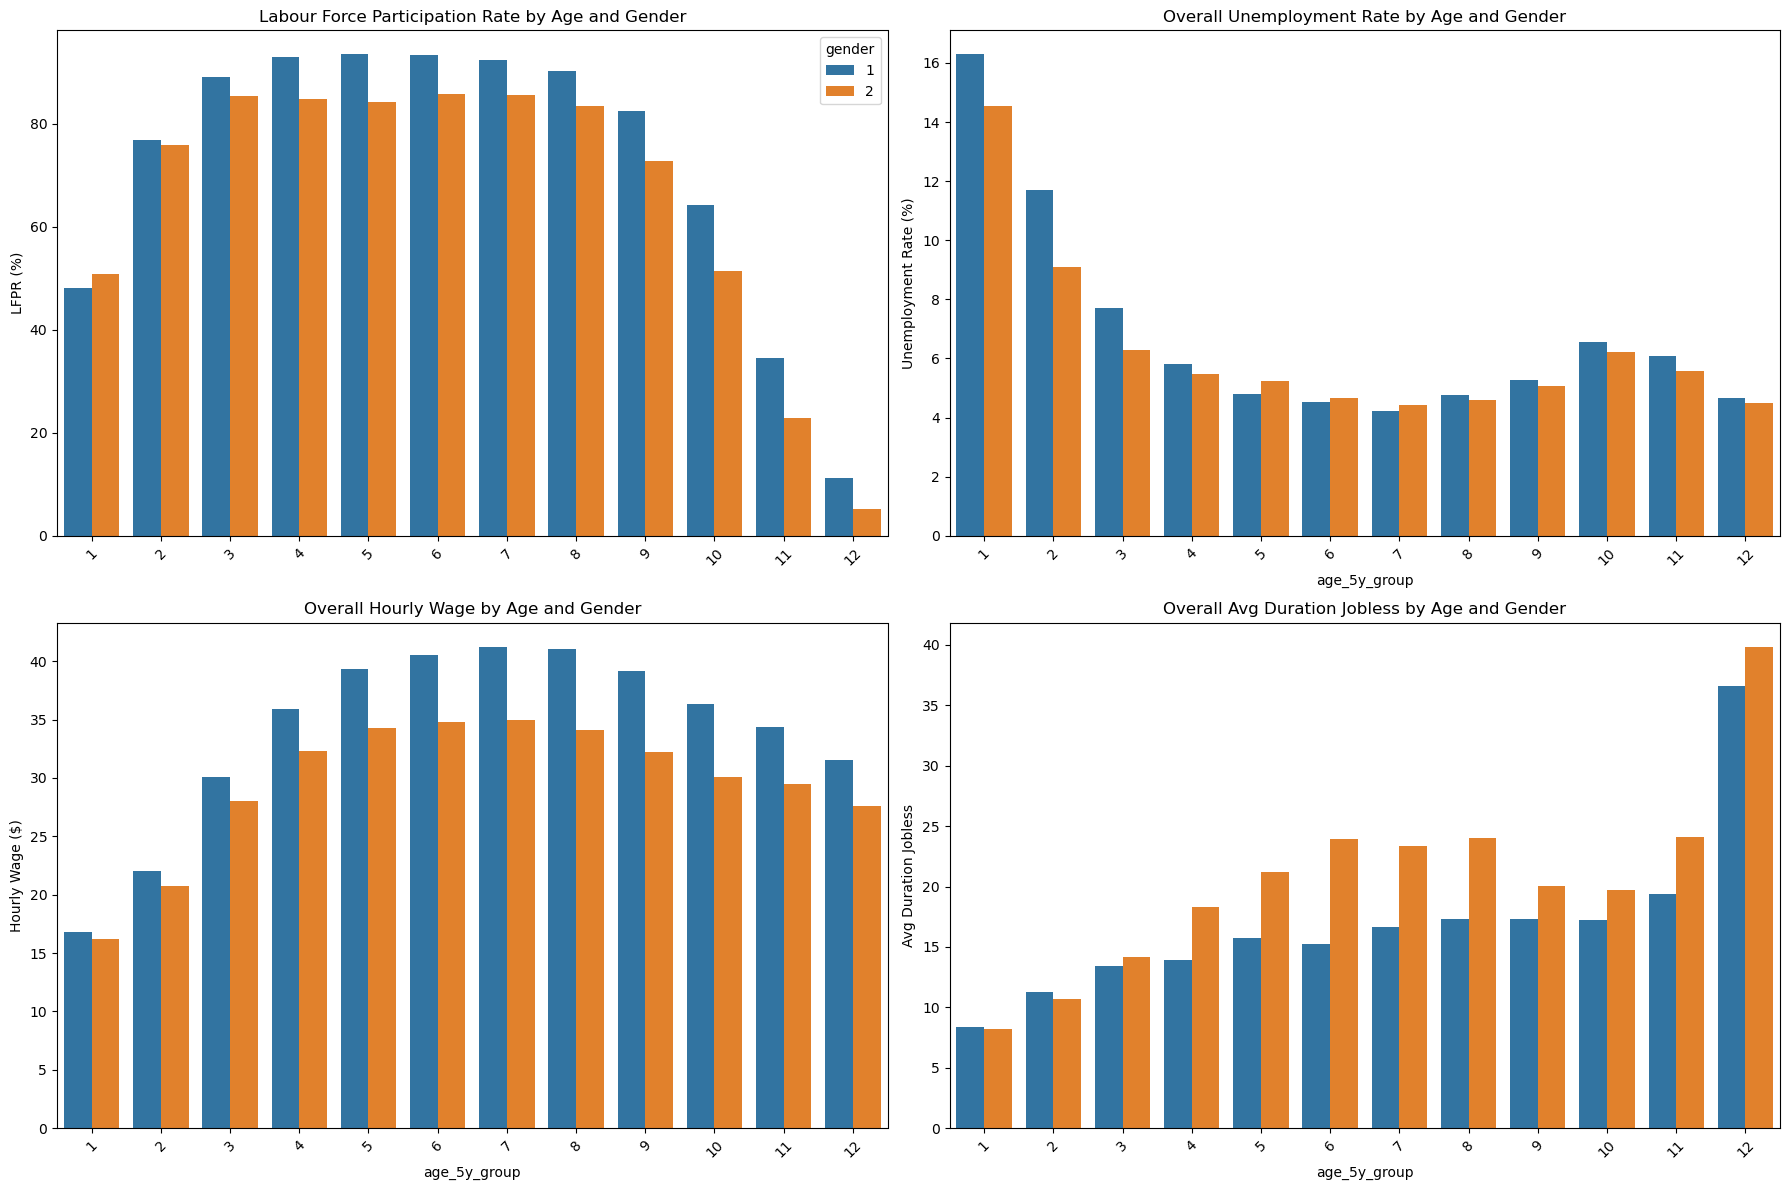

In [52]:
# Calculation LFPR and Unemployment based on age and gender
monthly_age_sex_df, overall_age_sex_df = calculate_labour_market_indicators_two_categories(LFS, 'age_5y_group', 'gender')

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Labour Force Participation Rate by Age and Gender
sns.barplot(data=overall_age_sex_df, x='age_5y_group', y='overall_LFPR_rate', hue='gender', ax=axes[0, 0])
axes[0, 0].set_title('Labour Force Participation Rate by Age and Gender')
axes[0, 0].set_ylabel('LFPR (%)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Overall Unemployment Rate by Age and Gender
sns.barplot(data=overall_age_sex_df, x='age_5y_group', y='overall_unemployment_rate', hue='gender', ax=axes[0, 1])
axes[0, 1].set_title('Overall Unemployment Rate by Age and Gender')
axes[0, 1].set_ylabel('Unemployment Rate (%)')
axes[0, 1].legend_.remove()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Overall Hourly Wage by Age and Gender
sns.barplot(data=overall_age_sex_df, x='age_5y_group', y='overall_avg_hourly_wage', hue='gender', ax=axes[1, 0])
axes[1, 0].set_title('Overall Hourly Wage by Age and Gender')
axes[1, 0].set_ylabel('Hourly Wage ($)')
axes[1, 0].legend_.remove()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Overall Average Duration Jobless by Age and Gender
sns.barplot(data=overall_age_sex_df, x='age_5y_group', y='overall_avg_duration_jobless', hue='gender', ax=axes[1, 1])
axes[1, 1].set_title('Overall Avg Duration Jobless by Age and Gender')
axes[1, 1].set_ylabel('Avg Duration Jobless')
axes[1, 1].legend_.remove()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



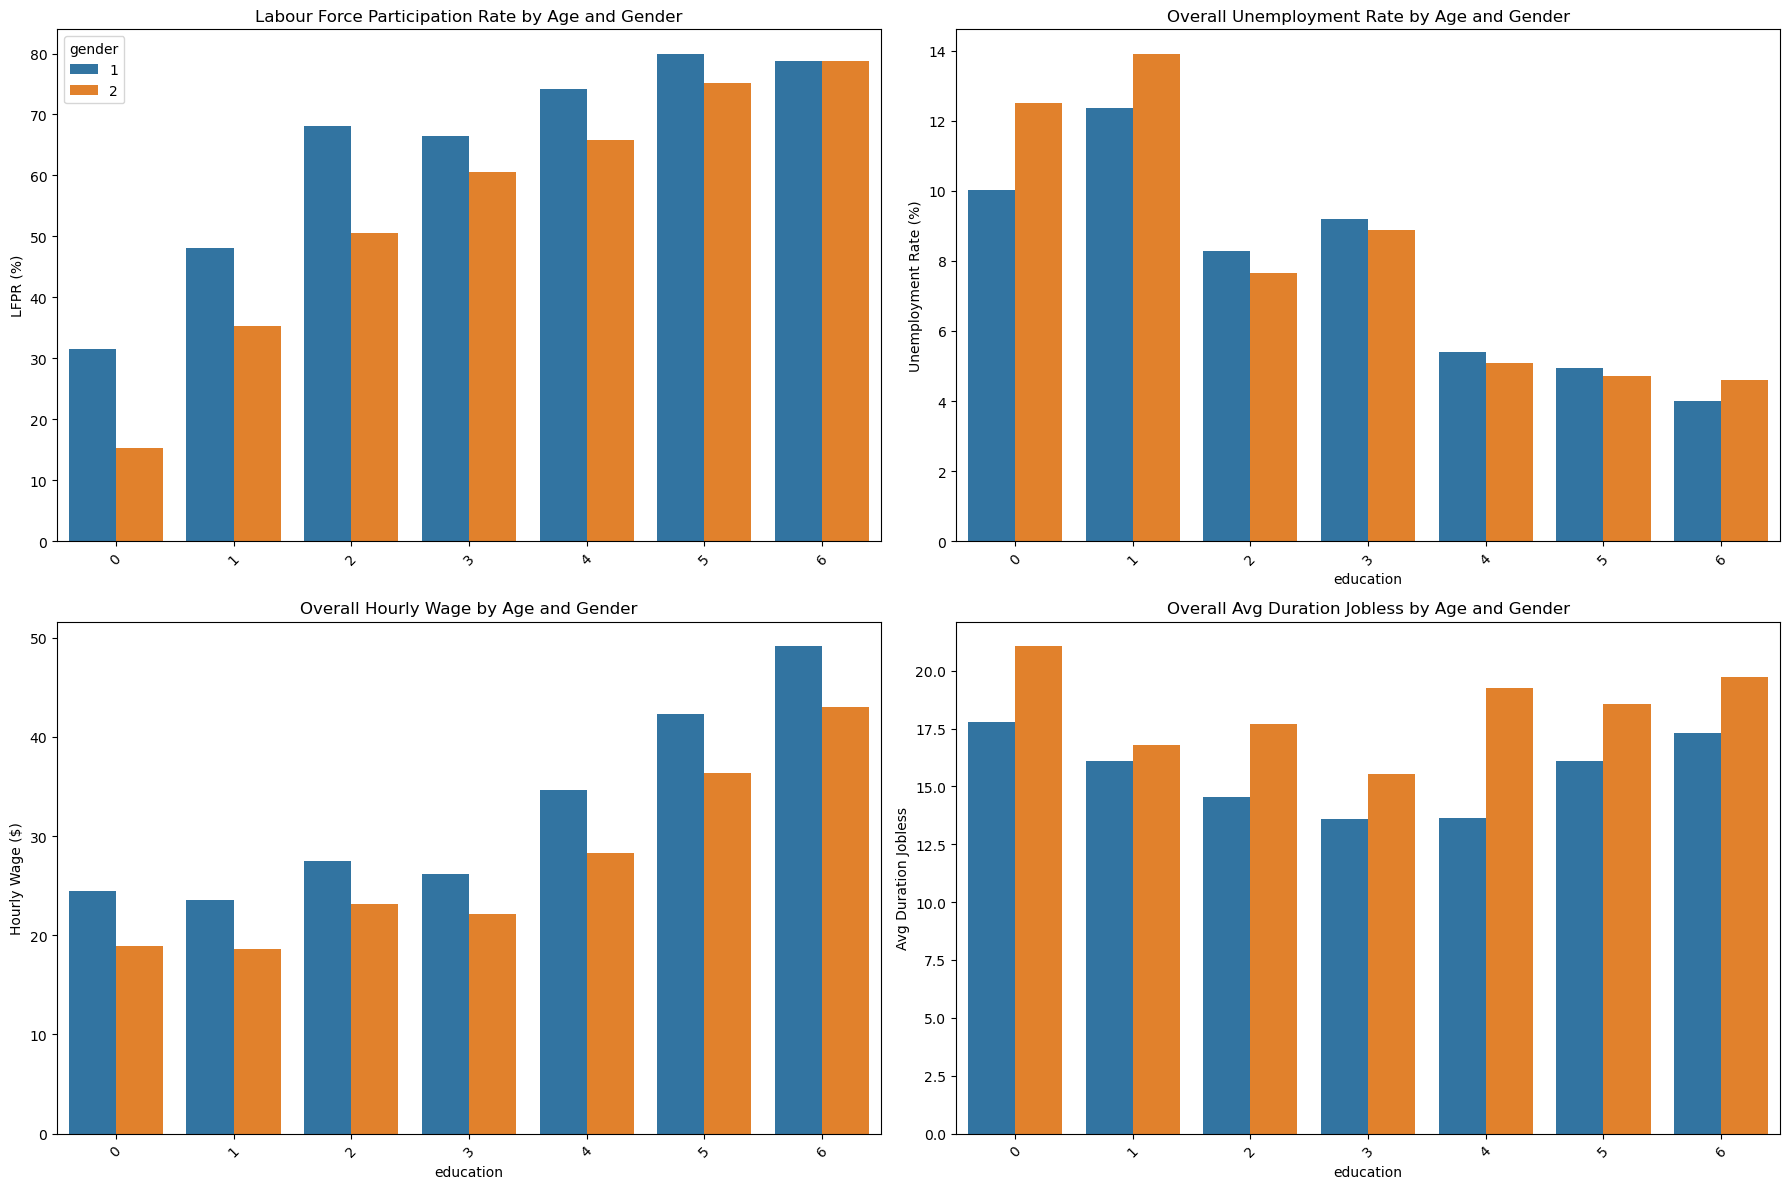

In [53]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_education_sex_df, overall_education_sex_df = calculate_labour_market_indicators_two_categories(LFS, 'education', 'gender')


import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Labour Force Participation Rate by Age and Gender
sns.barplot(data=overall_education_sex_df, x='education', y='overall_LFPR_rate', hue='gender', ax=axes[0, 0])
axes[0, 0].set_title('Labour Force Participation Rate by Age and Gender')
axes[0, 0].set_ylabel('LFPR (%)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Overall Unemployment Rate by Age and Gender
sns.barplot(data=overall_education_sex_df, x='education', y='overall_unemployment_rate', hue='gender', ax=axes[0, 1])
axes[0, 1].set_title('Overall Unemployment Rate by Age and Gender')
axes[0, 1].set_ylabel('Unemployment Rate (%)')
axes[0, 1].legend_.remove()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Overall Hourly Wage by Age and Gender
sns.barplot(data=overall_education_sex_df, x='education', y='overall_avg_hourly_wage', hue='gender', ax=axes[1, 0])
axes[1, 0].set_title('Overall Hourly Wage by Age and Gender')
axes[1, 0].set_ylabel('Hourly Wage ($)')
axes[1, 0].legend_.remove()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Overall Average Duration Jobless by Age and Gender
sns.barplot(data=overall_education_sex_df, x='education', y='overall_avg_duration_jobless', hue='gender', ax=axes[1, 1])
axes[1, 1].set_title('Overall Avg Duration Jobless by Age and Gender')
axes[1, 1].set_ylabel('Avg Duration Jobless')
axes[1, 1].legend_.remove()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




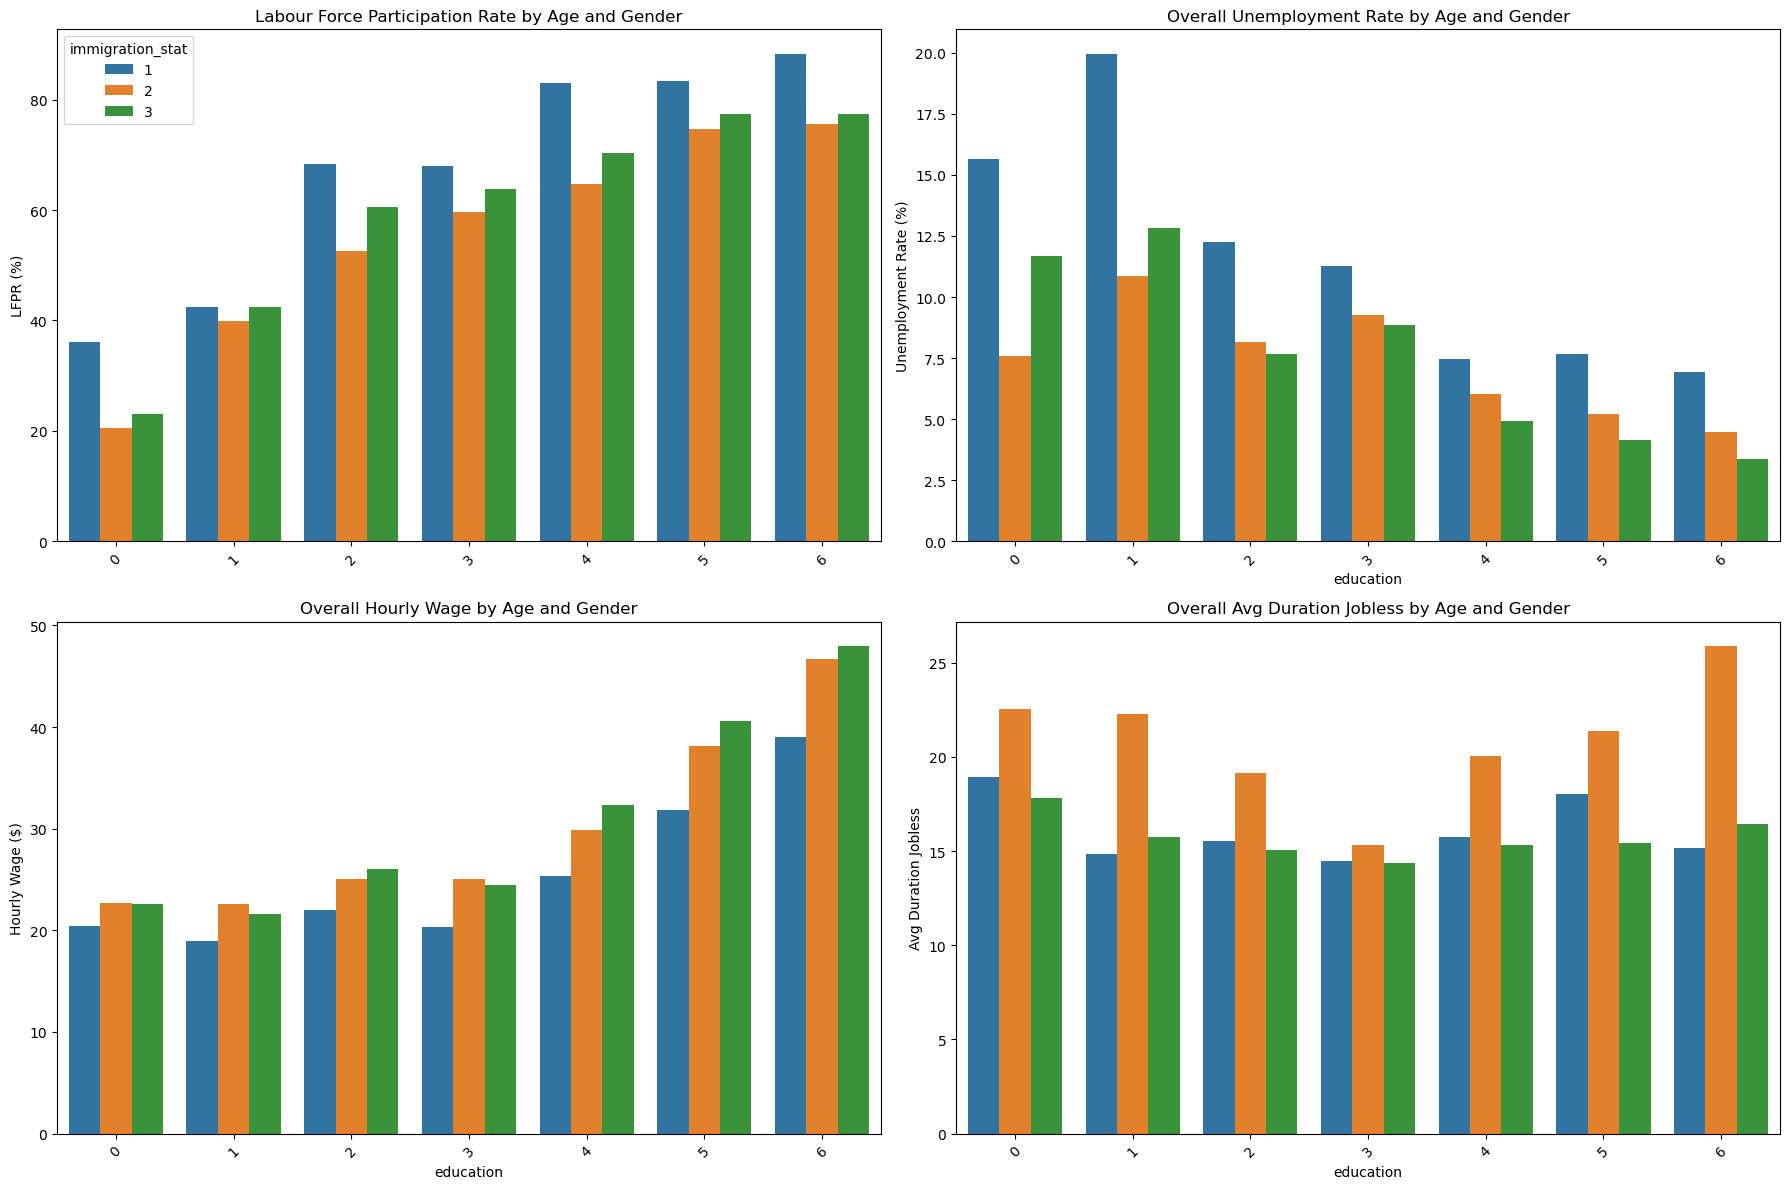

In [54]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_education_immigration_df, overall_education_immigration_df = calculate_labour_market_indicators_two_categories(LFS, 'education', 'immigration_stat')

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Labour Force Participation Rate by Age and Gender
sns.barplot(data=overall_education_immigration_df, x='education', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0, 0])
axes[0, 0].set_title('Labour Force Participation Rate by Age and Gender')
axes[0, 0].set_ylabel('LFPR (%)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Overall Unemployment Rate by Age and Gender
sns.barplot(data=overall_education_immigration_df, x='education', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[0, 1])
axes[0, 1].set_title('Overall Unemployment Rate by Age and Gender')
axes[0, 1].set_ylabel('Unemployment Rate (%)')
axes[0, 1].legend_.remove()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Overall Hourly Wage by Age and Gender
sns.barplot(data=overall_education_immigration_df, x='education', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[1, 0])
axes[1, 0].set_title('Overall Hourly Wage by Age and Gender')
axes[1, 0].set_ylabel('Hourly Wage ($)')
axes[1, 0].legend_.remove()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Overall Average Duration Jobless by Age and Gender
sns.barplot(data=overall_education_immigration_df, x='education', y='overall_avg_duration_jobless', hue='immigration_stat', ax=axes[1, 1])
axes[1, 1].set_title('Overall Avg Duration Jobless by Age and Gender')
axes[1, 1].set_ylabel('Avg Duration Jobless')
axes[1, 1].legend_.remove()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


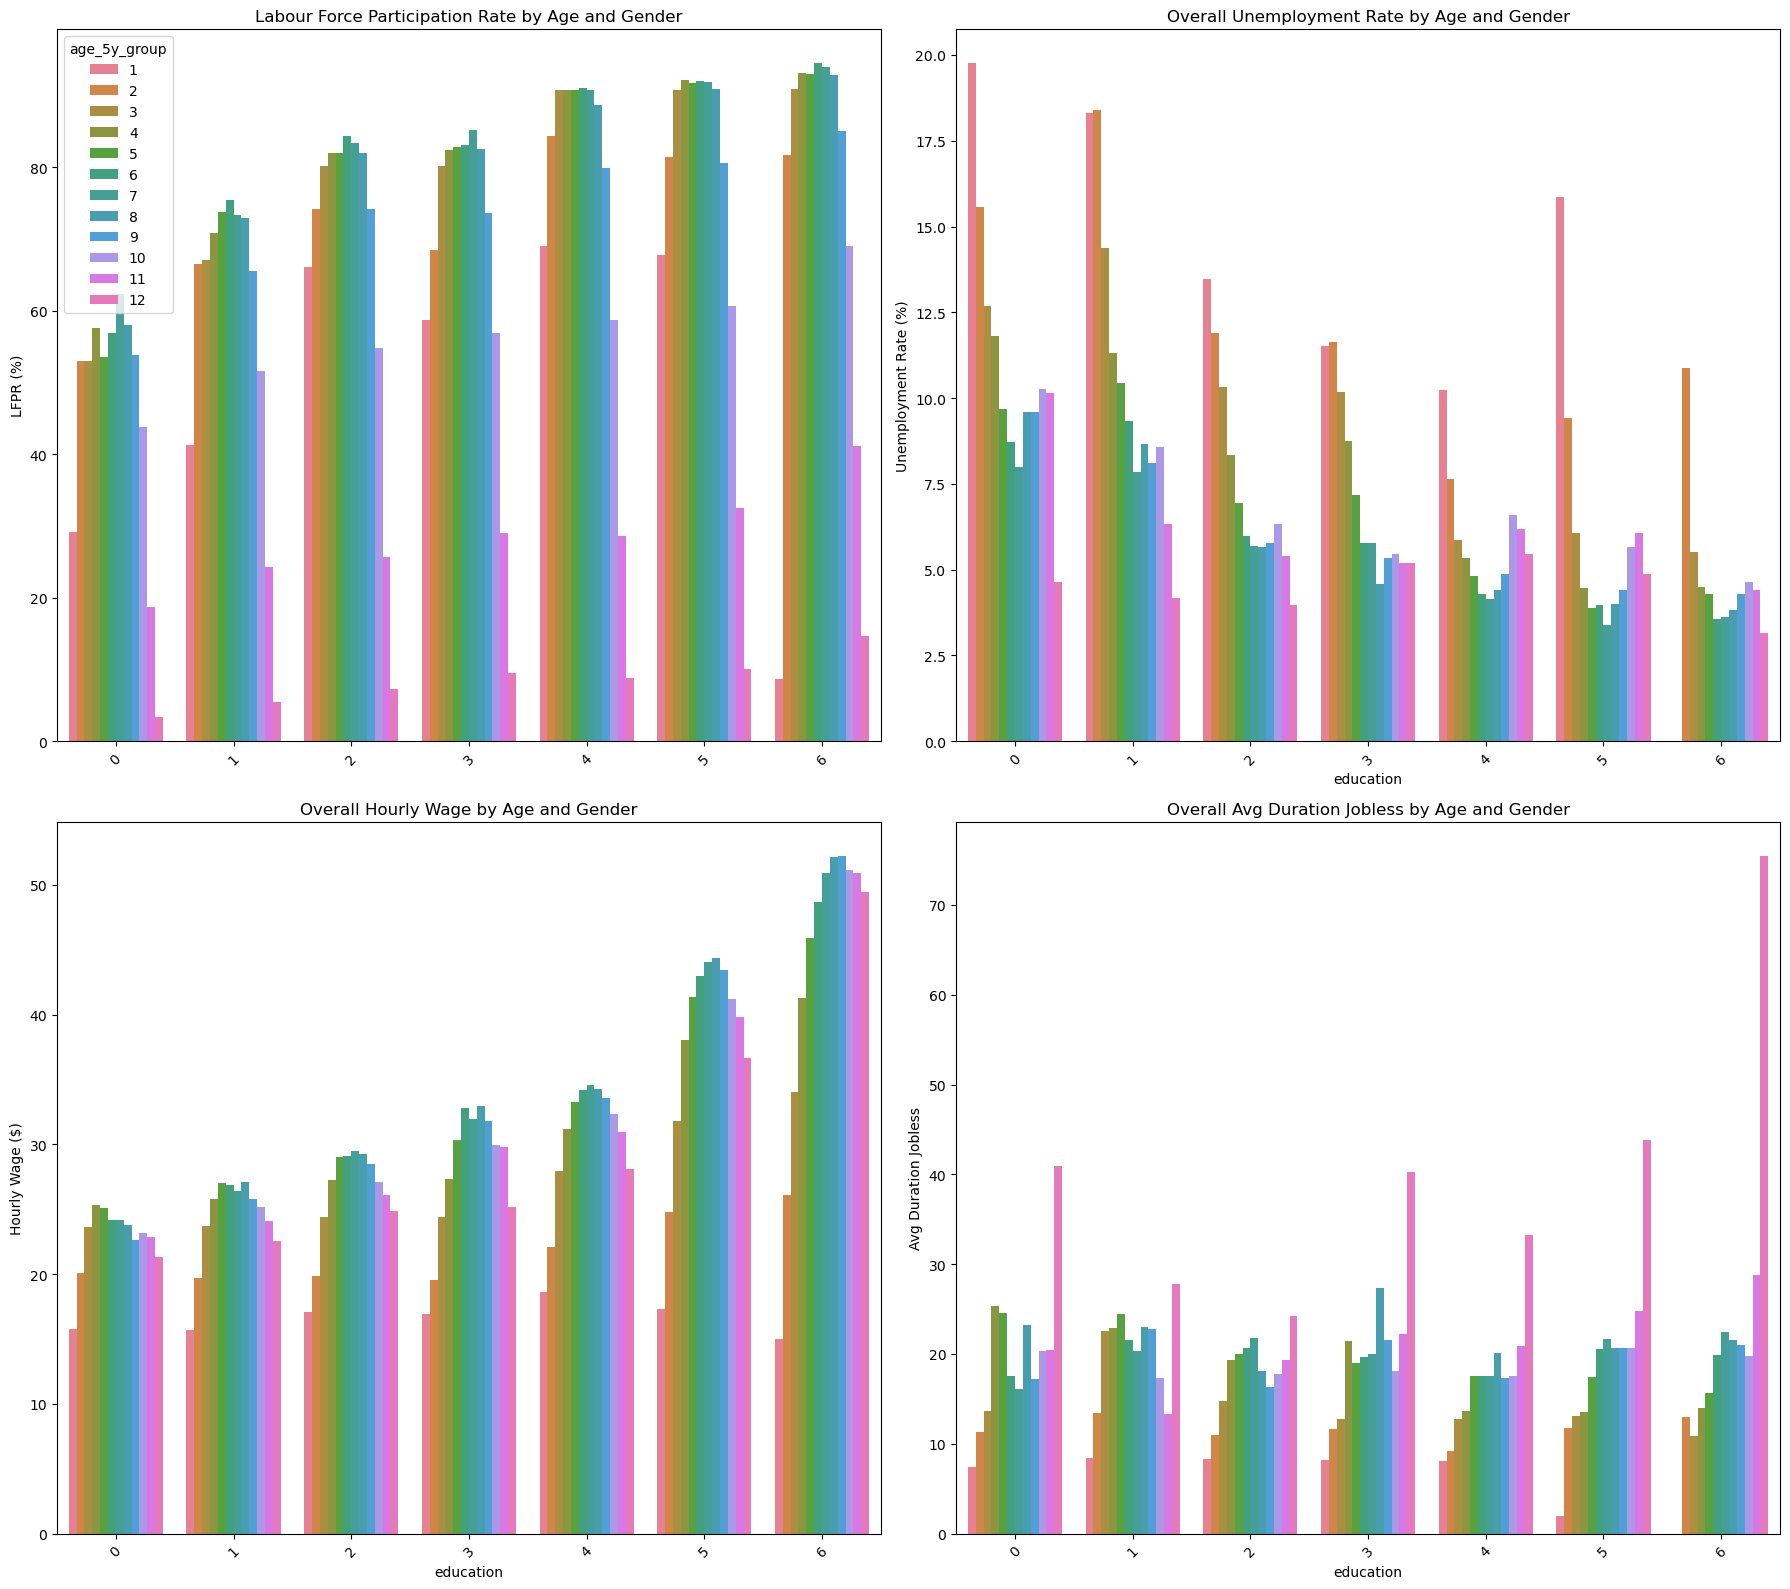

In [55]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_education_age_df, overall_education_age_df = calculate_labour_market_indicators_two_categories(LFS, 'education', 'age_5y_group')

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Plot 1: Labour Force Participation Rate by Age and Gender
sns.barplot(data=overall_education_age_df, x='education', y='overall_LFPR_rate', hue='age_5y_group', ax=axes[0, 0])
axes[0, 0].set_title('Labour Force Participation Rate by Age and Gender')
axes[0, 0].set_ylabel('LFPR (%)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Overall Unemployment Rate by Age and Gender
sns.barplot(data=overall_education_age_df, x='education', y='overall_unemployment_rate', hue='age_5y_group', ax=axes[0, 1])
axes[0, 1].set_title('Overall Unemployment Rate by Age and Gender')
axes[0, 1].set_ylabel('Unemployment Rate (%)')
axes[0, 1].legend_.remove()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Overall Hourly Wage by Age and Gender
sns.barplot(data=overall_education_age_df, x='education', y='overall_avg_hourly_wage', hue='age_5y_group', ax=axes[1, 0])
axes[1, 0].set_title('Overall Hourly Wage by Age and Gender')
axes[1, 0].set_ylabel('Hourly Wage ($)')
axes[1, 0].legend_.remove()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Overall Average Duration Jobless by Age and Gender
sns.barplot(data=overall_education_age_df, x='education', y='overall_avg_duration_jobless', hue='age_5y_group', ax=axes[1, 1])
axes[1, 1].set_title('Overall Avg Duration Jobless by Age and Gender')
axes[1, 1].set_ylabel('Avg Duration Jobless')
axes[1, 1].legend_.remove()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


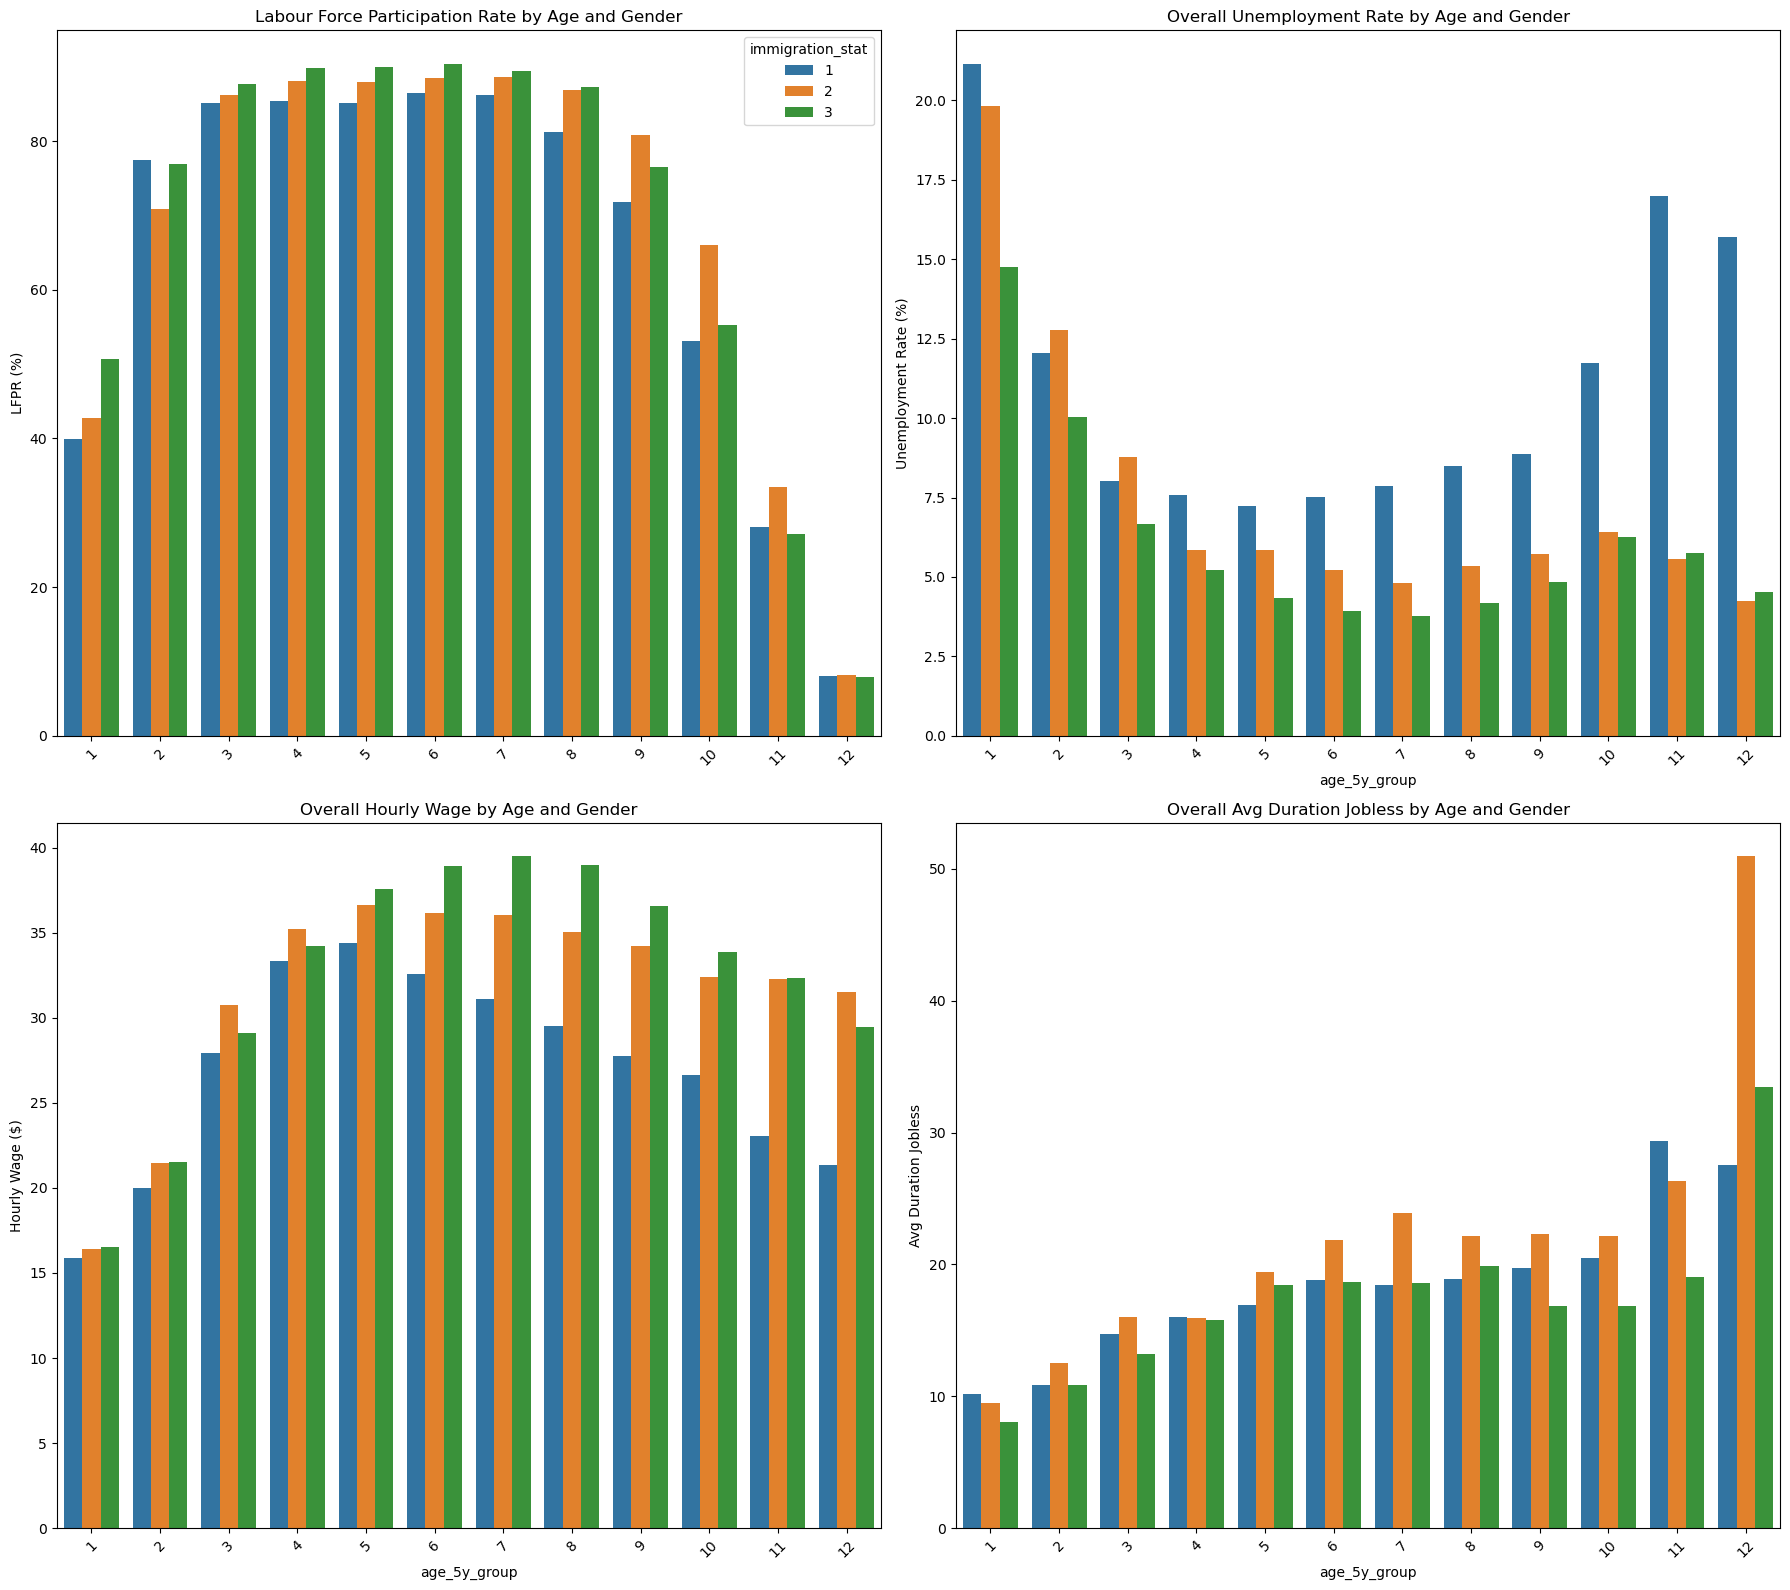

In [56]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_age_immigration_df, overall_age_immigration_df = calculate_labour_market_indicators_two_categories(LFS, 'age_5y_group', 'immigration_stat')

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Plot 1: Labour Force Participation Rate by Age and Gender
sns.barplot(data=overall_age_immigration_df, x='age_5y_group', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0, 0])
axes[0, 0].set_title('Labour Force Participation Rate by Age and Gender')
axes[0, 0].set_ylabel('LFPR (%)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Overall Unemployment Rate by Age and Gender
sns.barplot(data=overall_age_immigration_df, x='age_5y_group', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[0, 1])
axes[0, 1].set_title('Overall Unemployment Rate by Age and Gender')
axes[0, 1].set_ylabel('Unemployment Rate (%)')
axes[0, 1].legend_.remove()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Overall Hourly Wage by Age and Gender
sns.barplot(data=overall_age_immigration_df, x='age_5y_group', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[1, 0])
axes[1, 0].set_title('Overall Hourly Wage by Age and Gender')
axes[1, 0].set_ylabel('Hourly Wage ($)')
axes[1, 0].legend_.remove()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Overall Average Duration Jobless by Age and Gender
sns.barplot(data=overall_age_immigration_df, x='age_5y_group', y='overall_avg_duration_jobless', hue='immigration_stat', ax=axes[1, 1])
axes[1, 1].set_title('Overall Avg Duration Jobless by Age and Gender')
axes[1, 1].set_ylabel('Avg Duration Jobless')
axes[1, 1].legend_.remove()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


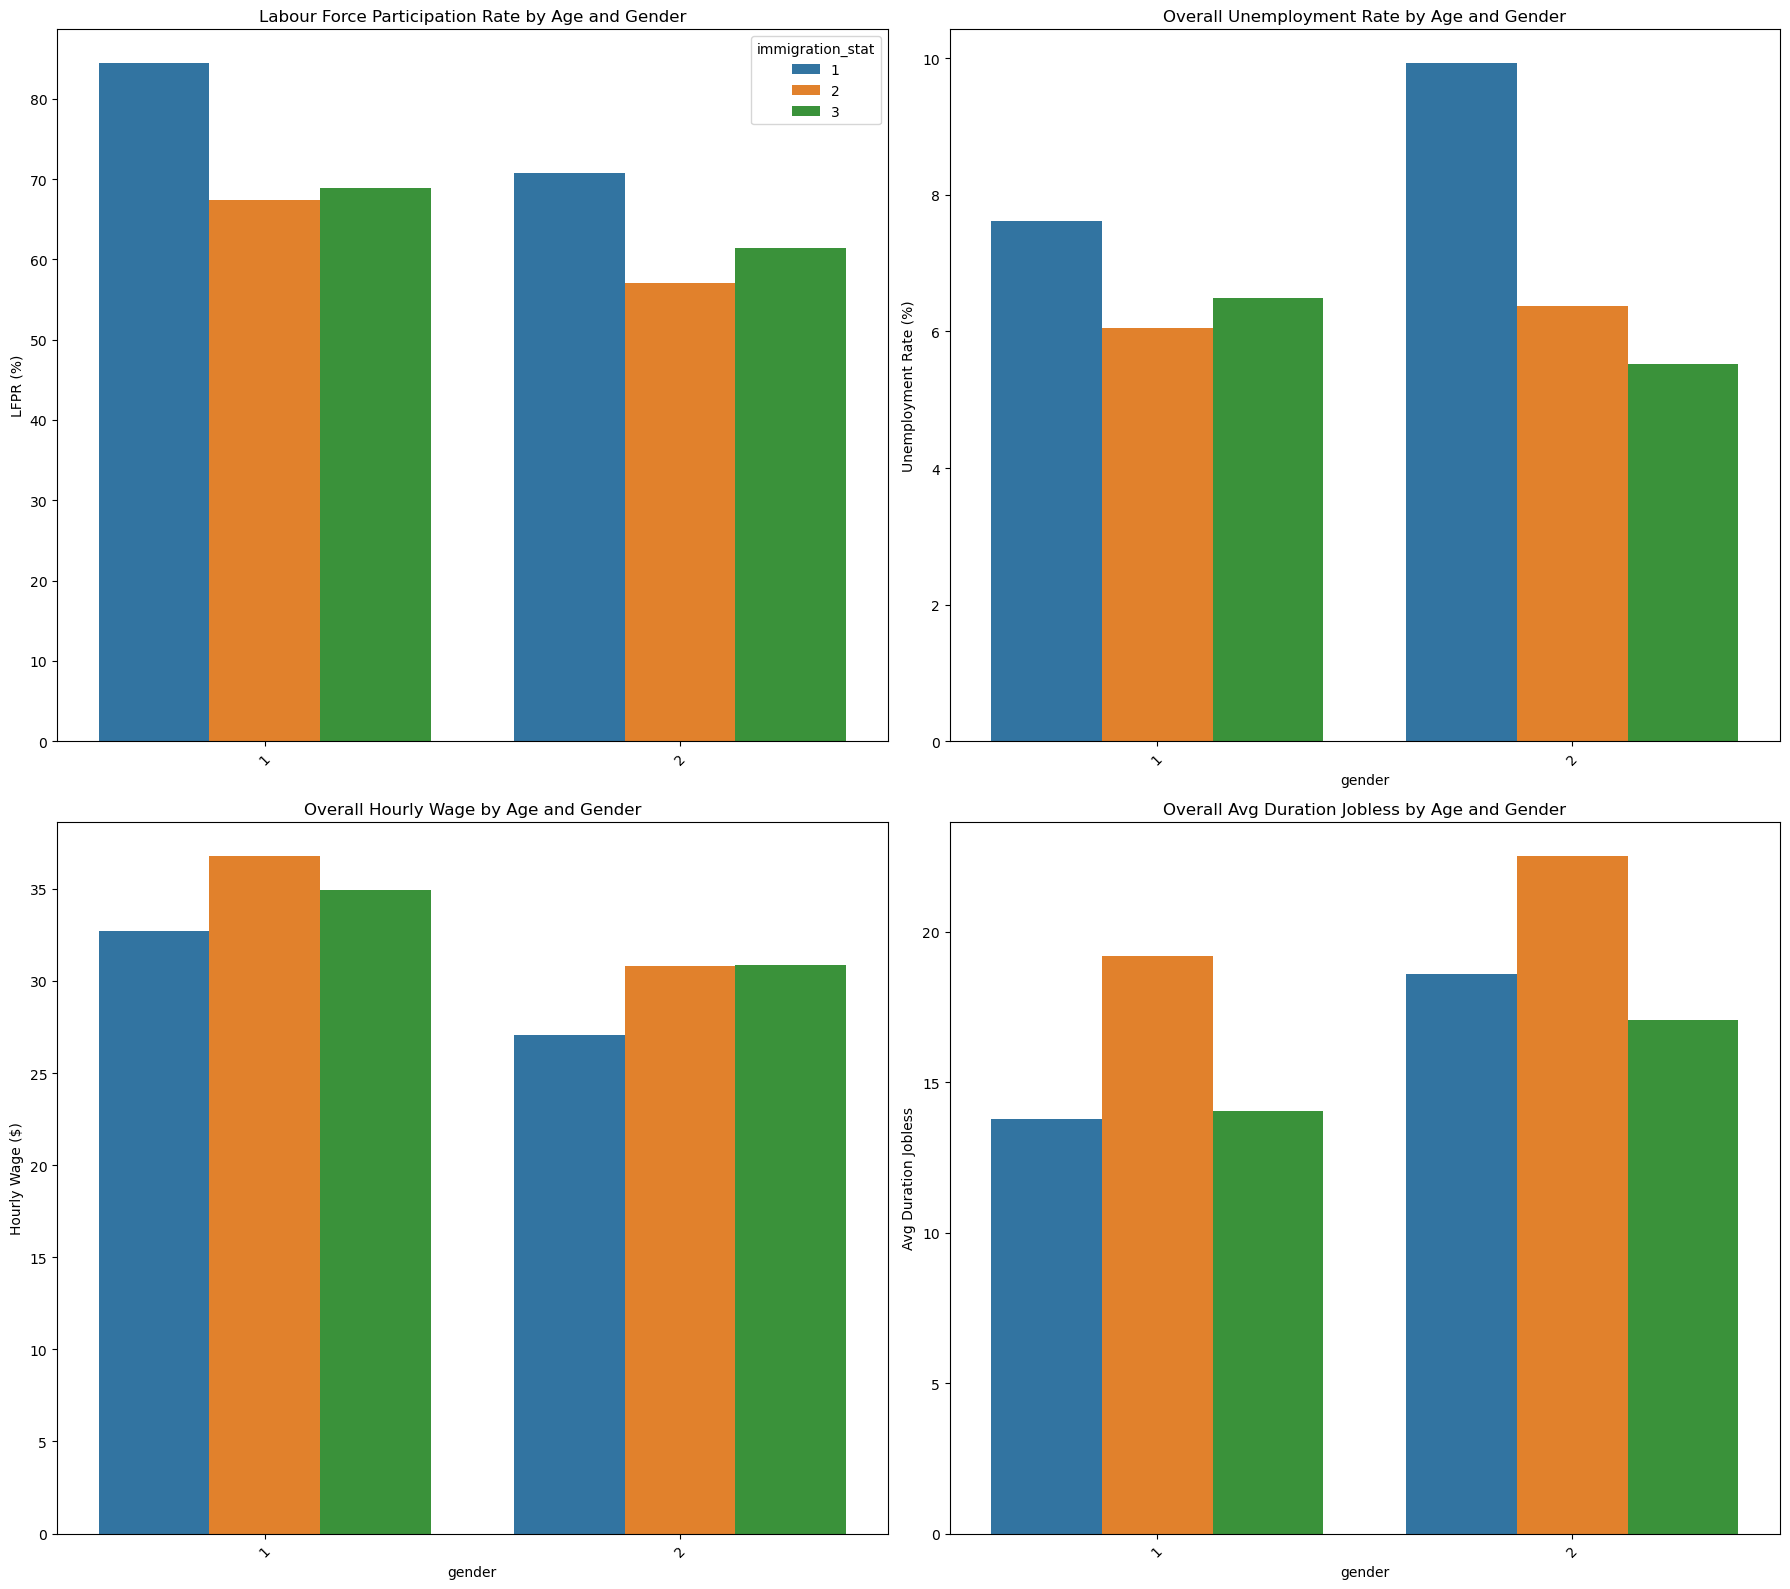

In [57]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_gender_immigration_df, overall_gender_immigration_df = calculate_labour_market_indicators_two_categories(LFS, 'gender', 'immigration_stat')

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Plot 1: Labour Force Participation Rate by Age and Gender
sns.barplot(data=overall_gender_immigration_df, x='gender', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0, 0])
axes[0, 0].set_title('Labour Force Participation Rate by Age and Gender')
axes[0, 0].set_ylabel('LFPR (%)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Overall Unemployment Rate by Age and Gender
sns.barplot(data=overall_gender_immigration_df, x='gender', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[0, 1])
axes[0, 1].set_title('Overall Unemployment Rate by Age and Gender')
axes[0, 1].set_ylabel('Unemployment Rate (%)')
axes[0, 1].legend_.remove()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Overall Hourly Wage by Age and Gender
sns.barplot(data=overall_gender_immigration_df, x='gender', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[1, 0])
axes[1, 0].set_title('Overall Hourly Wage by Age and Gender')
axes[1, 0].set_ylabel('Hourly Wage ($)')
axes[1, 0].legend_.remove()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Overall Average Duration Jobless by Age and Gender
sns.barplot(data=overall_gender_immigration_df, x='gender', y='overall_avg_duration_jobless', hue='immigration_stat', ax=axes[1, 1])
axes[1, 1].set_title('Overall Avg Duration Jobless by Age and Gender')
axes[1, 1].set_ylabel('Avg Duration Jobless')
axes[1, 1].legend_.remove()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## What are the dynamic relationships between inflation, job vacancy rate, unemployment rate, employment rate, and labour force participation rates?

In [59]:
overall_indicators.set_index('REF_DATE', inplace=True)
overall_indicators.sort_index(inplace=True)
overall_indicators.head()

,Employment_Rate(%),Unemployment_Rate(%),Labour_Force_Participation_Rate(%),Average_Hourly_Wage,Duration_Jobless(Months),Job Vacancies (#),Payroll Employees (#),Job Vacancy Rate (%),Month,Year,All-items,Inflation_Rate_MoM,CPI_Lagged_1M,Inflation_Rate_1M_Lagged,CPI_Lagged_12M,Inflation_Rate_YoY,Market_Tightness,Lagged_1M_Job_Vacancy_Rate,Lagged_1M_Unemployment_Rate
REF_DATE,,,,,,,,,,,,,,,,,,,
2021-01-01,57.793,9.841,64.101,30.752,11.519,561280.000,15294425.000,3.500,NaT,2021,139.100,0.433,138.500,0.433,137.500,1.164,0.285,3.600,8.188
2021-02-01,58.838,8.792,64.510,30.639,13.636,616555.000,15167450.000,3.900,NaT,2021,139.400,0.216,139.100,0.216,137.700,1.235,0.348,3.500,9.841
2021-03-01,59.615,8.205,64.944,30.484,13.550,643655.000,15233105.000,4.100,NaT,2021,139.500,0.072,139.400,0.072,136.300,2.348,0.387,3.900,8.792
2021-04-01,59.234,8.455,64.705,30.742,13.077,651890.000,15431950.000,4.100,NaT,2021,139.900,0.287,139.500,0.287,135.600,3.171,0.381,4.100,8.205
2021-05-01,60.141,8.392,65.650,30.549,14.394,673585.000,15556570.000,4.200,NaT,2021,140.300,0.286,139.900,0.286,135.400,3.619,0.391,4.100,8.455


In [60]:
overall_indicators.columns

Index(['Employment_Rate(%)', 'Unemployment_Rate(%)', 'Labour_Force_Participation_Rate(%)', 'Average_Hourly_Wage', 'Duration_Jobless(Months)', 'Job Vacancies (#)', 'Payroll Employees (#)', 'Job Vacancy Rate (%)', 'Month', 'Year', 'All-items', 'Inflation_Rate_MoM', 'CPI_Lagged_1M', 'Inflation_Rate_1M_Lagged', 'CPI_Lagged_12M', 'Inflation_Rate_YoY', 'Market_Tightness', 'Lagged_1M_Job_Vacancy_Rate', 'Lagged_1M_Unemployment_Rate'], dtype='object')

In [63]:
# First, select the variables of interest:
variables = ['Employment_Rate(%)', 'Unemployment_Rate(%)', 'Labour_Force_Participation_Rate(%)', 
            'Average_Hourly_Wage', 'Inflation_Rate_YoY', 'Job Vacancy Rate (%)']

df_var = overall_indicators[variables].dropna()  # Ensure there are no missing values

# Check for stationarity using ADF tests
for col in df_var.columns:
    result = adfuller(df_var[col], regression='c')
    print(f"ADF for {col}: p-value = {result[1]:.4f}")

# Differencing non-stationary variables
diff_variables = ['Average_Hourly_Wage', 'Inflation_Rate_YoY' , 'Job Vacancy Rate (%)', 'Unemployment_Rate(%)']

df_var_diff = df_var[diff_variables].diff().dropna()

# Check again for stationarity using ADF tests
for col in df_var_diff.columns:
    result = adfuller(df_var_diff[col], regression='c')
    print(f"ADF for first-differenced {col}: p-value = {result[1]:.4f}")

ADF for Employment_Rate(%): p-value = 0.0030
ADF for Unemployment_Rate(%): p-value = 0.2660
ADF for Labour_Force_Participation_Rate(%): p-value = 0.0455
ADF for Average_Hourly_Wage: p-value = 0.9960
ADF for Inflation_Rate_YoY: p-value = 0.5195
ADF for Job Vacancy Rate (%): p-value = 0.0840
ADF for first-differenced Average_Hourly_Wage: p-value = 0.0005
ADF for first-differenced Inflation_Rate_YoY: p-value = 0.0001
ADF for first-differenced Job Vacancy Rate (%): p-value = 0.0000
ADF for first-differenced Unemployment_Rate(%): p-value = 0.0096


In [64]:
# Variables that are non-stationary in levels I(0):
coint_vars = ['Average_Hourly_Wage', 'Inflation_Rate_YoY' ,'Unemployment_Rate(%)', 'Job Vacancy Rate (%)']
df_coint = df_var[coint_vars]

# Run Johansen cointegration test
johansen_test = coint_johansen(df_coint, det_order=0, k_ar_diff=1)
print("Johansen test eigenvalue statistics:", johansen_test.lr1)
print("Critical values (90%, 95%, 99%):", johansen_test.cvt)

Johansen test eigenvalue statistics: [52.06696966 18.41643148  8.3046683   0.24592855]
Critical values (90%, 95%, 99%): [[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [65]:
# Choose lag length (k_ar_diff) by comparing information criteria manually
vecm_model = VECM(df_coint, k_ar_diff=6, coint_rank=1)
vecm_results = vecm_model.fit()
print(vecm_results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Average_Hourly_Wage
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
L1.Average_Hourly_Wage      0.0386      0.128      0.301      0.763      -0.212       0.290
L1.Inflation_Rate_YoY       0.0373      0.045      0.833      0.405      -0.050       0.125
L1.Unemployment_Rate(%)     0.1774      0.056      3.143      0.002       0.067       0.288
L1.Job Vacancy Rate (%)     0.4509      0.153      2.947      0.003       0.151       0.751
L2.Average_Hourly_Wage     -0.1006      0.129     -0.780      0.435      -0.353       0.152
L2.Inflation_Rate_YoY      -0.0450      0.045     -1.008      0.314      -0.132       0.043
L2.Unemployment_Rate(%)     0.2205      0.067      3.311      0.001       0.090       0.351
L2.Job Vacancy Rate (%)     0.0041      0.127      0.032      0.975      

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


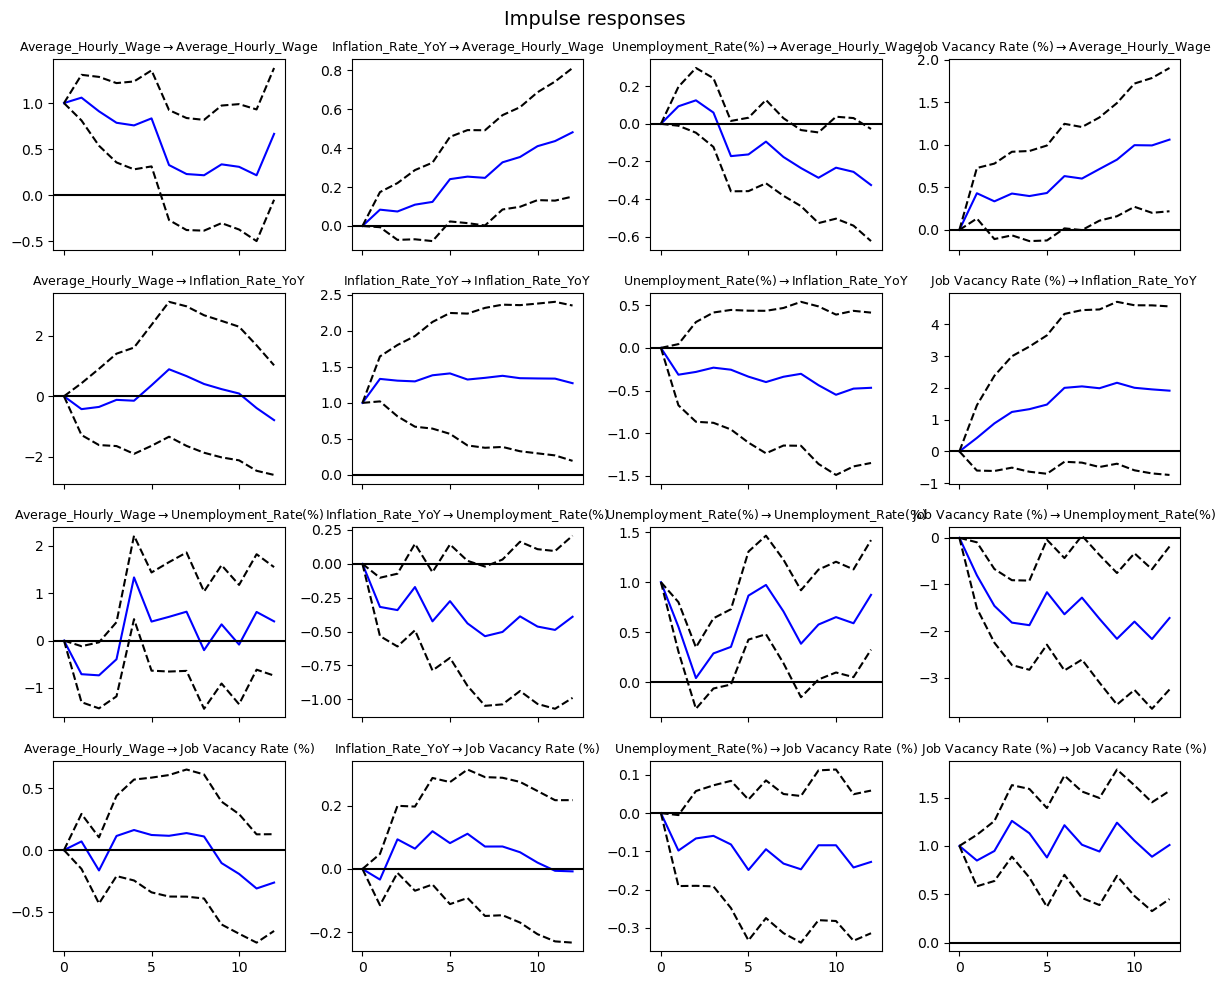

In [ ]:
irf = vecm_results.irf(12)
fig = irf.plot(
    orth=False,
    figsize=(12, 10),
    subplot_params={"fontsize": 9}
)
plt.tight_layout()
plt.show()


In [66]:
# Accessing residuals from the VECM results
resid = vecm_results.resid 

# Test each residual series for autocorrelation and print results as a DataFrame
for i, col_name in enumerate(vecm_results.model.endog_names):
    lb_results = acorr_ljungbox(resid[:, i], lags=[12], return_df=True)
    print(f"\nResidual autocorrelation test for {col_name}:")
    print(lb_results)


Residual autocorrelation test for Average_Hourly_Wage:
    lb_stat  lb_pvalue
12   11.518      0.485

Residual autocorrelation test for Inflation_Rate_YoY:
    lb_stat  lb_pvalue
12   14.798      0.253

Residual autocorrelation test for Unemployment_Rate(%):
    lb_stat  lb_pvalue
12   15.176      0.232

Residual autocorrelation test for Job Vacancy Rate (%):
    lb_stat  lb_pvalue
12    4.312      0.977


In [67]:
# Accessing residuals from the VECM results
resid = vecm_results.resid  
endog_names = vecm_results.model.endog_names

# Test each residual series for normality using Jarque-Bera test
print("Jarque-Bera Test for Residual Normality:")
for i, name in enumerate(endog_names):
    jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(resid[:, i])
    print(f"{name}: JB stat = {jb_stat:.4f}, p-value = {jb_pvalue:.4f}, skew = {skew:.4f}, kurtosis = {kurtosis:.4f}")


Jarque-Bera Test for Residual Normality:
Average_Hourly_Wage: JB stat = 3.0948, p-value = 0.2128, skew = -0.6726, kurtosis = 2.9534
Inflation_Rate_YoY: JB stat = 5.5561, p-value = 0.0622, skew = -0.0241, kurtosis = 4.8028
Unemployment_Rate(%): JB stat = 1.4920, p-value = 0.4743, skew = -0.2340, kurtosis = 2.1912
Job Vacancy Rate (%): JB stat = 1.7174, p-value = 0.4237, skew = -0.1458, kurtosis = 2.0407


In [68]:
# Forecasting 2 months ahead
n_forecast = 2
forecast = vecm_results.predict(steps=n_forecast)

# Create forecast DataFrame
forecast_index = pd.date_range(start=df_coint.index[-1] + pd.DateOffset(months=1), periods=n_forecast, freq='MS')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=df_coint.columns)
forecast_df.drop(columns='Job Vacancy Rate (%)', inplace=True)

print("\nForecast for Jan and Feb 2025:")
print(forecast_df)


Forecast for Jan and Feb 2025:
            Average_Hourly_Wage  Inflation_Rate_YoY  Unemployment_Rate(%)
2025-01-01               36.113               1.911                 6.893
2025-02-01               36.106               2.164                 6.713



Comparison:
                      Forecast                                                       Actual                                       
           Average_Hourly_Wage Inflation_Rate_YoY Unemployment_Rate(%) Unemployment_Rate(%) Average_Hourly_Wage Inflation_Rate_YoY
2025-01-01              36.113              1.911                6.893                7.050              35.995              2.008
2025-02-01              36.106              2.164                6.713                6.686              36.137              2.569


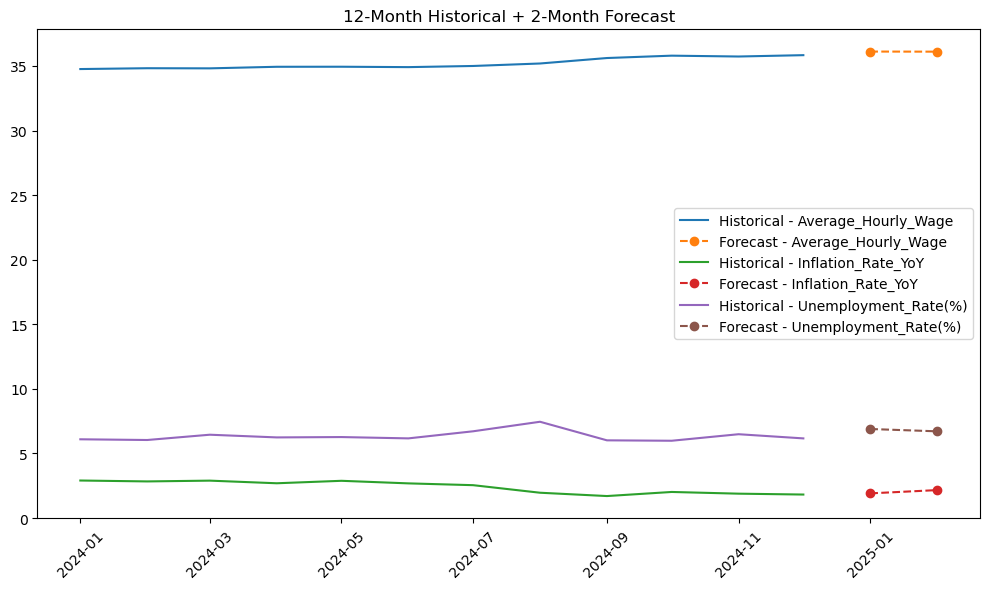

In [76]:
# Join for comparison
monthly_2025 = pd.read_csv('Data/2025 Monthly Labour Market Rates.csv')
monthly_2025['REF_DATE'] = pd.to_datetime(monthly_2025['REF_DATE'])
actual_2025 = monthly_2025[['REF_DATE', 'Unemployment_Rate(%)', 'Average_Hourly_Wage', 'Inflation_Rate_YoY']]
actual_2025.set_index('REF_DATE', inplace=True)

comparison = pd.concat([forecast_df, actual_2025], axis=1, keys=['Forecast', 'Actual'])
print("\nComparison:")
print(comparison)

plt.figure(figsize=(10, 6))
for col in forecast_df.columns:
    plt.plot(df_coint[col][-12:], label=f'Historical - {col}')
    plt.plot(forecast_df[col], '--o', label=f'Forecast - {col}')
plt.legend()
plt.title("12-Month Historical + 2-Month Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Key takeaway: The model performs very well on stable labour market indicators (wage & unemployment), but less so on inflation, which may require additional variables or model refinements.

## What factors best predict whether an industry’s unemployment rate will increase or decrease?

In [84]:
# Prepare data for modeling
df = industry_trends.sort_values(['NAICS_21_Label', 'REF_DATE']).reset_index(drop=True)
df['Unemp_change'] = df.groupby('NAICS_21_Label')['Unemployment_Rate(%)'].diff()
df['target'] = (df['Unemp_change'] > 0).astype(int)
df_model = df.dropna(subset=['Unemp_change']).copy()

predictors = [
    'Job Vacancies (#)', 'Payroll Employees (#)', 'Job Vacancy Rate (%)', 'Employment_Rate(%)', 
    'Unemployment_Rate(%)', 'Labour_Force_Participation_Rate(%)', 'Duration_Jobless(Months)', 
    'Average_Hourly_Wage', 'Market_Tightness', 'Lagged_Job_Vacancy_Rate', 'Lagged_Unemployment_Rate', 
    'Lagged_Market_Tightness', 'All-items', 'Inflation_Rate_MoM', 'CPI_Lagged_1M', 'Inflation_Rate_1M_Lagged', 
    'CPI_Lagged_12M', 'Inflation_Rate_YoY'
]

X = df_model[predictors]
y = df_model['target']


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# Baseline Models

print("\n--- Random Forest Baseline ---")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

print("\n--- XGBoost Baseline ---")
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))


--- Random Forest Baseline ---
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       156
           1       0.85      0.75      0.80       141

    accuracy                           0.82       297
   macro avg       0.83      0.82      0.82       297
weighted avg       0.82      0.82      0.82       297

Accuracy: 0.8215488215488216
ROC-AUC: 0.9112338607019458

--- XGBoost Baseline ---
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       156
           1       0.91      0.91      0.91       141

    accuracy                           0.91       297
   macro avg       0.91      0.91      0.91       297
weighted avg       0.91      0.91      0.91       297

Accuracy: 0.9124579124579124
ROC-AUC: 0.9688125113657029


In [85]:
# Initialize Random Forest and XGBoost
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Define thresholds and container for results
thresholds = np.linspace(0.01, 0.1, 10)
rf_results = []
xgb_results = []

# Feature importance
rf_importance_df = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
xgb_importance_df = pd.DataFrame({'feature': X.columns, 'importance': xgb.feature_importances_})

# Thresholding loop for both models
for model_name, importance_df in [('RF', rf_importance_df), ('XGB', xgb_importance_df)]:
    for thresh in thresholds:
        selected = importance_df[importance_df['importance'] > thresh]['feature'].tolist()
        if len(selected) == 0:
            continue
        X_train_thresh = X_train[selected]
        X_test_thresh = X_test[selected]

        model = XGBClassifier(random_state=42, eval_metric='logloss')
        model.fit(X_train_thresh, y_train)
        auc = roc_auc_score(y_test, model.predict_proba(X_test_thresh)[:, 1])
        acc = accuracy_score(y_test, model.predict(X_test_thresh))

        result = (thresh, len(selected), auc, acc)
        if model_name == 'RF':
            rf_results.append(result)
        else:
            xgb_results.append(result)

# Create DataFrames
rf_thresh_df = pd.DataFrame(rf_results, columns=['Threshold', 'n_features', 'ROC_AUC', 'Accuracy'])
xgb_thresh_df = pd.DataFrame(xgb_results, columns=['Threshold', 'n_features', 'ROC_AUC', 'Accuracy'])

# Select best threshold from each
best_rf_thresh = rf_thresh_df.loc[rf_thresh_df['ROC_AUC'].idxmax()]['Threshold']
best_xgb_thresh = xgb_thresh_df.loc[xgb_thresh_df['ROC_AUC'].idxmax()]['Threshold']

# Refined feature sets
rf_selected_features = rf_importance_df[rf_importance_df['importance'] > best_rf_thresh]['feature'].tolist()
xgb_selected_features = xgb_importance_df[xgb_importance_df['importance'] > best_xgb_thresh]['feature'].tolist()

# Prepare final refined datasets
X_train_rf = X_train[rf_selected_features]
X_test_rf_refined = X_test[rf_selected_features]
X_train_xgb = X_train[xgb_selected_features]
X_test_xgb_refined = X_test[xgb_selected_features]



# Refined Models

print("\n--- Random Forest Post Feature Importance ---")
rf_refined = RandomForestClassifier(random_state=42)
rf_refined.fit(X_train_rf, y_train)
y_pred_rf_refined = rf_refined.predict(X_test_rf_refined)
print(classification_report(y_test, y_pred_rf_refined))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_refined))
print("ROC-AUC:", roc_auc_score(y_test, rf_refined.predict_proba(X_test_rf_refined)[:,1]))

print("\n--- XGBoost Post Feature Importance ---")
xgb_refined = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_refined.fit(X_train_xgb, y_train)
y_pred_xgb_refined = xgb_refined.predict(X_test_xgb_refined)
print(classification_report(y_test, y_pred_xgb_refined))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_refined))
print("ROC-AUC:", roc_auc_score(y_test, xgb_refined.predict_proba(X_test_xgb_refined)[:,1]))


--- Random Forest Post Feature Importance ---
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       156
           1       0.92      0.87      0.89       141

    accuracy                           0.90       297
   macro avg       0.90      0.90      0.90       297
weighted avg       0.90      0.90      0.90       297

Accuracy: 0.9023569023569024
ROC-AUC: 0.9695626477541371

--- XGBoost Post Feature Importance ---
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       156
           1       0.90      0.94      0.92       141

    accuracy                           0.92       297
   macro avg       0.92      0.92      0.92       297
weighted avg       0.92      0.92      0.92       297

Accuracy: 0.9191919191919192
ROC-AUC: 0.9797008547008548


In [86]:
# RFE Tuning for Random Forest
rfe_scores_rf = []
for n in range(3, len(X_train.columns) + 1):
    rfe = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=n)
    rfe.fit(X_train, y_train)
    selected = X_train.columns[rfe.support_]
    X_train_rfe = X_train[selected]
    X_test_rfe = X_test[selected]
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_rfe, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_rfe)[:, 1])
    acc = accuracy_score(y_test, model.predict(X_test_rfe))
    rfe_scores_rf.append((n, auc, acc))

rfe_df_rf = pd.DataFrame(rfe_scores_rf, columns=['n_features', 'ROC_AUC', 'Accuracy'])
best_rfe_row_rf = rfe_df_rf.loc[rfe_df_rf['ROC_AUC'].idxmax()]
best_rfe_n_rf = int(best_rfe_row_rf['n_features'])

# RFE Tuning for XGBoost
rfe_scores_xgb = []
for n in range(3, len(X_train.columns) + 1):
    rfe = RFE(estimator=XGBClassifier(random_state=42, eval_metric='logloss'), n_features_to_select=n)
    rfe.fit(X_train, y_train)
    selected = X_train.columns[rfe.support_]
    X_train_rfe = X_train[selected]
    X_test_rfe = X_test[selected]
    model = XGBClassifier(random_state=42, eval_metric='logloss')
    model.fit(X_train_rfe, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_rfe)[:, 1])
    acc = accuracy_score(y_test, model.predict(X_test_rfe))
    rfe_scores_xgb.append((n, auc, acc))

rfe_df_xgb = pd.DataFrame(rfe_scores_xgb, columns=['n_features', 'ROC_AUC', 'Accuracy'])
best_rfe_row_xgb = rfe_df_xgb.loc[rfe_df_xgb['ROC_AUC'].idxmax()]
best_rfe_n_xgb = int(best_rfe_row_xgb['n_features'])


# RFE model fit for best RF
rfe_rf = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=best_rfe_n_rf)
rfe_rf.fit(X_train, y_train)
rf_features = X_train.columns[rfe_rf.support_]
X_train_rf_rfe = X_train[rf_features]
X_test_rf_rfe = X_test[rf_features]
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_rf_rfe, y_train)
y_pred_rf_rfe = rf_model.predict(X_test_rf_rfe)
print("\n--- Random Forest Post RFE ---")
print(classification_report(y_test, y_pred_rf_rfe))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_rfe))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test_rf_rfe)[:, 1]))

# RFE model fit for best XGB
rfe_xgb = RFE(estimator=XGBClassifier(random_state=42, eval_metric='logloss'), n_features_to_select=best_rfe_n_xgb)
rfe_xgb.fit(X_train, y_train)
xgb_features = X_train.columns[rfe_xgb.support_]
X_train_xgb_rfe = X_train[xgb_features]
X_test_xgb_rfe = X_test[xgb_features]
xgb_model = XGBClassifier(learning_rate=0.2, max_depth=3, n_estimators=200, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_xgb_rfe, y_train)
y_pred_xgb_rfe = xgb_model.predict(X_test_xgb_rfe)
print("\n--- XGBoost Post RFE ---")
print(classification_report(y_test, y_pred_xgb_rfe))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_rfe))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test_xgb_rfe)[:, 1]))



--- Random Forest Post RFE ---
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       156
           1       0.90      0.91      0.91       141

    accuracy                           0.91       297
   macro avg       0.91      0.91      0.91       297
weighted avg       0.91      0.91      0.91       297

Accuracy: 0.9124579124579124
ROC-AUC: 0.9789507183124204

--- XGBoost Post RFE ---
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       156
           1       0.91      0.91      0.91       141

    accuracy                           0.92       297
   macro avg       0.92      0.92      0.92       297
weighted avg       0.92      0.92      0.92       297

Accuracy: 0.9191919191919192
ROC-AUC: 0.9779278050554646


In [87]:

# Hyperparameter Tuning using feature sets from RFE
print("\n--- GridSearchCV for RF ---")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='roc_auc')
grid_rf.fit(X_train_rf_rfe, y_train)
print("Best RF params:", grid_rf.best_params_)
print("Best ROC-AUC:", grid_rf.best_score_)

print("\n--- GridSearchCV for XGB ---")
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=5, scoring='roc_auc')
grid_xgb.fit(X_train_xgb_rfe, y_train)
print("Best XGB params:", grid_xgb.best_params_)
print("Best ROC-AUC:", grid_xgb.best_score_)



--- GridSearchCV for RF ---
Best RF params: {'max_depth': None, 'n_estimators': 200}
Best ROC-AUC: 0.9611668449510915

--- GridSearchCV for XGB ---
Best XGB params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best ROC-AUC: 0.9716817188392533


In [88]:
# Final Random Forest Model
print("\n--- Final Random Forest Model ---")
final_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    random_state=42
)

final_rf.fit(X_train_rf_rfe, y_train)
y_pred_final_rf = final_rf.predict(X_test_rf_rfe)
y_proba_final_rf = final_rf.predict_proba(X_test_rf_rfe)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_final_rf))

# Final XGBoost Model
print("\n--- Final XGBoost Model ---")
final_xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    eval_metric='logloss',
    random_state=42
)

final_xgb.fit(X_train_xgb_rfe, y_train)
y_pred_xgb_final = final_xgb.predict(X_test_xgb_rfe)
y_proba_xgb_final = final_xgb.predict_proba(X_test_xgb_rfe)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_final))



--- Final Random Forest Model ---
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       156
           1       0.85      0.75      0.80       141

    accuracy                           0.82       297
   macro avg       0.83      0.82      0.82       297
weighted avg       0.82      0.82      0.82       297

Accuracy: 0.8215488215488216
ROC-AUC: 0.9785415530096382

--- Final XGBoost Model ---
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       156
           1       0.91      0.91      0.91       141

    accuracy                           0.91       297
   macro avg       0.91      0.91      0.91       297
weighted avg       0.91      0.91      0.91       297

Accuracy: 0.9124579124579124
ROC-AUC: 0.9787915984724496


In [89]:
# Creating dataframe for model comparison
results_df = pd.DataFrame({
    'Model': [
        'Baseline RF',
        'Baseline XGB',
        'RF (Feature Importance)',
        'XGB (Feature Importance)',
        'RF (RFE + GridSearch)',
        'XGB (RFE + GridSearch)'
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_refined.predict_proba(X_test_rf_refined)[:, 1]),
        roc_auc_score(y_test, xgb_refined.predict_proba(X_test_xgb_refined)[:, 1]),
        roc_auc_score(y_test, final_rf.predict_proba(X_test_rf_rfe)[:, 1]),
        roc_auc_score(y_test, final_xgb.predict_proba(X_test_xgb_rfe)[:, 1])
    ],
    'Accuracy': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, xgb.predict(X_test)),
        accuracy_score(y_test, y_pred_rf_refined),
        accuracy_score(y_test, y_pred_xgb_refined),
        accuracy_score(y_test, y_pred_final_rf),
        accuracy_score(y_test, y_pred_xgb_final)
    ]
})

print("\nModel Comparison (Refined + Final Tuning):")
print(results_df.sort_values(by='ROC-AUC', ascending=False))



Model Comparison (Refined + Final Tuning):
                      Model  ROC-AUC  Accuracy
3  XGB (Feature Importance)    0.980     0.919
5    XGB (RFE + GridSearch)    0.979     0.896
4     RF (RFE + GridSearch)    0.979     0.906
2   RF (Feature Importance)    0.970     0.902
1              Baseline XGB    0.969     0.912
0               Baseline RF    0.911     0.822


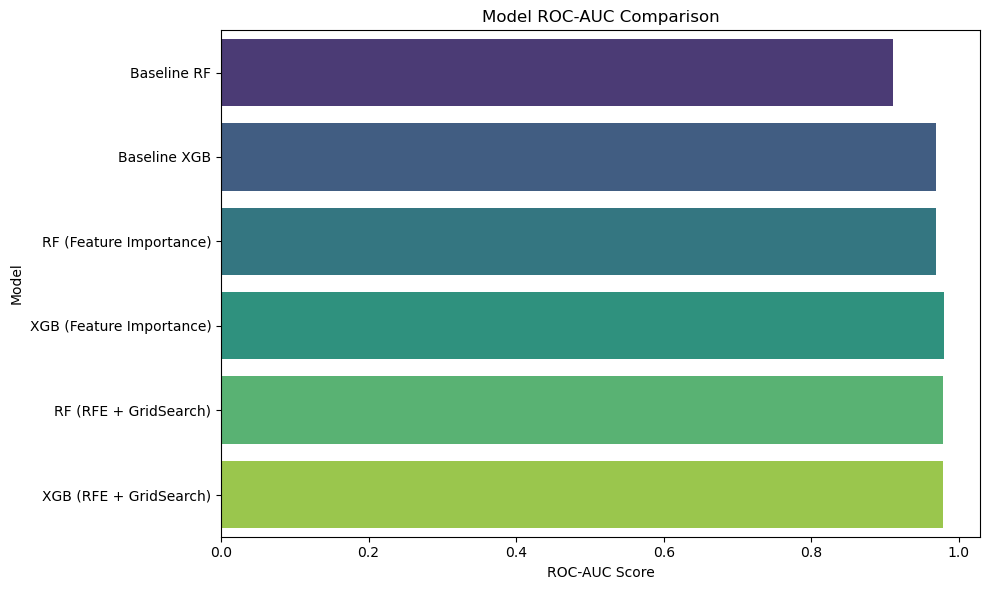

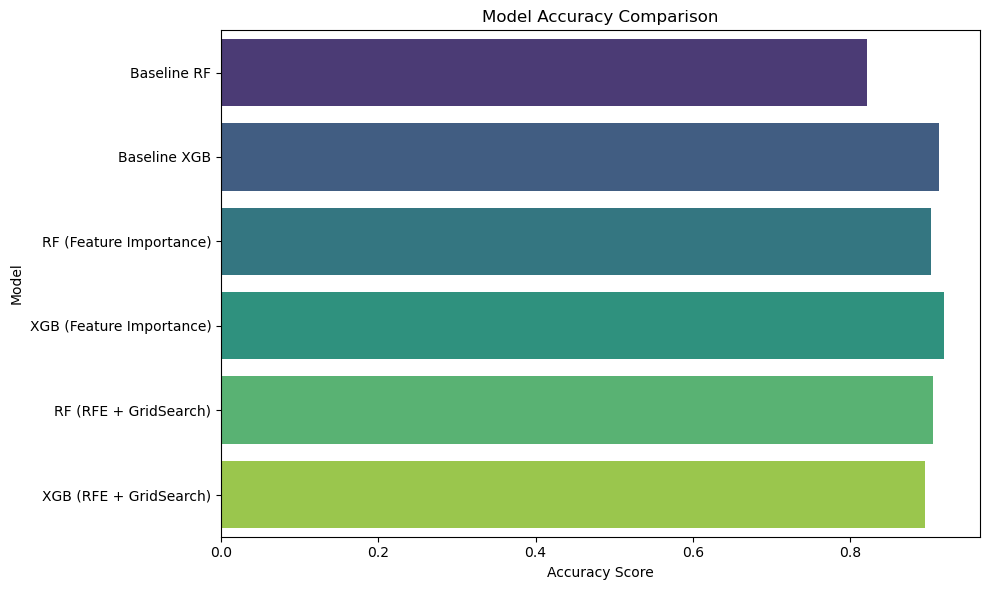

In [90]:
# Plotting ROC-AUC comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, y='Model', x='ROC-AUC', palette='viridis', hue='Model')
plt.title("Model ROC-AUC Comparison")
plt.xlabel("ROC-AUC Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, y='Model', x='Accuracy', palette='viridis', hue='Model')
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy Score")
plt.tight_layout()
plt.show()

**Key Insights**

- XGBoost consistently outperformed Random Forest in all configurations.
- The best performing model was XGB with RFE and GridSearchCV, achieving a ROC-AUC of 0.981 and accuracy of 0.916.
- Feature refinement (via RFE or importance thresholding) significantly improved model performance over baselines.
- Hyperparameter tuning further enhanced model accuracy and robustness.
- Features used by XGBoost (RFE + GridSearchCV) that predict industry's unemployment rate change: ['Unemployment_Rate(%)', 'Lagged_Unemployment_Rate', 'Lagged_Market_Tightness']
- Features used by Random Forest (RFE + GridSearchCV) that predict industry's unemployment rate change: ['Unemployment_Rate(%)', 'Market_Tightness', 'Lagged_Unemployment_Rate', 'Lagged_Market_Tightness']